# Programming assignment 5
## Course: CHE1147H - Data Mining in Engineering

# Name - Kush Lad
# Student No. - 1011339543

## 1 Supervised learning
Here, you are going to use the features you generated in Assignment #3 to predict the clients response to a promotion campaign. This is a typical classification problem in the retail industry, but the formulation of the problem is similar to industries such as fraud detection, marketing and manufacturing. <br>
The clients responses are stored in the Retail Data Response.csv file from Kaggle. The responses are binary: 0 for clients who  responded negatively to the promotional campaign and 1 for clients who responded positively to the campaign.<br>
You will explore solving the classification problem with two different sets of features (i.e. annual and monthly) and three different algorithms as shown in the image below.

### 1.1 Import the monthly and annual data and join

In Assignment #3, you created five different feature families that capture annual and monthly
aggregations. Here, you will model the retail problem with two approaches: using annual
and monthly features. Therefore, you need to create the joined tables based on the following
logic:

In both the annual and monthly features approach, you need to join at the end with table
#4, the clients responses. This is simply a table that contains the binary response of the
client to our marketing effort as described above and that is the output or label or target
that makes this a supervised learning problem.

### Libraries:

In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
scaler = StandardScaler()

### Annual features outputs

In [2]:
annual_features =  pd.read_excel("annual features.xlsx")

In [3]:
annual_day_of_week_counts_pivot = pd.read_excel("annual_transaction_counts_with_day_names_first.xlsx")

In [4]:
retail_data_responses = pd.read_csv("Retail_Data_Response.csv")

In [5]:
retail_data_responses

,customer_id,response
0,CS1112,0
1,CS1113,0
2,CS1114,1
3,CS1115,1
4,CS1116,1
...,...,...
6879,CS8996,0
6880,CS8997,0
6881,CS8998,0
6882,CS8999,0


In [6]:
annual_day_of_week_counts_pivot

,customer_id,cnt_2011_Friday,cnt_2011_Monday,cnt_2011_Saturday,cnt_2011_Sunday,cnt_2011_Thursday,cnt_2011_Tuesday,cnt_2011_Wednesday,cnt_2012_Friday,cnt_2012_Monday,...,cnt_2014_Thursday,cnt_2014_Tuesday,cnt_2014_Wednesday,cnt_2015_Friday,cnt_2015_Monday,cnt_2015_Saturday,cnt_2015_Sunday,cnt_2015_Thursday,cnt_2015_Tuesday,cnt_2015_Wednesday
0,CS1112,1,0,0,1,0,0,1,0,0,...,1,1,1,0,0,0,0,0,0,1
1,CS1113,1,1,0,1,0,0,0,2,1,...,0,3,0,0,2,0,0,0,0,1
2,CS1114,0,1,0,1,1,0,2,0,0,...,0,1,1,0,0,0,0,1,0,0
3,CS1115,0,0,1,1,0,0,1,1,1,...,2,0,2,0,0,0,0,1,0,0
4,CS1116,1,1,0,0,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6884,CS8996,0,1,0,0,0,1,0,0,0,...,1,1,2,0,0,0,0,0,0,0
6885,CS8997,0,0,0,0,1,0,1,1,2,...,0,0,0,0,0,0,0,0,0,0
6886,CS8998,0,0,0,0,0,1,1,2,0,...,0,1,1,0,0,0,0,0,0,0
6887,CS8999,0,1,1,0,0,1,0,1,0,...,0,0,2,0,0,0,0,0,0,0


In [7]:
annual_day_of_week_counts_pivot

,customer_id,cnt_2011_Friday,cnt_2011_Monday,cnt_2011_Saturday,cnt_2011_Sunday,cnt_2011_Thursday,cnt_2011_Tuesday,cnt_2011_Wednesday,cnt_2012_Friday,cnt_2012_Monday,...,cnt_2014_Thursday,cnt_2014_Tuesday,cnt_2014_Wednesday,cnt_2015_Friday,cnt_2015_Monday,cnt_2015_Saturday,cnt_2015_Sunday,cnt_2015_Thursday,cnt_2015_Tuesday,cnt_2015_Wednesday
0,CS1112,1,0,0,1,0,0,1,0,0,...,1,1,1,0,0,0,0,0,0,1
1,CS1113,1,1,0,1,0,0,0,2,1,...,0,3,0,0,2,0,0,0,0,1
2,CS1114,0,1,0,1,1,0,2,0,0,...,0,1,1,0,0,0,0,1,0,0
3,CS1115,0,0,1,1,0,0,1,1,1,...,2,0,2,0,0,0,0,1,0,0
4,CS1116,1,1,0,0,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6884,CS8996,0,1,0,0,0,1,0,0,0,...,1,1,2,0,0,0,0,0,0,0
6885,CS8997,0,0,0,0,1,0,1,1,2,...,0,0,0,0,0,0,0,0,0,0
6886,CS8998,0,0,0,0,0,1,1,2,0,...,0,1,1,0,0,0,0,0,0,0
6887,CS8999,0,1,1,0,0,1,0,1,0,...,0,0,2,0,0,0,0,0,0,0


In [8]:
annual_features

,customer_id,ann_txn_amt_ave_2011,ann_txn_amt_ave_2012,ann_txn_amt_ave_2013,ann_txn_amt_ave_2014,ann_txn_amt_ave_2015,ann_txn_amt_count_2011,ann_txn_amt_count_2012,ann_txn_amt_count_2013,ann_txn_amt_count_2014,...,ann_txn_amt_sum_2011,ann_txn_amt_sum_2012,ann_txn_amt_sum_2013,ann_txn_amt_sum_2014,ann_txn_amt_sum_2015,ann_txn_amt_var_2011,ann_txn_amt_var_2012,ann_txn_amt_var_2013,ann_txn_amt_var_2014,ann_txn_amt_var_2015
0,CS1112,70.666667,67.400000,70.666667,70.666667,39.000000,3.0,5.0,3.0,3.0,...,212.0,337.0,212.0,212.0,39.0,485.333333,161.800000,1190.333333,284.333333,NaN
1,CS1113,81.333333,74.800000,85.200000,56.500000,73.333333,3.0,5.0,5.0,4.0,...,244.0,374.0,426.0,226.0,220.0,444.333333,290.200000,171.200000,781.666667,745.333333
2,CS1114,85.200000,75.000000,70.400000,70.833333,79.000000,5.0,2.0,5.0,6.0,...,426.0,150.0,352.0,425.0,79.0,94.700000,968.000000,619.300000,726.166667,NaN
3,CS1115,87.000000,67.571429,79.571429,78.250000,55.000000,3.0,7.0,7.0,4.0,...,261.0,473.0,557.0,313.0,55.0,225.000000,477.285714,110.952381,512.250000,NaN
4,CS1116,58.750000,76.666667,59.000000,66.600000,NaN,4.0,3.0,1.0,5.0,...,235.0,230.0,59.0,333.0,NaN,449.583333,908.333333,NaN,636.800000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6884,CS8996,31.000000,33.666667,41.500000,56.000000,NaN,2.0,3.0,2.0,6.0,...,62.0,101.0,83.0,336.0,NaN,98.000000,20.333333,144.500000,481.600000,NaN
6885,CS8997,45.000000,39.500000,35.166667,42.000000,NaN,2.0,4.0,6.0,2.0,...,90.0,158.0,211.0,84.0,NaN,8.000000,45.666667,441.366667,18.000000,NaN
6886,CS8998,64.000000,54.400000,47.000000,32.500000,NaN,2.0,5.0,2.0,4.0,...,128.0,272.0,94.0,130.0,NaN,50.000000,505.300000,1568.000000,219.666667,NaN
6887,CS8999,52.000000,25.250000,28.000000,21.000000,NaN,3.0,4.0,3.0,2.0,...,156.0,101.0,84.0,42.0,NaN,333.000000,21.583333,103.000000,18.000000,NaN


In [9]:
annual_features = annual_features.fillna(0)

In [10]:
annual_features

,customer_id,ann_txn_amt_ave_2011,ann_txn_amt_ave_2012,ann_txn_amt_ave_2013,ann_txn_amt_ave_2014,ann_txn_amt_ave_2015,ann_txn_amt_count_2011,ann_txn_amt_count_2012,ann_txn_amt_count_2013,ann_txn_amt_count_2014,...,ann_txn_amt_sum_2011,ann_txn_amt_sum_2012,ann_txn_amt_sum_2013,ann_txn_amt_sum_2014,ann_txn_amt_sum_2015,ann_txn_amt_var_2011,ann_txn_amt_var_2012,ann_txn_amt_var_2013,ann_txn_amt_var_2014,ann_txn_amt_var_2015
0,CS1112,70.666667,67.400000,70.666667,70.666667,39.000000,3.0,5.0,3.0,3.0,...,212.0,337.0,212.0,212.0,39.0,485.333333,161.800000,1190.333333,284.333333,0.000000
1,CS1113,81.333333,74.800000,85.200000,56.500000,73.333333,3.0,5.0,5.0,4.0,...,244.0,374.0,426.0,226.0,220.0,444.333333,290.200000,171.200000,781.666667,745.333333
2,CS1114,85.200000,75.000000,70.400000,70.833333,79.000000,5.0,2.0,5.0,6.0,...,426.0,150.0,352.0,425.0,79.0,94.700000,968.000000,619.300000,726.166667,0.000000
3,CS1115,87.000000,67.571429,79.571429,78.250000,55.000000,3.0,7.0,7.0,4.0,...,261.0,473.0,557.0,313.0,55.0,225.000000,477.285714,110.952381,512.250000,0.000000
4,CS1116,58.750000,76.666667,59.000000,66.600000,0.000000,4.0,3.0,1.0,5.0,...,235.0,230.0,59.0,333.0,0.0,449.583333,908.333333,0.000000,636.800000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6884,CS8996,31.000000,33.666667,41.500000,56.000000,0.000000,2.0,3.0,2.0,6.0,...,62.0,101.0,83.0,336.0,0.0,98.000000,20.333333,144.500000,481.600000,0.000000
6885,CS8997,45.000000,39.500000,35.166667,42.000000,0.000000,2.0,4.0,6.0,2.0,...,90.0,158.0,211.0,84.0,0.0,8.000000,45.666667,441.366667,18.000000,0.000000
6886,CS8998,64.000000,54.400000,47.000000,32.500000,0.000000,2.0,5.0,2.0,4.0,...,128.0,272.0,94.0,130.0,0.0,50.000000,505.300000,1568.000000,219.666667,0.000000
6887,CS8999,52.000000,25.250000,28.000000,21.000000,0.000000,3.0,4.0,3.0,2.0,...,156.0,101.0,84.0,42.0,0.0,333.000000,21.583333,103.000000,18.000000,0.000000


In [11]:
annual_features_outputs_Final  = annual_features \
    .merge(annual_day_of_week_counts_pivot, how='left', on='customer_id') \
    .merge(retail_data_responses, how='left', on='customer_id')


In [12]:
annual_features_outputs_Final

,customer_id,ann_txn_amt_ave_2011,ann_txn_amt_ave_2012,ann_txn_amt_ave_2013,ann_txn_amt_ave_2014,ann_txn_amt_ave_2015,ann_txn_amt_count_2011,ann_txn_amt_count_2012,ann_txn_amt_count_2013,ann_txn_amt_count_2014,...,cnt_2014_Tuesday,cnt_2014_Wednesday,cnt_2015_Friday,cnt_2015_Monday,cnt_2015_Saturday,cnt_2015_Sunday,cnt_2015_Thursday,cnt_2015_Tuesday,cnt_2015_Wednesday,response
0,CS1112,70.666667,67.400000,70.666667,70.666667,39.000000,3.0,5.0,3.0,3.0,...,1,1,0,0,0,0,0,0,1,0.0
1,CS1113,81.333333,74.800000,85.200000,56.500000,73.333333,3.0,5.0,5.0,4.0,...,3,0,0,2,0,0,0,0,1,0.0
2,CS1114,85.200000,75.000000,70.400000,70.833333,79.000000,5.0,2.0,5.0,6.0,...,1,1,0,0,0,0,1,0,0,1.0
3,CS1115,87.000000,67.571429,79.571429,78.250000,55.000000,3.0,7.0,7.0,4.0,...,0,2,0,0,0,0,1,0,0,1.0
4,CS1116,58.750000,76.666667,59.000000,66.600000,0.000000,4.0,3.0,1.0,5.0,...,0,0,0,0,0,0,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6884,CS8996,31.000000,33.666667,41.500000,56.000000,0.000000,2.0,3.0,2.0,6.0,...,1,2,0,0,0,0,0,0,0,0.0
6885,CS8997,45.000000,39.500000,35.166667,42.000000,0.000000,2.0,4.0,6.0,2.0,...,0,0,0,0,0,0,0,0,0,0.0
6886,CS8998,64.000000,54.400000,47.000000,32.500000,0.000000,2.0,5.0,2.0,4.0,...,1,1,0,0,0,0,0,0,0,0.0
6887,CS8999,52.000000,25.250000,28.000000,21.000000,0.000000,3.0,4.0,3.0,2.0,...,0,2,0,0,0,0,0,0,0,0.0


In [13]:
annual_features_outputs = annual_features_outputs_Final.copy()

In [14]:
annual_features_outputs = annual_features_outputs.drop(columns = "customer_id")

In [15]:
annual_features_outputs

,ann_txn_amt_ave_2011,ann_txn_amt_ave_2012,ann_txn_amt_ave_2013,ann_txn_amt_ave_2014,ann_txn_amt_ave_2015,ann_txn_amt_count_2011,ann_txn_amt_count_2012,ann_txn_amt_count_2013,ann_txn_amt_count_2014,ann_txn_amt_count_2015,...,cnt_2014_Tuesday,cnt_2014_Wednesday,cnt_2015_Friday,cnt_2015_Monday,cnt_2015_Saturday,cnt_2015_Sunday,cnt_2015_Thursday,cnt_2015_Tuesday,cnt_2015_Wednesday,response
0,70.666667,67.400000,70.666667,70.666667,39.000000,3.0,5.0,3.0,3.0,1.0,...,1,1,0,0,0,0,0,0,1,0.0
1,81.333333,74.800000,85.200000,56.500000,73.333333,3.0,5.0,5.0,4.0,3.0,...,3,0,0,2,0,0,0,0,1,0.0
2,85.200000,75.000000,70.400000,70.833333,79.000000,5.0,2.0,5.0,6.0,1.0,...,1,1,0,0,0,0,1,0,0,1.0
3,87.000000,67.571429,79.571429,78.250000,55.000000,3.0,7.0,7.0,4.0,1.0,...,0,2,0,0,0,0,1,0,0,1.0
4,58.750000,76.666667,59.000000,66.600000,0.000000,4.0,3.0,1.0,5.0,0.0,...,0,0,0,0,0,0,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6884,31.000000,33.666667,41.500000,56.000000,0.000000,2.0,3.0,2.0,6.0,0.0,...,1,2,0,0,0,0,0,0,0,0.0
6885,45.000000,39.500000,35.166667,42.000000,0.000000,2.0,4.0,6.0,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0.0
6886,64.000000,54.400000,47.000000,32.500000,0.000000,2.0,5.0,2.0,4.0,0.0,...,1,1,0,0,0,0,0,0,0,0.0
6887,52.000000,25.250000,28.000000,21.000000,0.000000,3.0,4.0,3.0,2.0,0.0,...,0,2,0,0,0,0,0,0,0,0.0


### Monthly features outputs

In [16]:
mth_rolling_features = pd.read_excel("mth_rolling_features.xlsx")

In [17]:
mth_day_counts = pd.read_excel("mth_day_counts.xlsx")

In [18]:
days_since_last_txn = pd.read_excel("days_since_last_txn.xlsx")

In [19]:
A = mth_rolling_features.copy()

In [20]:
B = mth_day_counts.copy()

In [21]:
C =  days_since_last_txn.copy()

In [22]:
D = retail_data_responses.copy()

In [23]:
mth_rolling_features.isna().sum()

Unnamed: 0                 0
CLNT_NO                    0
ME_DT                      0
monthly_txn_sum_amt        0
monthly_txn_count          0
amt sum 3M             13778
amt mean 3M            13778
amt max 3M             13778
txn cnt sum 3M         13778
txn cnt mean 3M        13778
txn cnt max 3M         13778
amt sum 6M             34445
amt mean 6M            34445
amt max 6M             34445
txn cnt sum 6M         34445
txn cnt mean 6M        34445
txn cnt max 6M         34445
amt sum 12M            75779
amt mean 12M           75779
amt max 12M            75779
txn cnt sum 12M        75779
txn cnt mean 12M       75779
txn cnt max 12M        75779
dtype: int64

In [24]:
D

,customer_id,response
0,CS1112,0
1,CS1113,0
2,CS1114,1
3,CS1115,1
4,CS1116,1
...,...,...
6879,CS8996,0
6880,CS8997,0
6881,CS8998,0
6882,CS8999,0


In [25]:
A 


,Unnamed: 0,CLNT_NO,ME_DT,monthly_txn_sum_amt,monthly_txn_count,amt sum 3M,amt mean 3M,amt max 3M,txn cnt sum 3M,txn cnt mean 3M,...,amt max 6M,txn cnt sum 6M,txn cnt mean 6M,txn cnt max 6M,amt sum 12M,amt mean 12M,amt max 12M,txn cnt sum 12M,txn cnt mean 12M,txn cnt max 12M
0,0,CS5295,2013-02-28,35,1,202.0,67.333333,131.0,4.0,1.333333,...,131.0,4.0,0.666667,2.0,466.0,38.833333,131.0,8.0,0.666667,2.0
1,1,CS5295,2015-03-31,0,0,0.0,0.000000,0.0,0.0,0.000000,...,59.0,2.0,0.333333,1.0,460.0,38.333333,347.0,6.0,0.500000,4.0
2,2,CS5295,2011-11-30,132,2,236.0,78.666667,132.0,3.0,1.000000,...,132.0,3.0,0.500000,2.0,NaN,NaN,NaN,NaN,NaN,NaN
3,3,CS5295,2013-11-30,0,0,53.0,17.666667,53.0,1.0,0.333333,...,53.0,1.0,0.166667,1.0,438.0,36.500000,131.0,8.0,0.666667,2.0
4,4,CS5295,2014-03-31,0,0,37.0,12.333333,37.0,1.0,0.333333,...,53.0,2.0,0.333333,1.0,175.0,14.583333,53.0,4.0,0.333333,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323778,323778,CS8077,2011-08-31,30,1,30.0,10.000000,30.0,1.0,0.333333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
323779,323779,CS8077,2012-09-30,0,0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
323780,323780,CS8077,2014-09-30,0,0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
323781,323781,CS8077,2014-02-28,0,0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0


In [26]:
A = A.drop(columns="Unnamed: 0")

In [27]:
A

,CLNT_NO,ME_DT,monthly_txn_sum_amt,monthly_txn_count,amt sum 3M,amt mean 3M,amt max 3M,txn cnt sum 3M,txn cnt mean 3M,txn cnt max 3M,...,amt max 6M,txn cnt sum 6M,txn cnt mean 6M,txn cnt max 6M,amt sum 12M,amt mean 12M,amt max 12M,txn cnt sum 12M,txn cnt mean 12M,txn cnt max 12M
0,CS5295,2013-02-28,35,1,202.0,67.333333,131.0,4.0,1.333333,2.0,...,131.0,4.0,0.666667,2.0,466.0,38.833333,131.0,8.0,0.666667,2.0
1,CS5295,2015-03-31,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,59.0,2.0,0.333333,1.0,460.0,38.333333,347.0,6.0,0.500000,4.0
2,CS5295,2011-11-30,132,2,236.0,78.666667,132.0,3.0,1.000000,2.0,...,132.0,3.0,0.500000,2.0,NaN,NaN,NaN,NaN,NaN,NaN
3,CS5295,2013-11-30,0,0,53.0,17.666667,53.0,1.0,0.333333,1.0,...,53.0,1.0,0.166667,1.0,438.0,36.500000,131.0,8.0,0.666667,2.0
4,CS5295,2014-03-31,0,0,37.0,12.333333,37.0,1.0,0.333333,1.0,...,53.0,2.0,0.333333,1.0,175.0,14.583333,53.0,4.0,0.333333,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323778,CS8077,2011-08-31,30,1,30.0,10.000000,30.0,1.0,0.333333,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
323779,CS8077,2012-09-30,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
323780,CS8077,2014-09-30,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
323781,CS8077,2014-02-28,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0


In [28]:
B

,Unnamed: 0,CLNT_NO,ME_DT,cnt_Friday,cnt_Monday,cnt_Saturday,cnt_Sunday,cnt_Thursday,cnt_Tuesday,cnt_Wednesday
0,0,CS5295,2013-02-28,0,1,0,0,0,0,0
1,1,CS5295,2015-03-31,0,0,0,0,0,0,0
2,2,CS5295,2011-11-30,0,1,0,0,0,0,1
3,3,CS5295,2013-11-30,0,0,0,0,0,0,0
4,4,CS5295,2014-03-31,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
323778,323778,CS8077,2011-08-31,0,0,0,1,0,0,0
323779,323779,CS8077,2012-09-30,0,0,0,0,0,0,0
323780,323780,CS8077,2014-09-30,0,0,0,0,0,0,0
323781,323781,CS8077,2014-02-28,0,0,0,0,0,0,0


In [29]:
B = B.drop(columns="Unnamed: 0")

In [30]:
B

,CLNT_NO,ME_DT,cnt_Friday,cnt_Monday,cnt_Saturday,cnt_Sunday,cnt_Thursday,cnt_Tuesday,cnt_Wednesday
0,CS5295,2013-02-28,0,1,0,0,0,0,0
1,CS5295,2015-03-31,0,0,0,0,0,0,0
2,CS5295,2011-11-30,0,1,0,0,0,0,1
3,CS5295,2013-11-30,0,0,0,0,0,0,0
4,CS5295,2014-03-31,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
323778,CS8077,2011-08-31,0,0,0,1,0,0,0
323779,CS8077,2012-09-30,0,0,0,0,0,0,0
323780,CS8077,2014-09-30,0,0,0,0,0,0,0
323781,CS8077,2014-02-28,0,0,0,0,0,0,0


In [31]:
C

,Unnamed: 0,CLNT_NO,ME_DT,days since last txn
0,223428,CS5307,2011-05-31,0
1,124070,CS2337,2011-05-31,0
2,47930,CS4022,2011-05-31,10
3,8826,CS5225,2011-05-31,0
4,61184,CS5802,2011-05-31,14
...,...,...,...,...
323778,80230,CS2118,2015-03-31,240
323779,114963,CS1714,2015-03-31,15
323780,314807,CS8268,2015-03-31,83
323781,131554,CS1777,2015-03-31,94


In [32]:
C.rename(columns={'Unnamed: 0': 'index_'}, inplace=True)

In [33]:
C

,index_,CLNT_NO,ME_DT,days since last txn
0,223428,CS5307,2011-05-31,0
1,124070,CS2337,2011-05-31,0
2,47930,CS4022,2011-05-31,10
3,8826,CS5225,2011-05-31,0
4,61184,CS5802,2011-05-31,14
...,...,...,...,...
323778,80230,CS2118,2015-03-31,240
323779,114963,CS1714,2015-03-31,15
323780,314807,CS8268,2015-03-31,83
323781,131554,CS1777,2015-03-31,94


In [34]:
C.sort_values(by='index_', ascending=True, inplace=True)

In [35]:
C

,index_,CLNT_NO,ME_DT,days since last txn
148400,0,CS5295,2013-02-28,17
319093,1,CS5295,2015-03-31,126
46519,2,CS5295,2011-11-30,14
207178,3,CS5295,2013-11-30,42
240739,4,CS5295,2014-03-31,70
...,...,...,...,...
24818,323778,CS8077,2011-08-31,3
113731,323779,CS8077,2012-09-30,378
278188,323780,CS8077,2014-09-30,625
229127,323781,CS8077,2014-02-28,411


In [36]:
C.reset_index(drop=True, inplace=True)

In [37]:
C =  C.drop(columns="index_")

In [38]:
C

,CLNT_NO,ME_DT,days since last txn
0,CS5295,2013-02-28,17
1,CS5295,2015-03-31,126
2,CS5295,2011-11-30,14
3,CS5295,2013-11-30,42
4,CS5295,2014-03-31,70
...,...,...,...
323778,CS8077,2011-08-31,3
323779,CS8077,2012-09-30,378
323780,CS8077,2014-09-30,625
323781,CS8077,2014-02-28,411


In [39]:
D

,customer_id,response
0,CS1112,0
1,CS1113,0
2,CS1114,1
3,CS1115,1
4,CS1116,1
...,...,...
6879,CS8996,0
6880,CS8997,0
6881,CS8998,0
6882,CS8999,0


In [40]:
A

,CLNT_NO,ME_DT,monthly_txn_sum_amt,monthly_txn_count,amt sum 3M,amt mean 3M,amt max 3M,txn cnt sum 3M,txn cnt mean 3M,txn cnt max 3M,...,amt max 6M,txn cnt sum 6M,txn cnt mean 6M,txn cnt max 6M,amt sum 12M,amt mean 12M,amt max 12M,txn cnt sum 12M,txn cnt mean 12M,txn cnt max 12M
0,CS5295,2013-02-28,35,1,202.0,67.333333,131.0,4.0,1.333333,2.0,...,131.0,4.0,0.666667,2.0,466.0,38.833333,131.0,8.0,0.666667,2.0
1,CS5295,2015-03-31,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,59.0,2.0,0.333333,1.0,460.0,38.333333,347.0,6.0,0.500000,4.0
2,CS5295,2011-11-30,132,2,236.0,78.666667,132.0,3.0,1.000000,2.0,...,132.0,3.0,0.500000,2.0,NaN,NaN,NaN,NaN,NaN,NaN
3,CS5295,2013-11-30,0,0,53.0,17.666667,53.0,1.0,0.333333,1.0,...,53.0,1.0,0.166667,1.0,438.0,36.500000,131.0,8.0,0.666667,2.0
4,CS5295,2014-03-31,0,0,37.0,12.333333,37.0,1.0,0.333333,1.0,...,53.0,2.0,0.333333,1.0,175.0,14.583333,53.0,4.0,0.333333,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323778,CS8077,2011-08-31,30,1,30.0,10.000000,30.0,1.0,0.333333,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
323779,CS8077,2012-09-30,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
323780,CS8077,2014-09-30,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0
323781,CS8077,2014-02-28,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0


In [41]:
B

,CLNT_NO,ME_DT,cnt_Friday,cnt_Monday,cnt_Saturday,cnt_Sunday,cnt_Thursday,cnt_Tuesday,cnt_Wednesday
0,CS5295,2013-02-28,0,1,0,0,0,0,0
1,CS5295,2015-03-31,0,0,0,0,0,0,0
2,CS5295,2011-11-30,0,1,0,0,0,0,1
3,CS5295,2013-11-30,0,0,0,0,0,0,0
4,CS5295,2014-03-31,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
323778,CS8077,2011-08-31,0,0,0,1,0,0,0
323779,CS8077,2012-09-30,0,0,0,0,0,0,0
323780,CS8077,2014-09-30,0,0,0,0,0,0,0
323781,CS8077,2014-02-28,0,0,0,0,0,0,0


In [42]:
C

,CLNT_NO,ME_DT,days since last txn
0,CS5295,2013-02-28,17
1,CS5295,2015-03-31,126
2,CS5295,2011-11-30,14
3,CS5295,2013-11-30,42
4,CS5295,2014-03-31,70
...,...,...,...
323778,CS8077,2011-08-31,3
323779,CS8077,2012-09-30,378
323780,CS8077,2014-09-30,625
323781,CS8077,2014-02-28,411


In [43]:
A_1 = A.head(15)

In [44]:
A_1

,CLNT_NO,ME_DT,monthly_txn_sum_amt,monthly_txn_count,amt sum 3M,amt mean 3M,amt max 3M,txn cnt sum 3M,txn cnt mean 3M,txn cnt max 3M,...,amt max 6M,txn cnt sum 6M,txn cnt mean 6M,txn cnt max 6M,amt sum 12M,amt mean 12M,amt max 12M,txn cnt sum 12M,txn cnt mean 12M,txn cnt max 12M
0,CS5295,2013-02-28,35,1,202.0,67.333333,131.0,4.0,1.333333,2.0,...,131.0,4.0,0.666667,2.0,466.0,38.833333,131.0,8.0,0.666667,2.0
1,CS5295,2015-03-31,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,59.0,2.0,0.333333,1.0,460.0,38.333333,347.0,6.0,0.500000,4.0
2,CS5295,2011-11-30,132,2,236.0,78.666667,132.0,3.0,1.000000,2.0,...,132.0,3.0,0.500000,2.0,NaN,NaN,NaN,NaN,NaN,NaN
3,CS5295,2013-11-30,0,0,53.0,17.666667,53.0,1.0,0.333333,1.0,...,53.0,1.0,0.166667,1.0,438.0,36.500000,131.0,8.0,0.666667,2.0
4,CS5295,2014-03-31,0,0,37.0,12.333333,37.0,1.0,0.333333,1.0,...,53.0,2.0,0.333333,1.0,175.0,14.583333,53.0,4.0,0.333333,1.0
5,CS5295,2012-02-29,65,1,202.0,67.333333,137.0,3.0,1.000000,2.0,...,137.0,6.0,1.000000,2.0,NaN,NaN,NaN,NaN,NaN,NaN
6,CS5295,2015-01-31,0,0,54.0,18.000000,54.0,1.0,0.333333,1.0,...,347.0,6.0,1.000000,4.0,460.0,38.333333,347.0,6.0,0.500000,4.0
7,CS5295,2013-01-31,131,2,167.0,55.666667,131.0,3.0,1.000000,2.0,...,131.0,4.0,0.666667,2.0,496.0,41.333333,131.0,8.0,0.666667,2.0
8,CS5295,2013-08-31,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,98.0,3.0,0.500000,1.0,385.0,32.083333,131.0,7.0,0.583333,2.0
9,CS5295,2013-07-31,0,0,37.0,12.333333,37.0,1.0,0.333333,1.0,...,98.0,4.0,0.666667,1.0,422.0,35.166667,131.0,8.0,0.666667,2.0


In [45]:
B_1 = B.head(15)

In [46]:
B_1

,CLNT_NO,ME_DT,cnt_Friday,cnt_Monday,cnt_Saturday,cnt_Sunday,cnt_Thursday,cnt_Tuesday,cnt_Wednesday
0,CS5295,2013-02-28,0,1,0,0,0,0,0
1,CS5295,2015-03-31,0,0,0,0,0,0,0
2,CS5295,2011-11-30,0,1,0,0,0,0,1
3,CS5295,2013-11-30,0,0,0,0,0,0,0
4,CS5295,2014-03-31,0,0,0,0,0,0,0
5,CS5295,2012-02-29,0,0,0,1,0,0,0
6,CS5295,2015-01-31,0,0,0,0,0,0,0
7,CS5295,2013-01-31,0,0,1,1,0,0,0
8,CS5295,2013-08-31,0,0,0,0,0,0,0
9,CS5295,2013-07-31,0,0,0,0,0,0,0


In [47]:
AB_ = pd.merge(A_1, B_1, on=['CLNT_NO', 'ME_DT'], how='inner')

In [48]:
AB = pd.merge(A, B, on=['CLNT_NO', 'ME_DT'], how='inner')

In [49]:
AB

,CLNT_NO,ME_DT,monthly_txn_sum_amt,monthly_txn_count,amt sum 3M,amt mean 3M,amt max 3M,txn cnt sum 3M,txn cnt mean 3M,txn cnt max 3M,...,txn cnt sum 12M,txn cnt mean 12M,txn cnt max 12M,cnt_Friday,cnt_Monday,cnt_Saturday,cnt_Sunday,cnt_Thursday,cnt_Tuesday,cnt_Wednesday
0,CS5295,2013-02-28,35,1,202.0,67.333333,131.0,4.0,1.333333,2.0,...,8.0,0.666667,2.0,0,1,0,0,0,0,0
1,CS5295,2015-03-31,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,6.0,0.500000,4.0,0,0,0,0,0,0,0
2,CS5295,2011-11-30,132,2,236.0,78.666667,132.0,3.0,1.000000,2.0,...,NaN,NaN,NaN,0,1,0,0,0,0,1
3,CS5295,2013-11-30,0,0,53.0,17.666667,53.0,1.0,0.333333,1.0,...,8.0,0.666667,2.0,0,0,0,0,0,0,0
4,CS5295,2014-03-31,0,0,37.0,12.333333,37.0,1.0,0.333333,1.0,...,4.0,0.333333,1.0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323778,CS8077,2011-08-31,30,1,30.0,10.000000,30.0,1.0,0.333333,1.0,...,NaN,NaN,NaN,0,0,0,1,0,0,0
323779,CS8077,2012-09-30,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0,0,0,0,0,0,0
323780,CS8077,2014-09-30,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0,0,0,0,0,0,0
323781,CS8077,2014-02-28,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0,0,0,0,0,0,0


In [50]:
C

,CLNT_NO,ME_DT,days since last txn
0,CS5295,2013-02-28,17
1,CS5295,2015-03-31,126
2,CS5295,2011-11-30,14
3,CS5295,2013-11-30,42
4,CS5295,2014-03-31,70
...,...,...,...
323778,CS8077,2011-08-31,3
323779,CS8077,2012-09-30,378
323780,CS8077,2014-09-30,625
323781,CS8077,2014-02-28,411


In [51]:
ABC = pd.merge(AB, C, on=['CLNT_NO', 'ME_DT'], how='inner')

In [52]:
ABC

,CLNT_NO,ME_DT,monthly_txn_sum_amt,monthly_txn_count,amt sum 3M,amt mean 3M,amt max 3M,txn cnt sum 3M,txn cnt mean 3M,txn cnt max 3M,...,txn cnt mean 12M,txn cnt max 12M,cnt_Friday,cnt_Monday,cnt_Saturday,cnt_Sunday,cnt_Thursday,cnt_Tuesday,cnt_Wednesday,days since last txn
0,CS5295,2013-02-28,35,1,202.0,67.333333,131.0,4.0,1.333333,2.0,...,0.666667,2.0,0,1,0,0,0,0,0,17
1,CS5295,2015-03-31,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.500000,4.0,0,0,0,0,0,0,0,126
2,CS5295,2011-11-30,132,2,236.0,78.666667,132.0,3.0,1.000000,2.0,...,NaN,NaN,0,1,0,0,0,0,1,14
3,CS5295,2013-11-30,0,0,53.0,17.666667,53.0,1.0,0.333333,1.0,...,0.666667,2.0,0,0,0,0,0,0,0,42
4,CS5295,2014-03-31,0,0,37.0,12.333333,37.0,1.0,0.333333,1.0,...,0.333333,1.0,0,0,0,0,0,0,0,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323778,CS8077,2011-08-31,30,1,30.0,10.000000,30.0,1.0,0.333333,1.0,...,NaN,NaN,0,0,0,1,0,0,0,3
323779,CS8077,2012-09-30,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0,0,0,0,0,0,0,378
323780,CS8077,2014-09-30,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0,0,0,0,0,0,0,625
323781,CS8077,2014-02-28,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0,0,0,0,0,0,0,411


In [53]:
D 

,customer_id,response
0,CS1112,0
1,CS1113,0
2,CS1114,1
3,CS1115,1
4,CS1116,1
...,...,...
6879,CS8996,0
6880,CS8997,0
6881,CS8998,0
6882,CS8999,0


In [54]:
D.rename(columns={'customer_id': 'CLNT_NO'}, inplace=True)

In [55]:
D

,CLNT_NO,response
0,CS1112,0
1,CS1113,0
2,CS1114,1
3,CS1115,1
4,CS1116,1
...,...,...
6879,CS8996,0
6880,CS8997,0
6881,CS8998,0
6882,CS8999,0


In [56]:
ABCD = pd.merge(ABC, D, on=['CLNT_NO'], how='inner')

In [57]:
ABCD


,CLNT_NO,ME_DT,monthly_txn_sum_amt,monthly_txn_count,amt sum 3M,amt mean 3M,amt max 3M,txn cnt sum 3M,txn cnt mean 3M,txn cnt max 3M,...,txn cnt max 12M,cnt_Friday,cnt_Monday,cnt_Saturday,cnt_Sunday,cnt_Thursday,cnt_Tuesday,cnt_Wednesday,days since last txn,response
0,CS5295,2013-02-28,35,1,202.0,67.333333,131.0,4.0,1.333333,2.0,...,2.0,0,1,0,0,0,0,0,17,1
1,CS5295,2015-03-31,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,4.0,0,0,0,0,0,0,0,126,1
2,CS5295,2011-11-30,132,2,236.0,78.666667,132.0,3.0,1.000000,2.0,...,NaN,0,1,0,0,0,0,1,14,1
3,CS5295,2013-11-30,0,0,53.0,17.666667,53.0,1.0,0.333333,1.0,...,2.0,0,0,0,0,0,0,0,42,1
4,CS5295,2014-03-31,0,0,37.0,12.333333,37.0,1.0,0.333333,1.0,...,1.0,0,0,0,0,0,0,0,70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323543,CS8077,2011-08-31,30,1,30.0,10.000000,30.0,1.0,0.333333,1.0,...,NaN,0,0,0,1,0,0,0,3,0
323544,CS8077,2012-09-30,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0,0,0,0,0,0,0,378,0
323545,CS8077,2014-09-30,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0,0,0,0,0,0,0,625,0
323546,CS8077,2014-02-28,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0,0,0,0,0,0,0,411,0


In [58]:
A.isna().sum()

CLNT_NO                    0
ME_DT                      0
monthly_txn_sum_amt        0
monthly_txn_count          0
amt sum 3M             13778
amt mean 3M            13778
amt max 3M             13778
txn cnt sum 3M         13778
txn cnt mean 3M        13778
txn cnt max 3M         13778
amt sum 6M             34445
amt mean 6M            34445
amt max 6M             34445
txn cnt sum 6M         34445
txn cnt mean 6M        34445
txn cnt max 6M         34445
amt sum 12M            75779
amt mean 12M           75779
amt max 12M            75779
txn cnt sum 12M        75779
txn cnt mean 12M       75779
txn cnt max 12M        75779
dtype: int64

In [59]:
ABCD.isna().sum()

CLNT_NO                    0
ME_DT                      0
monthly_txn_sum_amt        0
monthly_txn_count          0
amt sum 3M             13768
amt mean 3M            13768
amt max 3M             13768
txn cnt sum 3M         13768
txn cnt mean 3M        13768
txn cnt max 3M         13768
amt sum 6M             34420
amt mean 6M            34420
amt max 6M             34420
txn cnt sum 6M         34420
txn cnt mean 6M        34420
txn cnt max 6M         34420
amt sum 12M            75724
amt mean 12M           75724
amt max 12M            75724
txn cnt sum 12M        75724
txn cnt mean 12M       75724
txn cnt max 12M        75724
cnt_Friday                 0
cnt_Monday                 0
cnt_Saturday               0
cnt_Sunday                 0
cnt_Thursday               0
cnt_Tuesday                0
cnt_Wednesday              0
days since last txn        0
response                   0
dtype: int64

In [60]:
ABCD = ABCD.fillna(0)

In [61]:
ABCD.isna().sum()

CLNT_NO                0
ME_DT                  0
monthly_txn_sum_amt    0
monthly_txn_count      0
amt sum 3M             0
amt mean 3M            0
amt max 3M             0
txn cnt sum 3M         0
txn cnt mean 3M        0
txn cnt max 3M         0
amt sum 6M             0
amt mean 6M            0
amt max 6M             0
txn cnt sum 6M         0
txn cnt mean 6M        0
txn cnt max 6M         0
amt sum 12M            0
amt mean 12M           0
amt max 12M            0
txn cnt sum 12M        0
txn cnt mean 12M       0
txn cnt max 12M        0
cnt_Friday             0
cnt_Monday             0
cnt_Saturday           0
cnt_Sunday             0
cnt_Thursday           0
cnt_Tuesday            0
cnt_Wednesday          0
days since last txn    0
response               0
dtype: int64

In [62]:
monthly_features_outputs = ABCD.copy()

In [63]:
monthly_features_outputs

,CLNT_NO,ME_DT,monthly_txn_sum_amt,monthly_txn_count,amt sum 3M,amt mean 3M,amt max 3M,txn cnt sum 3M,txn cnt mean 3M,txn cnt max 3M,...,txn cnt max 12M,cnt_Friday,cnt_Monday,cnt_Saturday,cnt_Sunday,cnt_Thursday,cnt_Tuesday,cnt_Wednesday,days since last txn,response
0,CS5295,2013-02-28,35,1,202.0,67.333333,131.0,4.0,1.333333,2.0,...,2.0,0,1,0,0,0,0,0,17,1
1,CS5295,2015-03-31,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,4.0,0,0,0,0,0,0,0,126,1
2,CS5295,2011-11-30,132,2,236.0,78.666667,132.0,3.0,1.000000,2.0,...,0.0,0,1,0,0,0,0,1,14,1
3,CS5295,2013-11-30,0,0,53.0,17.666667,53.0,1.0,0.333333,1.0,...,2.0,0,0,0,0,0,0,0,42,1
4,CS5295,2014-03-31,0,0,37.0,12.333333,37.0,1.0,0.333333,1.0,...,1.0,0,0,0,0,0,0,0,70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323543,CS8077,2011-08-31,30,1,30.0,10.000000,30.0,1.0,0.333333,1.0,...,0.0,0,0,0,1,0,0,0,3,0
323544,CS8077,2012-09-30,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0,0,0,0,0,0,0,378,0
323545,CS8077,2014-09-30,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0,0,0,0,0,0,0,625,0
323546,CS8077,2014-02-28,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0,0,0,0,0,0,0,411,0


In [64]:
monthly_features_outputs = monthly_features_outputs.drop(columns = "ME_DT")

In [65]:
monthly_features_outputs = monthly_features_outputs.drop(columns = "CLNT_NO")

In [66]:
monthly_features_outputs

,monthly_txn_sum_amt,monthly_txn_count,amt sum 3M,amt mean 3M,amt max 3M,txn cnt sum 3M,txn cnt mean 3M,txn cnt max 3M,amt sum 6M,amt mean 6M,...,txn cnt max 12M,cnt_Friday,cnt_Monday,cnt_Saturday,cnt_Sunday,cnt_Thursday,cnt_Tuesday,cnt_Wednesday,days since last txn,response
0,35,1,202.0,67.333333,131.0,4.0,1.333333,2.0,202.0,33.666667,...,2.0,0,1,0,0,0,0,0,17,1
1,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,113.0,18.833333,...,4.0,0,0,0,0,0,0,0,126,1
2,132,2,236.0,78.666667,132.0,3.0,1.000000,2.0,236.0,39.333333,...,0.0,0,1,0,0,0,0,1,14,1
3,0,0,53.0,17.666667,53.0,1.0,0.333333,1.0,53.0,8.833333,...,2.0,0,0,0,0,0,0,0,42,1
4,0,0,37.0,12.333333,37.0,1.0,0.333333,1.0,90.0,15.000000,...,1.0,0,0,0,0,0,0,0,70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323543,30,1,30.0,10.000000,30.0,1.0,0.333333,1.0,0.0,0.000000,...,0.0,0,0,0,1,0,0,0,3,0
323544,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0,0,0,0,0,0,0,378,0
323545,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0,0,0,0,0,0,0,625,0
323546,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0,0,0,0,0,0,0,411,0


In [67]:
monthly_features_outputs.shape

(323548, 29)

### 1.2 Steps for each method (10 points)
#### 1. Separate the inputs X and the output y in two data frames.

In [68]:
monthly_features_outputs.isna().sum()

monthly_txn_sum_amt    0
monthly_txn_count      0
amt sum 3M             0
amt mean 3M            0
amt max 3M             0
txn cnt sum 3M         0
txn cnt mean 3M        0
txn cnt max 3M         0
amt sum 6M             0
amt mean 6M            0
amt max 6M             0
txn cnt sum 6M         0
txn cnt mean 6M        0
txn cnt max 6M         0
amt sum 12M            0
amt mean 12M           0
amt max 12M            0
txn cnt sum 12M        0
txn cnt mean 12M       0
txn cnt max 12M        0
cnt_Friday             0
cnt_Monday             0
cnt_Saturday           0
cnt_Sunday             0
cnt_Thursday           0
cnt_Tuesday            0
cnt_Wednesday          0
days since last txn    0
response               0
dtype: int64

In [69]:
annual_features_outputs.isna().sum()

ann_txn_amt_ave_2011    0
ann_txn_amt_ave_2012    0
ann_txn_amt_ave_2013    0
ann_txn_amt_ave_2014    0
ann_txn_amt_ave_2015    0
                       ..
cnt_2015_Sunday         0
cnt_2015_Thursday       0
cnt_2015_Tuesday        0
cnt_2015_Wednesday      0
response                5
Length: 76, dtype: int64

In [70]:
annual_features_outputs = annual_features_outputs.dropna()

In [71]:
annual_features_outputs.isna().sum()

ann_txn_amt_ave_2011    0
ann_txn_amt_ave_2012    0
ann_txn_amt_ave_2013    0
ann_txn_amt_ave_2014    0
ann_txn_amt_ave_2015    0
                       ..
cnt_2015_Sunday         0
cnt_2015_Thursday       0
cnt_2015_Tuesday        0
cnt_2015_Wednesday      0
response                0
Length: 76, dtype: int64

In [72]:
annual_features_outputs

,ann_txn_amt_ave_2011,ann_txn_amt_ave_2012,ann_txn_amt_ave_2013,ann_txn_amt_ave_2014,ann_txn_amt_ave_2015,ann_txn_amt_count_2011,ann_txn_amt_count_2012,ann_txn_amt_count_2013,ann_txn_amt_count_2014,ann_txn_amt_count_2015,...,cnt_2014_Tuesday,cnt_2014_Wednesday,cnt_2015_Friday,cnt_2015_Monday,cnt_2015_Saturday,cnt_2015_Sunday,cnt_2015_Thursday,cnt_2015_Tuesday,cnt_2015_Wednesday,response
0,70.666667,67.400000,70.666667,70.666667,39.000000,3.0,5.0,3.0,3.0,1.0,...,1,1,0,0,0,0,0,0,1,0.0
1,81.333333,74.800000,85.200000,56.500000,73.333333,3.0,5.0,5.0,4.0,3.0,...,3,0,0,2,0,0,0,0,1,0.0
2,85.200000,75.000000,70.400000,70.833333,79.000000,5.0,2.0,5.0,6.0,1.0,...,1,1,0,0,0,0,1,0,0,1.0
3,87.000000,67.571429,79.571429,78.250000,55.000000,3.0,7.0,7.0,4.0,1.0,...,0,2,0,0,0,0,1,0,0,1.0
4,58.750000,76.666667,59.000000,66.600000,0.000000,4.0,3.0,1.0,5.0,0.0,...,0,0,0,0,0,0,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6884,31.000000,33.666667,41.500000,56.000000,0.000000,2.0,3.0,2.0,6.0,0.0,...,1,2,0,0,0,0,0,0,0,0.0
6885,45.000000,39.500000,35.166667,42.000000,0.000000,2.0,4.0,6.0,2.0,0.0,...,0,0,0,0,0,0,0,0,0,0.0
6886,64.000000,54.400000,47.000000,32.500000,0.000000,2.0,5.0,2.0,4.0,0.0,...,1,1,0,0,0,0,0,0,0,0.0
6887,52.000000,25.250000,28.000000,21.000000,0.000000,3.0,4.0,3.0,2.0,0.0,...,0,2,0,0,0,0,0,0,0,0.0


In [73]:
X_annual = annual_features_outputs.drop(columns=['response'])

# Separate the 'response' column into Y_annual
Y_annual = annual_features_outputs['response']

In [74]:
scaled_data_annual = scaler.fit_transform(X_annual)

# Creating a scaled DataFrame with the same column names
X_annual = pd.DataFrame(scaled_data_annual, columns=X_annual.columns,index = X_annual.index)

In [75]:
X_annual

,ann_txn_amt_ave_2011,ann_txn_amt_ave_2012,ann_txn_amt_ave_2013,ann_txn_amt_ave_2014,ann_txn_amt_ave_2015,ann_txn_amt_count_2011,ann_txn_amt_count_2012,ann_txn_amt_count_2013,ann_txn_amt_count_2014,ann_txn_amt_count_2015,...,cnt_2014_Thursday,cnt_2014_Tuesday,cnt_2014_Wednesday,cnt_2015_Friday,cnt_2015_Monday,cnt_2015_Saturday,cnt_2015_Sunday,cnt_2015_Thursday,cnt_2015_Tuesday,cnt_2015_Wednesday
0,0.485030,0.293487,0.487745,0.479737,-0.013399,0.000081,0.119446,-0.765719,-0.750841,0.030565,...,0.401252,0.417079,0.364953,-0.389454,-0.379990,-0.357232,-0.368486,-0.378697,-0.368782,2.441819
1,0.960870,0.729793,1.347563,-0.343458,0.956113,0.000081,0.119446,0.095027,-0.304255,2.006261,...,-0.820428,2.926842,-0.847565,-0.389454,4.856954,-0.357232,-0.368486,-0.378697,-0.368782,2.441819
2,1.133361,0.741585,0.471969,0.489421,1.116130,1.108787,-1.179549,0.095027,0.588918,0.030565,...,-0.820428,0.417079,0.364953,-0.389454,-0.379990,-0.357232,-0.368486,2.295098,-0.368782,-0.354634
3,1.213659,0.303594,1.014567,0.920388,0.438413,0.000081,0.985442,0.955774,-0.304255,0.030565,...,1.622932,-0.837803,1.577472,-0.389454,-0.379990,-0.357232,-0.368486,2.295098,-0.368782,-0.354634
4,-0.046572,0.839852,-0.202476,0.243431,-1.114689,0.554434,-0.746551,-1.626466,0.142332,-0.957283,...,-0.820428,-0.837803,-0.847565,-0.389454,-0.379990,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6884,-1.284499,-1.695439,-1.237807,-0.372512,-1.114689,-0.554273,-0.746551,-1.196093,0.588918,-0.957283,...,0.401252,0.417079,1.577472,-0.389454,-0.379990,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634
6885,-0.659959,-1.351504,-1.612498,-1.186022,-1.114689,-0.554273,-0.313552,0.525400,-1.197428,-0.957283,...,-0.820428,-0.837803,-0.847565,-0.389454,-0.379990,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634
6886,0.187630,-0.472996,-0.912417,-1.738047,-1.114689,-0.554273,0.119446,-1.196093,-0.304255,-0.957283,...,-0.820428,0.417079,0.364953,-0.389454,-0.379990,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634
6887,-0.347690,-2.191687,-2.036491,-2.406288,-1.114689,0.000081,-0.313552,-0.765719,-1.197428,-0.957283,...,-0.820428,-0.837803,1.577472,-0.389454,-0.379990,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634


In [76]:
Y_annual

0       0.0
1       0.0
2       1.0
3       1.0
4       1.0
       ... 
6884    0.0
6885    0.0
6886    0.0
6887    0.0
6888    0.0
Name: response, Length: 6884, dtype: float64

In [77]:
Y_annual.value_counts()

response
0.0    6237
1.0     647
Name: count, dtype: int64

In [78]:
monthly_features_outputs

,monthly_txn_sum_amt,monthly_txn_count,amt sum 3M,amt mean 3M,amt max 3M,txn cnt sum 3M,txn cnt mean 3M,txn cnt max 3M,amt sum 6M,amt mean 6M,...,txn cnt max 12M,cnt_Friday,cnt_Monday,cnt_Saturday,cnt_Sunday,cnt_Thursday,cnt_Tuesday,cnt_Wednesday,days since last txn,response
0,35,1,202.0,67.333333,131.0,4.0,1.333333,2.0,202.0,33.666667,...,2.0,0,1,0,0,0,0,0,17,1
1,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,113.0,18.833333,...,4.0,0,0,0,0,0,0,0,126,1
2,132,2,236.0,78.666667,132.0,3.0,1.000000,2.0,236.0,39.333333,...,0.0,0,1,0,0,0,0,1,14,1
3,0,0,53.0,17.666667,53.0,1.0,0.333333,1.0,53.0,8.833333,...,2.0,0,0,0,0,0,0,0,42,1
4,0,0,37.0,12.333333,37.0,1.0,0.333333,1.0,90.0,15.000000,...,1.0,0,0,0,0,0,0,0,70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323543,30,1,30.0,10.000000,30.0,1.0,0.333333,1.0,0.0,0.000000,...,0.0,0,0,0,1,0,0,0,3,0
323544,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0,0,0,0,0,0,0,378,0
323545,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0,0,0,0,0,0,0,625,0
323546,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0,0,0,0,0,0,0,411,0


In [79]:
# Separate the features (all columns except 'response') into X_monthly
X_monthly = monthly_features_outputs.drop(columns=['response'])

# Separate the 'response' column into Y_monthly
Y_monthly = monthly_features_outputs['response']


In [80]:
X_monthly

,monthly_txn_sum_amt,monthly_txn_count,amt sum 3M,amt mean 3M,amt max 3M,txn cnt sum 3M,txn cnt mean 3M,txn cnt max 3M,amt sum 6M,amt mean 6M,...,txn cnt mean 12M,txn cnt max 12M,cnt_Friday,cnt_Monday,cnt_Saturday,cnt_Sunday,cnt_Thursday,cnt_Tuesday,cnt_Wednesday,days since last txn
0,35,1,202.0,67.333333,131.0,4.0,1.333333,2.0,202.0,33.666667,...,0.666667,2.0,0,1,0,0,0,0,0,17
1,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,113.0,18.833333,...,0.500000,4.0,0,0,0,0,0,0,0,126
2,132,2,236.0,78.666667,132.0,3.0,1.000000,2.0,236.0,39.333333,...,0.000000,0.0,0,1,0,0,0,0,1,14
3,0,0,53.0,17.666667,53.0,1.0,0.333333,1.0,53.0,8.833333,...,0.666667,2.0,0,0,0,0,0,0,0,42
4,0,0,37.0,12.333333,37.0,1.0,0.333333,1.0,90.0,15.000000,...,0.333333,1.0,0,0,0,0,0,0,0,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323543,30,1,30.0,10.000000,30.0,1.0,0.333333,1.0,0.0,0.000000,...,0.000000,0.0,0,0,0,1,0,0,0,3
323544,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.0,0,0,0,0,0,0,0,378
323545,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.0,0,0,0,0,0,0,0,625
323546,0,0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.0,0,0,0,0,0,0,0,411


In [81]:

scaled_data_monthly = scaler.fit_transform(X_monthly)

# Creating a scaled DataFrame with the same column names
X_monthly = pd.DataFrame(scaled_data_monthly, columns=X_monthly.columns,index=X_monthly.index)


In [82]:
X_monthly

,monthly_txn_sum_amt,monthly_txn_count,amt sum 3M,amt mean 3M,amt max 3M,txn cnt sum 3M,txn cnt mean 3M,txn cnt max 3M,amt sum 6M,amt mean 6M,...,txn cnt mean 12M,txn cnt max 12M,cnt_Friday,cnt_Monday,cnt_Saturday,cnt_Sunday,cnt_Thursday,cnt_Tuesday,cnt_Wednesday,days since last txn
0,0.227288,0.982029,1.646267,1.646267,1.363930,2.602390,2.602390,1.546775,0.544592,0.544592,...,1.542374,0.844347,-0.233182,4.016909,-0.234689,-0.234047,-0.234557,-0.236041,-0.235459,-0.697394
1,-0.576587,-0.618007,-0.933193,-0.933193,-1.032666,-1.017811,-1.017811,-1.123228,-0.199541,-0.199541,...,0.838701,3.030863,-0.233182,-0.234899,-0.234689,-0.234047,-0.234557,-0.236041,-0.235459,0.721032
2,2.455168,2.582065,2.080433,2.080433,1.382225,1.697340,1.697340,1.546775,0.828867,0.828867,...,-1.272316,-1.342170,-0.233182,4.016909,-0.234689,-0.234047,-0.234557,-0.236041,3.990556,-0.736433
3,-0.576587,-0.618007,-0.256404,-0.256404,-0.063051,-0.112761,-0.112761,0.211774,-0.701204,-0.701204,...,1.542374,0.844347,-0.233182,-0.234899,-0.234689,-0.234047,-0.234557,-0.236041,-0.235459,-0.372067
4,-0.576587,-0.618007,-0.460717,-0.460717,-0.355765,-0.112761,-0.112761,0.211774,-0.391845,-0.391845,...,0.135029,-0.248912,-0.233182,-0.234899,-0.234689,-0.234047,-0.234557,-0.236041,-0.235459,-0.007701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323543,0.112448,0.982029,-0.550105,-0.550105,-0.483827,-0.112761,-0.112761,0.211774,-1.144340,-1.144340,...,-1.272316,-1.342170,-0.233182,-0.234899,-0.234689,4.035307,-0.234557,-0.236041,-0.235459,-0.879577
323544,-0.576587,-0.618007,-0.933193,-0.933193,-1.032666,-1.017811,-1.017811,-1.123228,-1.144340,-1.144340,...,-1.272316,-1.342170,-0.233182,-0.234899,-0.234689,-0.234047,-0.234557,-0.236041,-0.235459,4.000329
323545,-0.576587,-0.618007,-0.933193,-0.933193,-1.032666,-1.017811,-1.017811,-1.123228,-1.144340,-1.144340,...,-1.272316,-1.342170,-0.233182,-0.234899,-0.234689,-0.234047,-0.234557,-0.236041,-0.235459,7.214560
323546,-0.576587,-0.618007,-0.933193,-0.933193,-1.032666,-1.017811,-1.017811,-1.123228,-1.144340,-1.144340,...,-1.272316,-1.342170,-0.233182,-0.234899,-0.234689,-0.234047,-0.234557,-0.236041,-0.235459,4.429761


In [83]:
Y_monthly

0         1
1         1
2         1
3         1
4         1
         ..
323543    0
323544    0
323545    0
323546    0
323547    0
Name: response, Length: 323548, dtype: int64

In [84]:
Y_monthly.value_counts()

response
0    293139
1     30409
Name: count, dtype: int64

#### 2. Split the data in train and test set. Use a test size value of 2/3 and set the random state equal to 1147 for consistency (i.e. the course code value). Use the following names for consistency

In [85]:
# Split the annual data into training and testing sets with test size of 2/3 and random_state=1147
X_train_annual, X_test_annual, Y_train_annual, Y_test_annual = train_test_split(    
    X_annual, Y_annual, test_size=2/3, random_state=1147)

# Split the monthly data into training and testing sets with test size of 2/3 and random_state=1147
X_train_monthly, X_test_monthly, Y_train_monthly, Y_test_monthly = train_test_split(
    X_monthly, Y_monthly, test_size=2/3, random_state=1147)


In [86]:
X_train_annual

,ann_txn_amt_ave_2011,ann_txn_amt_ave_2012,ann_txn_amt_ave_2013,ann_txn_amt_ave_2014,ann_txn_amt_ave_2015,ann_txn_amt_count_2011,ann_txn_amt_count_2012,ann_txn_amt_count_2013,ann_txn_amt_count_2014,ann_txn_amt_count_2015,...,cnt_2014_Thursday,cnt_2014_Tuesday,cnt_2014_Wednesday,cnt_2015_Friday,cnt_2015_Monday,cnt_2015_Saturday,cnt_2015_Sunday,cnt_2015_Thursday,cnt_2015_Tuesday,cnt_2015_Wednesday
1556,1.258269,0.741585,0.144043,1.277752,-1.114689,-0.554273,0.119446,0.955774,0.142332,-0.957283,...,4.066291,-0.837803,-0.847565,-0.389454,-0.37999,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634
3472,1.927419,-0.225363,0.815107,-0.521932,-1.114689,-1.108626,0.119446,0.095027,1.035504,-0.957283,...,1.622932,-0.837803,-0.847565,-0.389454,-0.37999,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634
4344,0.595493,1.173960,0.527186,-0.401566,0.918462,2.217494,-0.746551,-0.765719,-0.304255,0.030565,...,0.401252,-0.837803,0.364953,-0.389454,-0.37999,-0.357232,-0.368486,-0.378697,2.323366,-0.354634
1707,0.243393,0.576496,-0.131481,0.005189,1.214963,0.554434,0.119446,0.095027,-0.304255,1.018413,...,0.401252,1.671960,-0.847565,2.149371,-0.37999,2.402797,-0.368486,-0.378697,-0.368782,-0.354634
3561,0.366070,0.653144,0.448304,-0.169134,1.200844,1.663141,-0.313552,0.955774,-1.197428,0.030565,...,-0.820428,-0.837803,-0.847565,2.149371,-0.37999,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2895,0.053800,1.390147,0.000365,0.650187,0.396055,-0.554273,0.119446,0.955774,0.142332,1.018413,...,0.401252,0.417079,-0.847565,-0.389454,-0.37999,2.402797,-0.368486,2.295098,-0.368782,-0.354634
2735,-0.102335,0.525397,-0.071005,-0.314404,-1.114689,0.554434,0.552444,1.816520,-1.644014,-0.957283,...,-0.820428,-0.837803,-0.847565,-0.389454,-0.37999,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634
2710,0.336330,1.029016,0.684951,0.121405,0.734914,0.000081,1.418440,2.246894,-0.304255,2.994109,...,-0.820428,-0.837803,-0.847565,2.149371,-0.37999,2.402797,-0.368486,-0.378697,2.323366,2.441819
2391,0.332612,1.331187,-0.439123,0.072982,0.918462,0.554434,-0.746551,-0.765719,0.588918,0.030565,...,-0.820428,0.417079,-0.847565,-0.389454,-0.37999,-0.357232,-0.368486,-0.378697,2.323366,-0.354634


In [87]:
X_test_annual

,ann_txn_amt_ave_2011,ann_txn_amt_ave_2012,ann_txn_amt_ave_2013,ann_txn_amt_ave_2014,ann_txn_amt_ave_2015,ann_txn_amt_count_2011,ann_txn_amt_count_2012,ann_txn_amt_count_2013,ann_txn_amt_count_2014,ann_txn_amt_count_2015,...,cnt_2014_Thursday,cnt_2014_Tuesday,cnt_2014_Wednesday,cnt_2015_Friday,cnt_2015_Monday,cnt_2015_Saturday,cnt_2015_Sunday,cnt_2015_Thursday,cnt_2015_Tuesday,cnt_2015_Wednesday
5708,-0.552895,-1.351504,-1.193436,-1.113387,0.184269,1.108787,-0.313552,-0.335346,-0.304255,0.030565,...,-0.820428,0.417079,-0.847565,-0.389454,-0.379990,2.402797,-0.368486,-0.378697,-0.368782,-0.354634
34,0.410680,0.552912,0.182076,0.406134,1.144368,-1.108626,0.119446,-0.335346,0.142332,0.030565,...,1.622932,-0.837803,0.364953,-0.389454,2.238482,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634
94,0.615886,-0.454466,0.044032,0.092351,-1.114689,1.108787,0.985442,0.525400,0.588918,-0.957283,...,-0.820428,-0.837803,0.364953,-0.389454,-0.379990,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634
4484,1.079830,1.331187,0.586348,-0.488728,-1.114689,-0.554273,-0.746551,0.525400,-1.644014,-0.957283,...,-0.820428,-0.837803,-0.847565,-0.389454,-0.379990,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634
3338,0.343765,-3.680433,0.542963,0.424396,1.624417,-0.554273,-2.045545,0.095027,1.035504,0.030565,...,1.622932,0.417079,0.364953,-0.389454,2.238482,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1042,1.358642,0.255163,0.803275,-0.256296,-1.114689,0.554434,1.418440,-1.196093,-0.304255,-0.957283,...,-0.820428,0.417079,-0.847565,-0.389454,-0.379990,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634
6113,-2.667408,-1.012482,-1.409376,-1.389400,-1.114689,-1.662980,-0.313552,0.095027,-1.197428,-0.957283,...,0.401252,-0.837803,-0.847565,-0.389454,-0.379990,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634
746,0.291720,0.573127,-0.069362,0.876807,0.014840,0.000081,0.985442,1.386147,-1.197428,0.030565,...,-0.820428,-0.837803,-0.847565,-0.389454,-0.379990,-0.357232,-0.368486,2.295098,-0.368782,-0.354634
6754,-0.600479,-1.931279,0.684951,-0.740529,-1.114689,1.663141,-0.746551,-1.626466,-0.750841,-0.957283,...,-0.820428,-0.837803,1.577472,-0.389454,-0.379990,-0.357232,-0.368486,-0.378697,-0.368782,-0.354634


In [88]:
Y_train_annual

1556    0.0
3472    0.0
4344    0.0
1707    0.0
3561    0.0
       ... 
2895    0.0
2735    0.0
2710    0.0
2391    0.0
3782    0.0
Name: response, Length: 2294, dtype: float64

In [89]:
Y_test_annual

5708    0.0
34      0.0
94      0.0
4484    0.0
3338    0.0
       ... 
1042    0.0
6113    0.0
746     0.0
6754    0.0
2314    0.0
Name: response, Length: 4590, dtype: float64

In [90]:
X_train_monthly

,monthly_txn_sum_amt,monthly_txn_count,amt sum 3M,amt mean 3M,amt max 3M,txn cnt sum 3M,txn cnt mean 3M,txn cnt max 3M,amt sum 6M,amt mean 6M,...,txn cnt mean 12M,txn cnt max 12M,cnt_Friday,cnt_Monday,cnt_Saturday,cnt_Sunday,cnt_Thursday,cnt_Tuesday,cnt_Wednesday,days since last txn
198323,-0.576587,-0.618007,0.407616,0.407616,0.888270,0.792290,0.792290,1.546775,-0.266430,-0.266430,...,-0.568644,0.844347,-0.233182,-0.234899,-0.234689,-0.234047,-0.234557,-0.236041,-0.235459,-0.489185
178932,1.214905,0.982029,0.624699,0.624699,0.394315,0.792290,0.792290,0.211774,1.982692,1.982692,...,1.894210,1.937605,4.057642,-0.234899,-0.234689,-0.234047,-0.234557,-0.236041,-0.235459,-0.632329
89272,-0.576587,-0.618007,2.565678,2.565678,2.315251,1.697340,1.697340,1.546775,1.455946,1.455946,...,-1.272316,-1.342170,-0.233182,-0.234899,-0.234689,-0.234047,-0.234557,-0.236041,-0.235459,-0.359054
50010,-0.576587,-0.618007,-0.333021,-0.333021,-0.172819,-0.112761,-0.112761,0.211774,-0.751370,-0.751370,...,-1.272316,-1.342170,-0.233182,-0.234899,-0.234689,-0.234047,-0.234557,-0.236041,-0.235459,-0.072766
241483,-0.576587,-0.618007,-0.933193,-0.933193,-1.032666,-1.017811,-1.017811,-1.123228,-0.333318,-0.333318,...,0.135029,-0.248912,-0.233182,-0.234899,-0.234689,-0.234047,-0.234557,-0.236041,-0.235459,0.460770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168017,1.283808,0.982029,0.101145,0.101145,0.449199,-0.112761,-0.112761,0.211774,-0.032320,-0.032320,...,0.135029,-0.248912,-0.233182,-0.234899,4.001471,-0.234047,-0.234557,-0.236041,-0.235459,-0.840538
27471,0.250256,0.982029,1.480262,1.480262,0.467493,1.697340,1.697340,0.211774,2.384022,2.384022,...,2.246046,0.844347,-0.233182,-0.234899,-0.234689,-0.234047,4.030386,-0.236041,-0.235459,-0.619316
289455,-0.576587,-0.618007,-0.933193,-0.933193,-1.032666,-1.017811,-1.017811,-1.123228,-0.258069,-0.258069,...,-0.216808,-0.248912,-0.233182,-0.234899,-0.234689,-0.234047,-0.234557,-0.236041,-0.235459,0.473783
231767,-0.576587,-0.618007,0.164993,0.164993,0.540672,-0.112761,-0.112761,0.211774,-0.040682,-0.040682,...,-0.216808,-0.248912,-0.233182,-0.234899,-0.234689,-0.234047,-0.234557,-0.236041,-0.235459,-0.385080


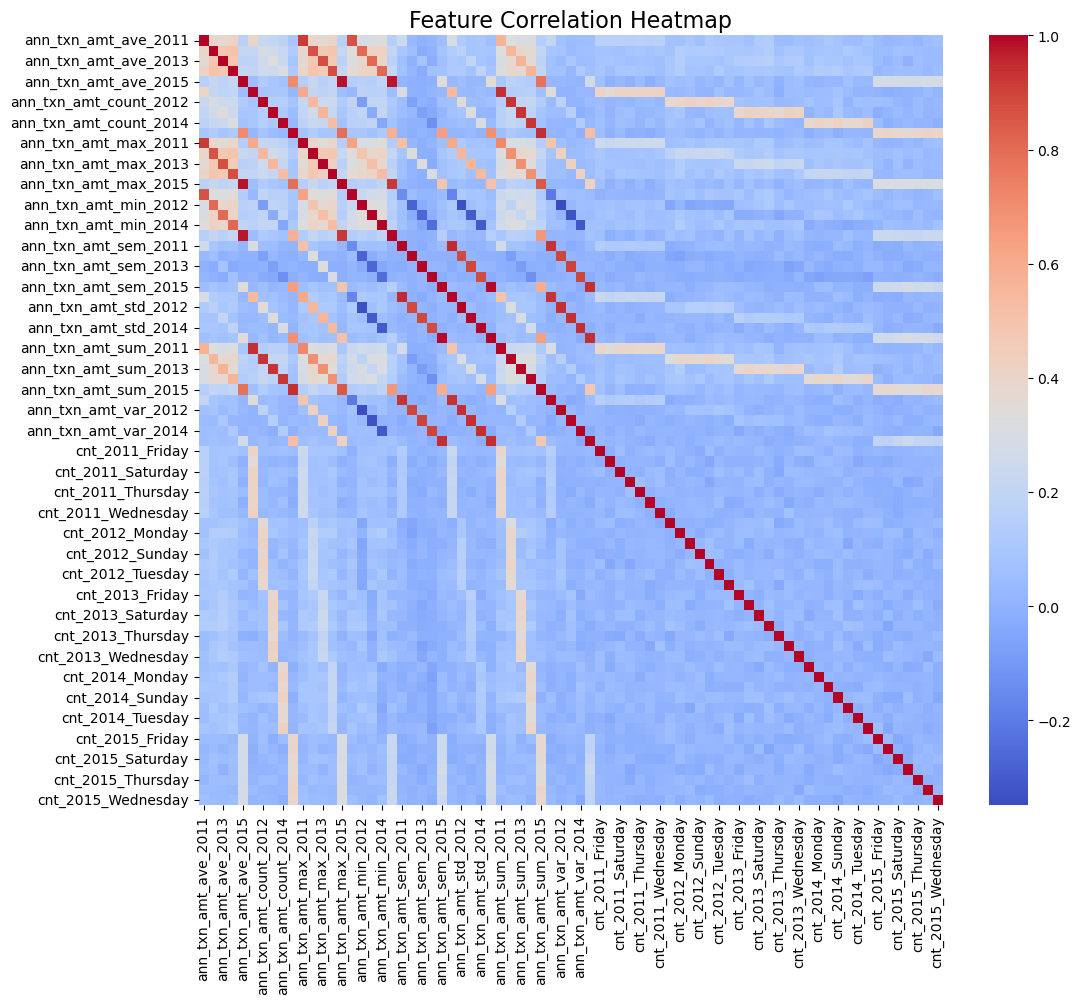

In [91]:
corr_matrix_annual = X_train_annual.corr()

# Set the figure size to make the plot larger
plt.figure(figsize=(12, 10))

# Plot the heatmap with annotations
sns.heatmap(corr_matrix_annual, cmap="coolwarm")

# Set the title
plt.title("Feature Correlation Heatmap", fontsize=16)

# Show the plot
plt.show()

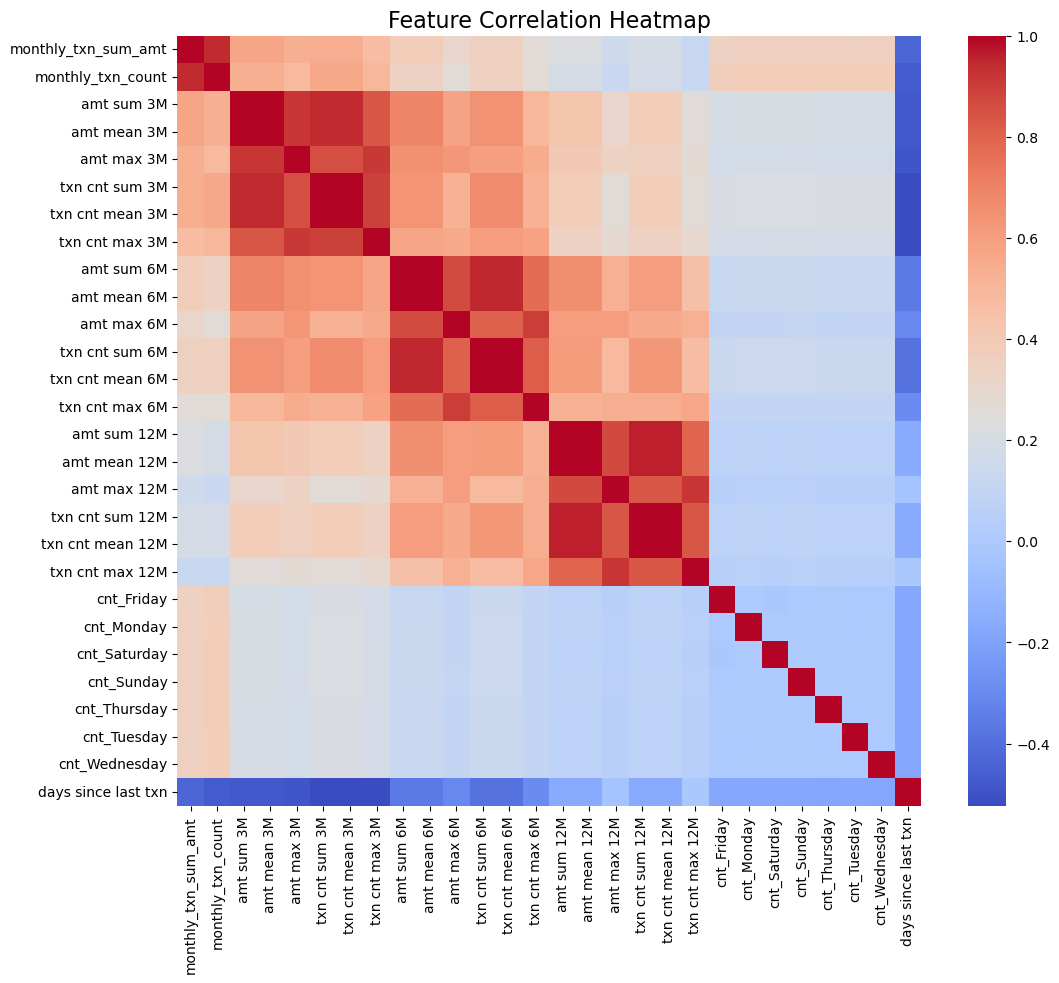

In [92]:
corr_matrix_monthly = X_train_monthly.corr()

# Set the figure size to make the plot larger
plt.figure(figsize=(12, 10))

# Plot the heatmap with annotations
sns.heatmap(corr_matrix_monthly, cmap="coolwarm")

# Set the title
plt.title("Feature Correlation Heatmap", fontsize=16)

# Show the plot
plt.show()

## Models

## logistic regrssion 

### Logistic Monthly 

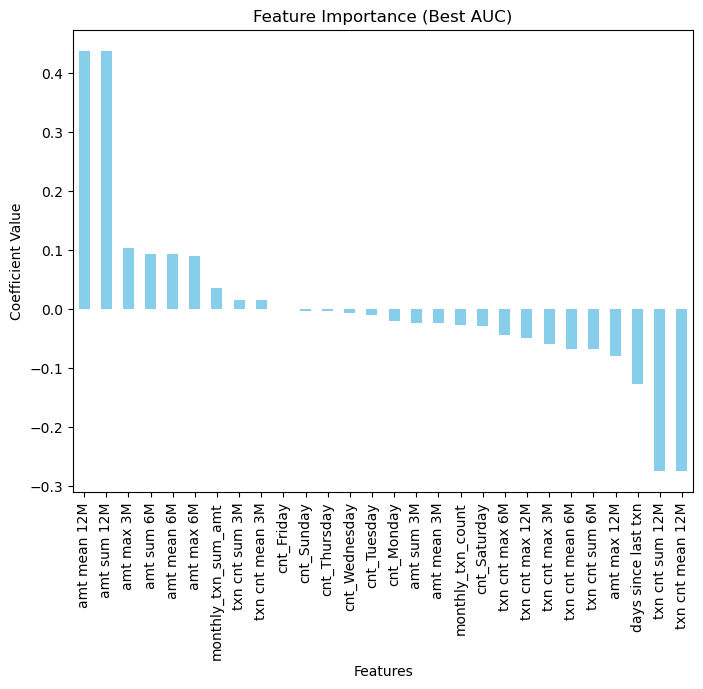

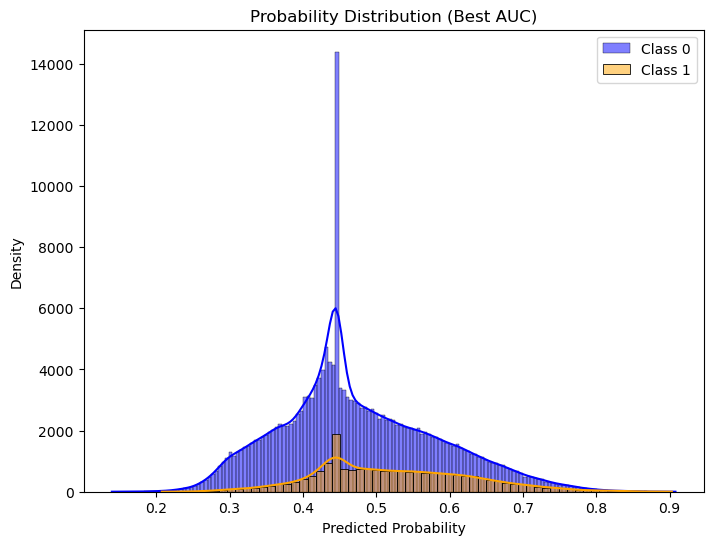

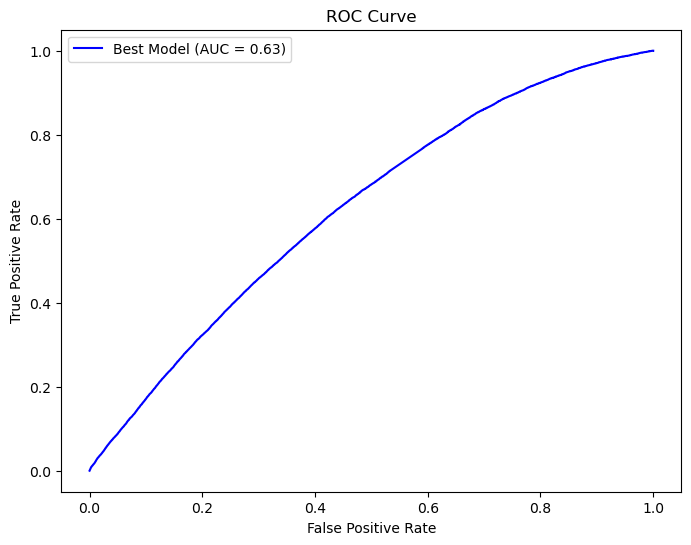

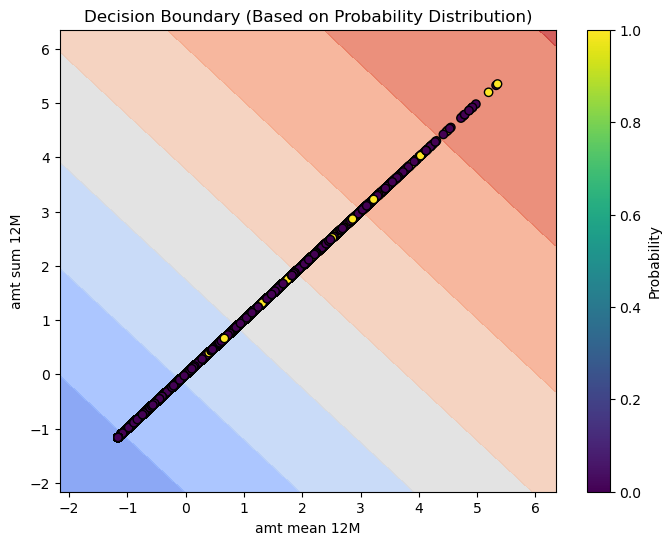

Best Model AUC:
Train AUC: 0.631, Test AUC: 0.626

Confusion Matrix:


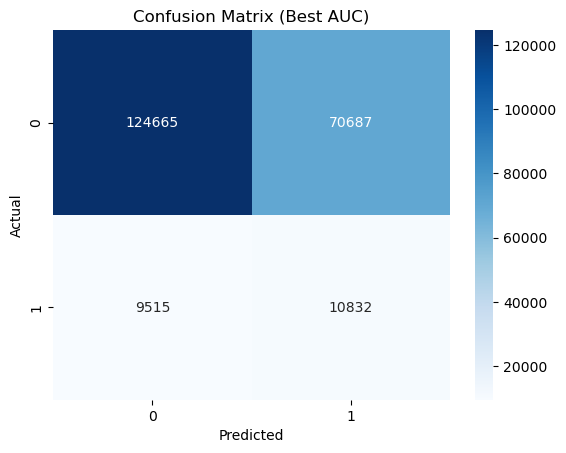


Precision and Recall for All Models:
C=0.0001: Precision=0.131, Recall=0.563
C=0.00025: Precision=0.132, Recall=0.550
C=0.0005: Precision=0.132, Recall=0.544
C=0.001: Precision=0.132, Recall=0.540
C=0.0025: Precision=0.133, Recall=0.535
C=0.005: Precision=0.133, Recall=0.532


{'best_model': LogisticRegression(C=0.005, class_weight='balanced', random_state=1147,
                    solver='liblinear'),
 'best_train_auc': 0.6310961757617767,
 'best_test_auc': 0.6256860354931701,
 'feature_importance': amt mean 12M           0.437036
 amt sum 12M            0.437036
 amt max 3M             0.102695
 amt sum 6M             0.093304
 amt mean 6M            0.093304
 amt max 6M             0.090401
 monthly_txn_sum_amt    0.036105
 txn cnt sum 3M         0.014931
 txn cnt mean 3M        0.014931
 cnt_Friday             0.000145
 cnt_Sunday            -0.003271
 cnt_Thursday          -0.003661
 cnt_Wednesday         -0.007109
 cnt_Tuesday           -0.009994
 cnt_Monday            -0.020564
 amt sum 3M            -0.023407
 amt mean 3M           -0.023407
 monthly_txn_count     -0.027419
 cnt_Saturday          -0.028246
 txn cnt max 6M        -0.043549
 txn cnt max 12M       -0.049114
 txn cnt max 3M        -0.059886
 txn cnt mean 6M       -0.068414
 txn cnt sum 6

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_score, recall_score, roc_curve
from sklearn.inspection import DecisionBoundaryDisplay
import seaborn as sns
import pandas as pd

def logistic_regression_with_tuning(X_train, Y_train, X_test, Y_test, C_values):
    results = []
    best_model = None
    best_auc = 0
    
    # Iterate over provided C values
    for C in C_values:
        model = LogisticRegression(C=C, solver='liblinear', class_weight="balanced", random_state=1147)
        model.fit(X_train, Y_train)
        
        # Predict probabilities
        train_probs = model.predict_proba(X_train)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]
        
        # Calculate AUC
        train_auc = roc_auc_score(Y_train, train_probs)
        test_auc = roc_auc_score(Y_test, test_probs)
        
        # Store results
        results.append({
            'C': C,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'model': model
        })
        
        # Update the best model
        if test_auc > best_auc:
            best_auc = test_auc
            best_model = model
    
    # Extract the best model details
    best_result = max(results, key=lambda x: x['test_auc'])
    best_model = best_result['model']
    best_train_auc = best_result['train_auc']
    best_test_auc = best_result['test_auc']
    
    # Predictions and probabilities
    Y_pred = best_model.predict(X_test)
    best_probs = best_model.predict_proba(X_test)[:, 1]
    
    # Feature Importance
    feature_importance = pd.Series(best_model.coef_[0], index=X_train.columns)
    feature_importance.sort_values(ascending=False, inplace=True)
    
    # Feature Importance Plot
    plt.figure(figsize=(8, 6))
    feature_importance.plot(kind='bar', color='skyblue')
    plt.title('Feature Importance (Best AUC)')
    plt.ylabel('Coefficient Value')
    plt.xlabel('Features')
    plt.show()
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    
    # Precision and Recall for all models
    precisions = [precision_score(Y_test, model['model'].predict(X_test)) for model in results]
    recalls = [recall_score(Y_test, model['model'].predict(X_test)) for model in results]
    
    # Probability Distribution Plot
    plt.figure(figsize=(8, 6))
    sns.histplot(best_probs[Y_test == 0], color='blue', label='Class 0', kde=True)
    sns.histplot(best_probs[Y_test == 1], color='orange', label='Class 1', kde=True)
    plt.title('Probability Distribution (Best AUC)')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Density')
    plt.legend()
    plt.show()
    
    # ROC Curve
    plt.figure(figsize=(8, 6))
    fpr, tpr, _ = roc_curve(Y_test, best_probs)
    plt.plot(fpr, tpr, label=f"Best Model (AUC = {best_test_auc:.2f})", color="blue")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()
    
    # Decision Boundary Plot Based on Probability Distribution
    top_features = feature_importance.index[:2]
    if len(top_features) == 2:  # Ensure only 2 features are selected
        X_train_2d = X_train[top_features]
        X_test_2d = X_test[top_features]
        
        # Retrain the best model with top 2 features
        best_model.fit(X_train_2d, Y_train)

        fig, ax = plt.subplots(figsize=(8, 6))
        DecisionBoundaryDisplay.from_estimator(
            best_model,
            X_test_2d,
            response_method="predict_proba",
            ax=ax,
            cmap="coolwarm",
            alpha=0.8,
        )
        plt.scatter(X_test_2d.iloc[:, 0], X_test_2d.iloc[:, 1], c=Y_test, edgecolor="k", cmap="viridis")
        plt.title("Decision Boundary (Based on Probability Distribution)")
        plt.xlabel(top_features[0])
        plt.ylabel(top_features[1])
        plt.colorbar(label="Probability")
        plt.show()
    
    # Display Results
    print("Best Model AUC:")
    print(f"Train AUC: {best_train_auc:.3f}, Test AUC: {best_test_auc:.3f}")
    
    print("\nConfusion Matrix:")
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Best AUC)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("\nPrecision and Recall for All Models:")
    for i, C in enumerate(C_values):
        print(f"C={C}: Precision={precisions[i]:.3f}, Recall={recalls[i]:.3f}")
    
    return {
        'best_model': best_model,
        'best_train_auc': best_train_auc,
        'best_test_auc': best_test_auc,
        'feature_importance': feature_importance,
        'confusion_matrix': conf_matrix,
        'precisions': precisions,
        'recalls': recalls
    }

# Example Call:
C_values = [0.0001, 0.00025, 0.0005, 0.001, 0.0025, 0.005]
logistic_regression_with_tuning(X_train_monthly, Y_train_monthly, X_test_monthly, Y_test_monthly, C_values)


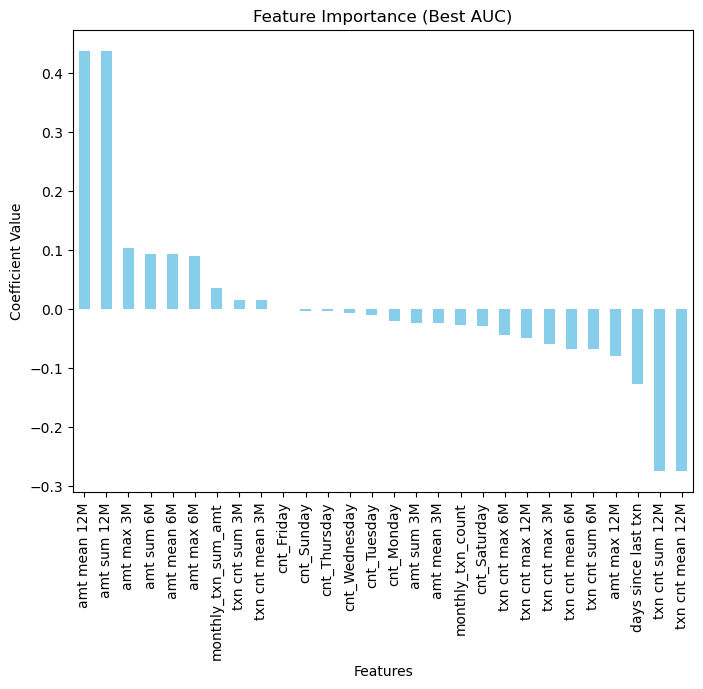

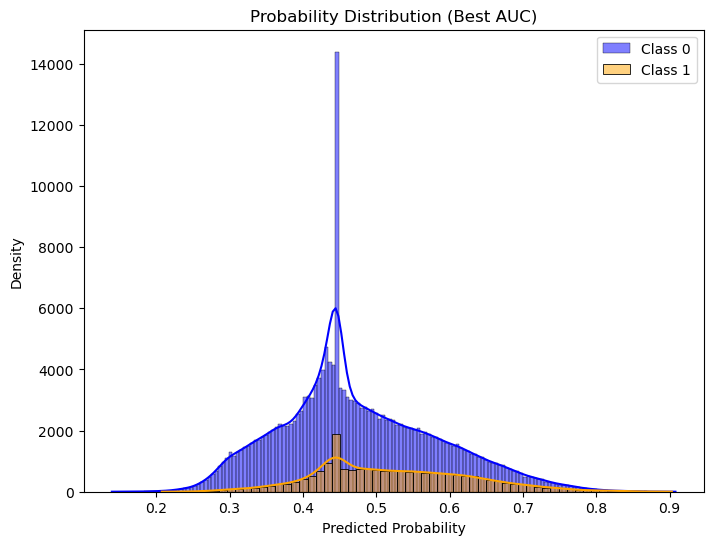

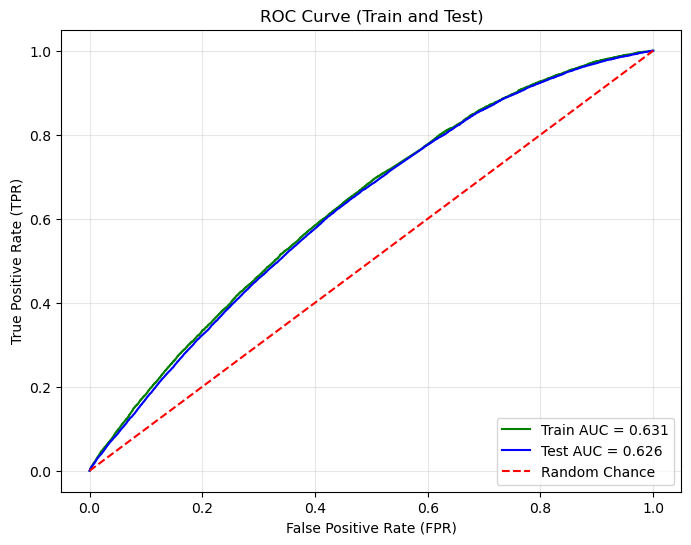

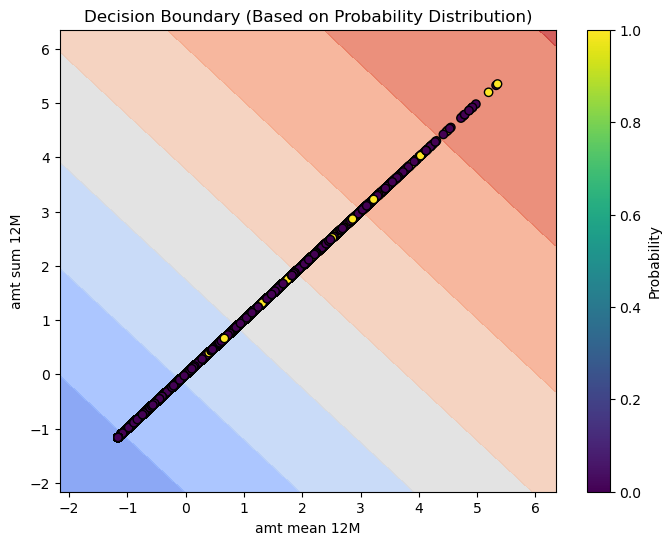

Best Model AUC:
Train AUC: 0.631, Test AUC: 0.626

Confusion Matrix:


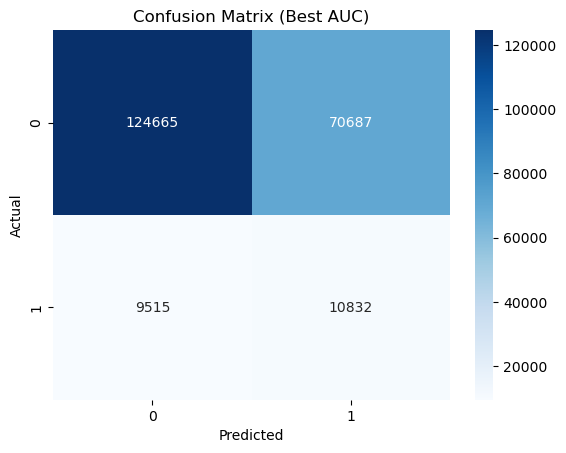


Precision and Recall for All Models:
C=0.0001: Precision=0.131, Recall=0.563
C=0.00025: Precision=0.132, Recall=0.550
C=0.0005: Precision=0.132, Recall=0.544
C=0.001: Precision=0.132, Recall=0.540
C=0.0025: Precision=0.133, Recall=0.535
C=0.005: Precision=0.133, Recall=0.532


{'best_model': LogisticRegression(C=0.005, class_weight='balanced', random_state=1147,
                    solver='liblinear'),
 'best_train_auc': 0.6310961757617767,
 'best_test_auc': 0.6256860354931701,
 'feature_importance': amt mean 12M           0.437036
 amt sum 12M            0.437036
 amt max 3M             0.102695
 amt sum 6M             0.093304
 amt mean 6M            0.093304
 amt max 6M             0.090401
 monthly_txn_sum_amt    0.036105
 txn cnt sum 3M         0.014931
 txn cnt mean 3M        0.014931
 cnt_Friday             0.000145
 cnt_Sunday            -0.003271
 cnt_Thursday          -0.003661
 cnt_Wednesday         -0.007109
 cnt_Tuesday           -0.009994
 cnt_Monday            -0.020564
 amt sum 3M            -0.023407
 amt mean 3M           -0.023407
 monthly_txn_count     -0.027419
 cnt_Saturday          -0.028246
 txn cnt max 6M        -0.043549
 txn cnt max 12M       -0.049114
 txn cnt max 3M        -0.059886
 txn cnt mean 6M       -0.068414
 txn cnt sum 6

In [94]:
def logistic_regression_with_tuning(X_train, Y_train, X_test, Y_test, C_values):
    results = []
    best_model = None
    best_auc = 0
    
    # Iterate over provided C values
    for C in C_values:
        model = LogisticRegression(C=C, solver='liblinear', class_weight="balanced", random_state=1147)
        model.fit(X_train, Y_train)
        
        # Predict probabilities
        train_probs = model.predict_proba(X_train)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]
        
        # Calculate AUC
        train_auc = roc_auc_score(Y_train, train_probs)
        test_auc = roc_auc_score(Y_test, test_probs)
        
        # Store results
        results.append({
            'C': C,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'model': model
        })
        
        # Update the best model
        if test_auc > best_auc:
            best_auc = test_auc
            best_model = model
    
    # Extract the best model details
    best_result = max(results, key=lambda x: x['test_auc'])
    best_model = best_result['model']
    best_train_auc = best_result['train_auc']
    best_test_auc = best_result['test_auc']
    
    # Predictions and probabilities
    Y_pred = best_model.predict(X_test)
    best_probs = best_model.predict_proba(X_test)[:, 1]
    
    # Feature Importance
    feature_importance = pd.Series(best_model.coef_[0], index=X_train.columns)
    feature_importance.sort_values(ascending=False, inplace=True)
    
    # Feature Importance Plot
    plt.figure(figsize=(8, 6))
    feature_importance.plot(kind='bar', color='skyblue')
    plt.title('Feature Importance (Best AUC)')
    plt.ylabel('Coefficient Value')
    plt.xlabel('Features')
    plt.show()
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    
    # Precision and Recall for all models
    precisions = [precision_score(Y_test, model['model'].predict(X_test)) for model in results]
    recalls = [recall_score(Y_test, model['model'].predict(X_test)) for model in results]
    
    # Probability Distribution Plot
    plt.figure(figsize=(8, 6))
    sns.histplot(best_probs[Y_test == 0], color='blue', label='Class 0', kde=True)
    sns.histplot(best_probs[Y_test == 1], color='orange', label='Class 1', kde=True)
    plt.title('Probability Distribution (Best AUC)')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Density')
    plt.legend()
    plt.show()
    
    # ROC Curve for Train and Test
    plt.figure(figsize=(8, 6))
    fpr_train, tpr_train, _ = roc_curve(Y_train, best_model.predict_proba(X_train)[:, 1])
    plt.plot(fpr_train, tpr_train, label=f"Train AUC = {best_train_auc:.3f}", color="green")
    fpr_test, tpr_test, _ = roc_curve(Y_test, best_probs)
    plt.plot(fpr_test, tpr_test, label=f"Test AUC = {best_test_auc:.3f}", color="blue")
    plt.plot([0, 1], [0, 1], 'r--', label="Random Chance")
    plt.title("ROC Curve (Train and Test)")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    # Decision Boundary Plot Based on Probability Distribution
    top_features = feature_importance.index[:2]
    if len(top_features) == 2:  # Ensure only 2 features are selected
        X_train_2d = X_train[top_features]
        X_test_2d = X_test[top_features]
        
        # Retrain the best model with top 2 features
        best_model.fit(X_train_2d, Y_train)

        fig, ax = plt.subplots(figsize=(8, 6))
        DecisionBoundaryDisplay.from_estimator(
            best_model,
            X_test_2d,
            response_method="predict_proba",
            ax=ax,
            cmap="coolwarm",
            alpha=0.8,
        )
        plt.scatter(X_test_2d.iloc[:, 0], X_test_2d.iloc[:, 1], c=Y_test, edgecolor="k", cmap="viridis")
        plt.title("Decision Boundary (Based on Probability Distribution)")
        plt.xlabel(top_features[0])
        plt.ylabel(top_features[1])
        plt.colorbar(label="Probability")
        plt.show()
    
    # Display Results
    print("Best Model AUC:")
    print(f"Train AUC: {best_train_auc:.3f}, Test AUC: {best_test_auc:.3f}")
    
    print("\nConfusion Matrix:")
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Best AUC)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("\nPrecision and Recall for All Models:")
    for i, C in enumerate(C_values):
        print(f"C={C}: Precision={precisions[i]:.3f}, Recall={recalls[i]:.3f}")
    
    return {
        'best_model': best_model,
        'best_train_auc': best_train_auc,
        'best_test_auc': best_test_auc,
        'feature_importance': feature_importance,
        'confusion_matrix': conf_matrix,
        'precisions': precisions,
        'recalls': recalls
    }

C_values = [0.0001, 0.00025, 0.0005, 0.001, 0.0025, 0.005]
logistic_regression_with_tuning(X_train_monthly, Y_train_monthly, X_test_monthly, Y_test_monthly, C_values)



### Logistic annual 

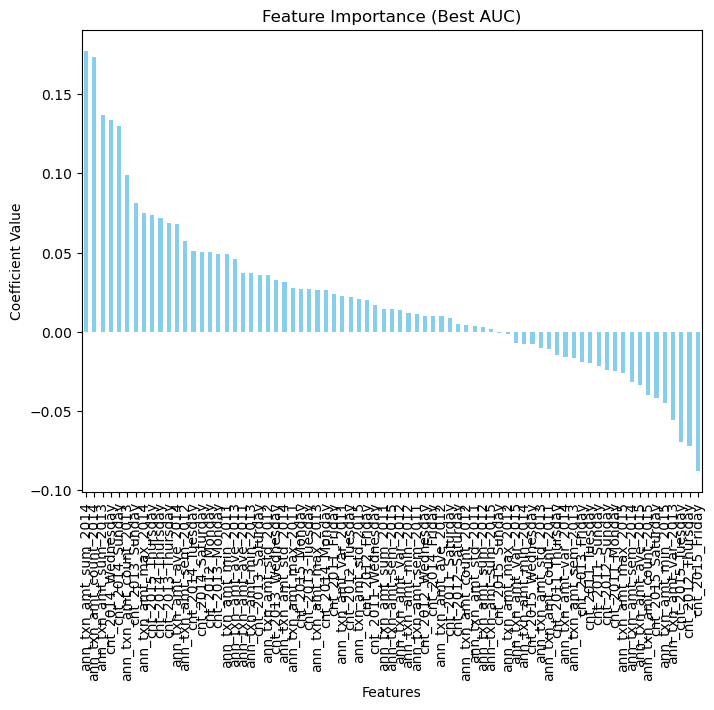

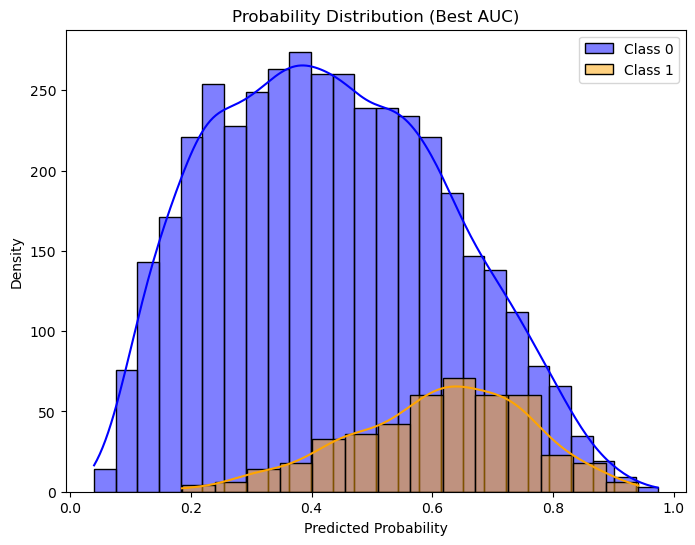

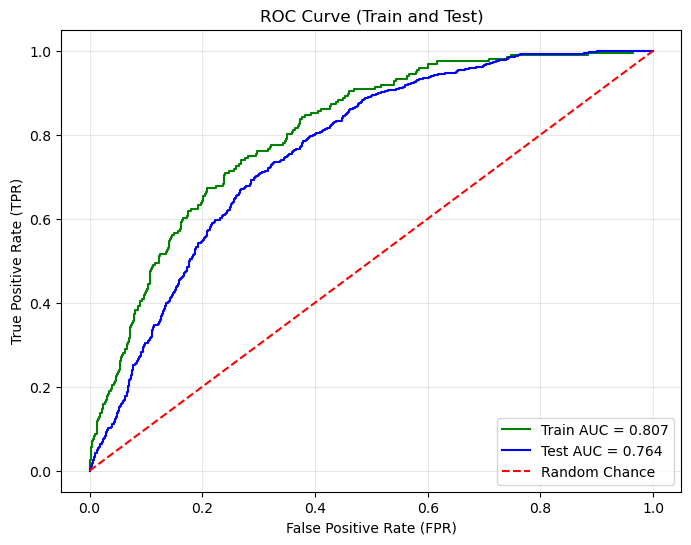

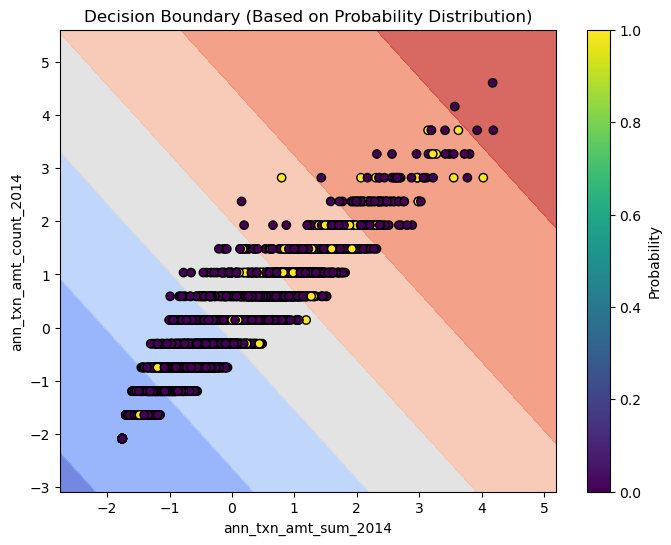

Best Model AUC:
Train AUC: 0.807, Test AUC: 0.764

Confusion Matrix:


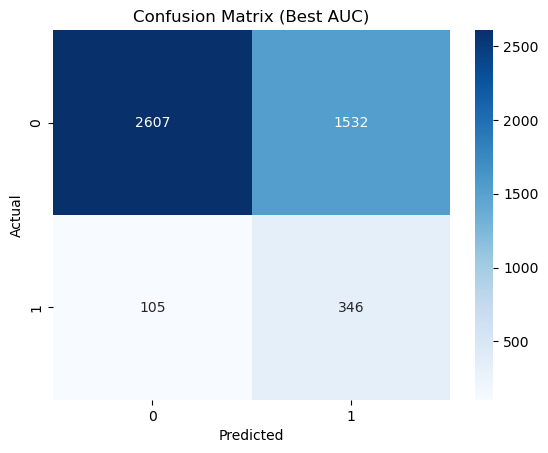


Precision and Recall for All Models:
C=0.0001: Precision=0.153, Recall=0.869
C=0.00025: Precision=0.161, Recall=0.867
C=0.0005: Precision=0.170, Recall=0.858
C=0.001: Precision=0.176, Recall=0.825
C=0.0025: Precision=0.184, Recall=0.767
C=0.005: Precision=0.193, Recall=0.734


{'best_model': LogisticRegression(C=0.0025, class_weight='balanced', random_state=1147,
                    solver='liblinear'),
 'best_train_auc': 0.8069808953133208,
 'best_test_auc': 0.7641294291657581,
 'feature_importance': ann_txn_amt_sum_2014      0.177370
 ann_txn_amt_count_2014    0.173275
 ann_txn_amt_sum_2013      0.136715
 cnt_2014_Wednesday        0.133708
 cnt_2014_Sunday           0.130236
                             ...   
 ann_txn_amt_min_2015     -0.044540
 ann_txn_amt_var_2013     -0.055459
 cnt_2015_Tuesday         -0.069208
 cnt_2012_Thursday        -0.071882
 cnt_2015_Friday          -0.087643
 Length: 75, dtype: float64,
 'confusion_matrix': array([[2607, 1532],
        [ 105,  346]], dtype=int64),
 'precisions': [0.1532447224394058,
  0.16137020222864218,
  0.16973684210526316,
  0.1759697256385998,
  0.18423855165069222,
  0.19266589057043074],
 'recalls': [0.8691796008869179,
  0.8669623059866962,
  0.8580931263858093,
  0.8248337028824834,
  0.76718403547671

In [95]:
def logistic_regression_with_tuning(X_train, Y_train, X_test, Y_test, C_values):
    results = []
    best_model = None
    best_auc = 0
    
    # Iterate over provided C values
    for C in C_values:
        model = LogisticRegression(C=C, solver='liblinear', class_weight="balanced", random_state=1147)
        model.fit(X_train, Y_train)
        
        # Predict probabilities
        train_probs = model.predict_proba(X_train)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]
        
        # Calculate AUC
        train_auc = roc_auc_score(Y_train, train_probs)
        test_auc = roc_auc_score(Y_test, test_probs)
        
        # Store results
        results.append({
            'C': C,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'model': model
        })
        
        # Update the best model
        if test_auc > best_auc:
            best_auc = test_auc
            best_model = model
    
    # Extract the best model details
    best_result = max(results, key=lambda x: x['test_auc'])
    best_model = best_result['model']
    best_train_auc = best_result['train_auc']
    best_test_auc = best_result['test_auc']
    
    # Predictions and probabilities
    Y_pred = best_model.predict(X_test)
    best_probs = best_model.predict_proba(X_test)[:, 1]
    
    # Feature Importance
    feature_importance = pd.Series(best_model.coef_[0], index=X_train.columns)
    feature_importance.sort_values(ascending=False, inplace=True)
    
    # Feature Importance Plot
    plt.figure(figsize=(8, 6))
    feature_importance.plot(kind='bar', color='skyblue')
    plt.title('Feature Importance (Best AUC)')
    plt.ylabel('Coefficient Value')
    plt.xlabel('Features')
    plt.show()
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    
    # Precision and Recall for all models
    precisions = [precision_score(Y_test, model['model'].predict(X_test)) for model in results]
    recalls = [recall_score(Y_test, model['model'].predict(X_test)) for model in results]
    
    # Probability Distribution Plot
    plt.figure(figsize=(8, 6))
    sns.histplot(best_probs[Y_test == 0], color='blue', label='Class 0', kde=True)
    sns.histplot(best_probs[Y_test == 1], color='orange', label='Class 1', kde=True)
    plt.title('Probability Distribution (Best AUC)')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Density')
    plt.legend()
    plt.show()
    
    # ROC Curve for Train and Test
    plt.figure(figsize=(8, 6))
    fpr_train, tpr_train, _ = roc_curve(Y_train, best_model.predict_proba(X_train)[:, 1])
    plt.plot(fpr_train, tpr_train, label=f"Train AUC = {best_train_auc:.3f}", color="green")
    fpr_test, tpr_test, _ = roc_curve(Y_test, best_probs)
    plt.plot(fpr_test, tpr_test, label=f"Test AUC = {best_test_auc:.3f}", color="blue")
    plt.plot([0, 1], [0, 1], 'r--', label="Random Chance")
    plt.title("ROC Curve (Train and Test)")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    # Decision Boundary Plot Based on Probability Distribution
    top_features = feature_importance.index[:2]
    if len(top_features) == 2:  # Ensure only 2 features are selected
        X_train_2d = X_train[top_features]
        X_test_2d = X_test[top_features]
        
        # Retrain the best model with top 2 features
        best_model.fit(X_train_2d, Y_train)

        fig, ax = plt.subplots(figsize=(8, 6))
        DecisionBoundaryDisplay.from_estimator(
            best_model,
            X_test_2d,
            response_method="predict_proba",
            ax=ax,
            cmap="coolwarm",
            alpha=0.8,
        )
        plt.scatter(X_test_2d.iloc[:, 0], X_test_2d.iloc[:, 1], c=Y_test, edgecolor="k", cmap="viridis")
        plt.title("Decision Boundary (Based on Probability Distribution)")
        plt.xlabel(top_features[0])
        plt.ylabel(top_features[1])
        plt.colorbar(label="Probability")
        plt.show()
    
    # Display Results
    print("Best Model AUC:")
    print(f"Train AUC: {best_train_auc:.3f}, Test AUC: {best_test_auc:.3f}")
    
    print("\nConfusion Matrix:")
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Best AUC)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("\nPrecision and Recall for All Models:")
    for i, C in enumerate(C_values):
        print(f"C={C}: Precision={precisions[i]:.3f}, Recall={recalls[i]:.3f}")
    
    return {
        'best_model': best_model,
        'best_train_auc': best_train_auc,
        'best_test_auc': best_test_auc,
        'feature_importance': feature_importance,
        'confusion_matrix': conf_matrix,
        'precisions': precisions,
        'recalls': recalls
    }

C_values = [0.0001, 0.00025, 0.0005, 0.001, 0.0025, 0.005]
logistic_regression_with_tuning(X_train_annual, Y_train_annual, X_test_annual, Y_test_annual, C_values)



# Decision tree 

## Decision tree monthly 

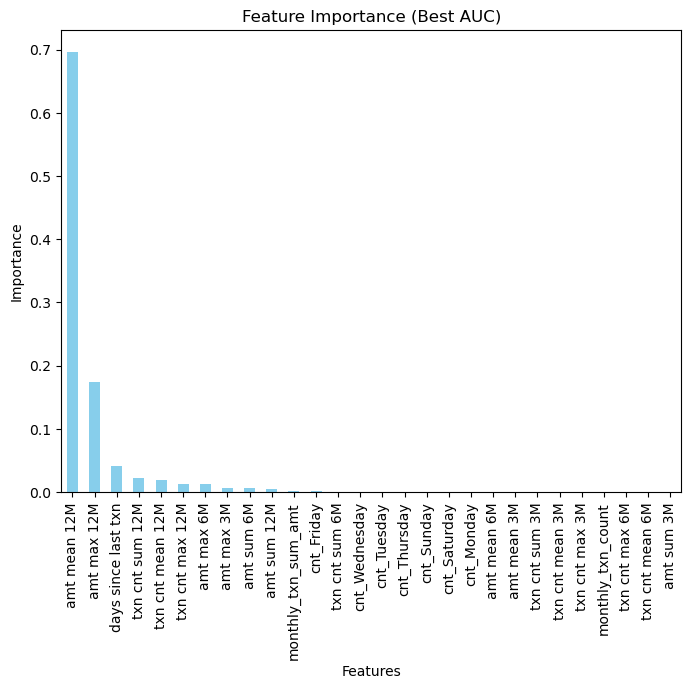

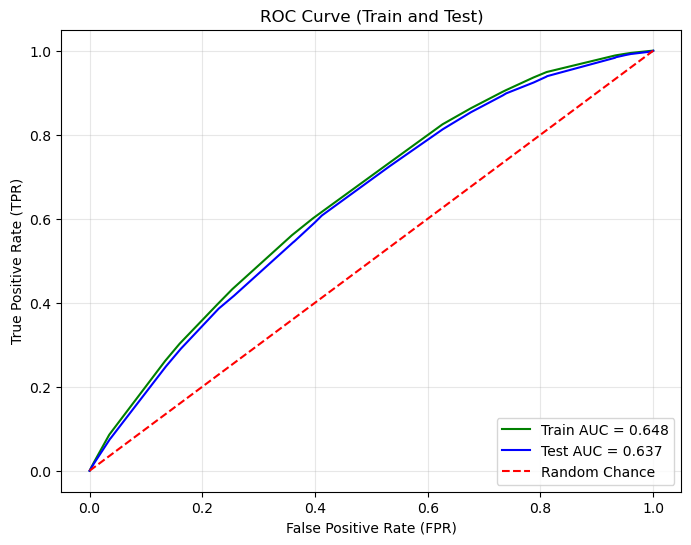

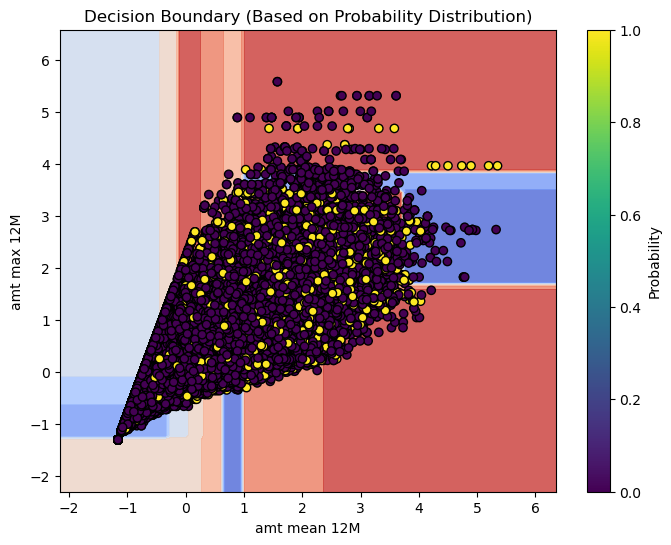

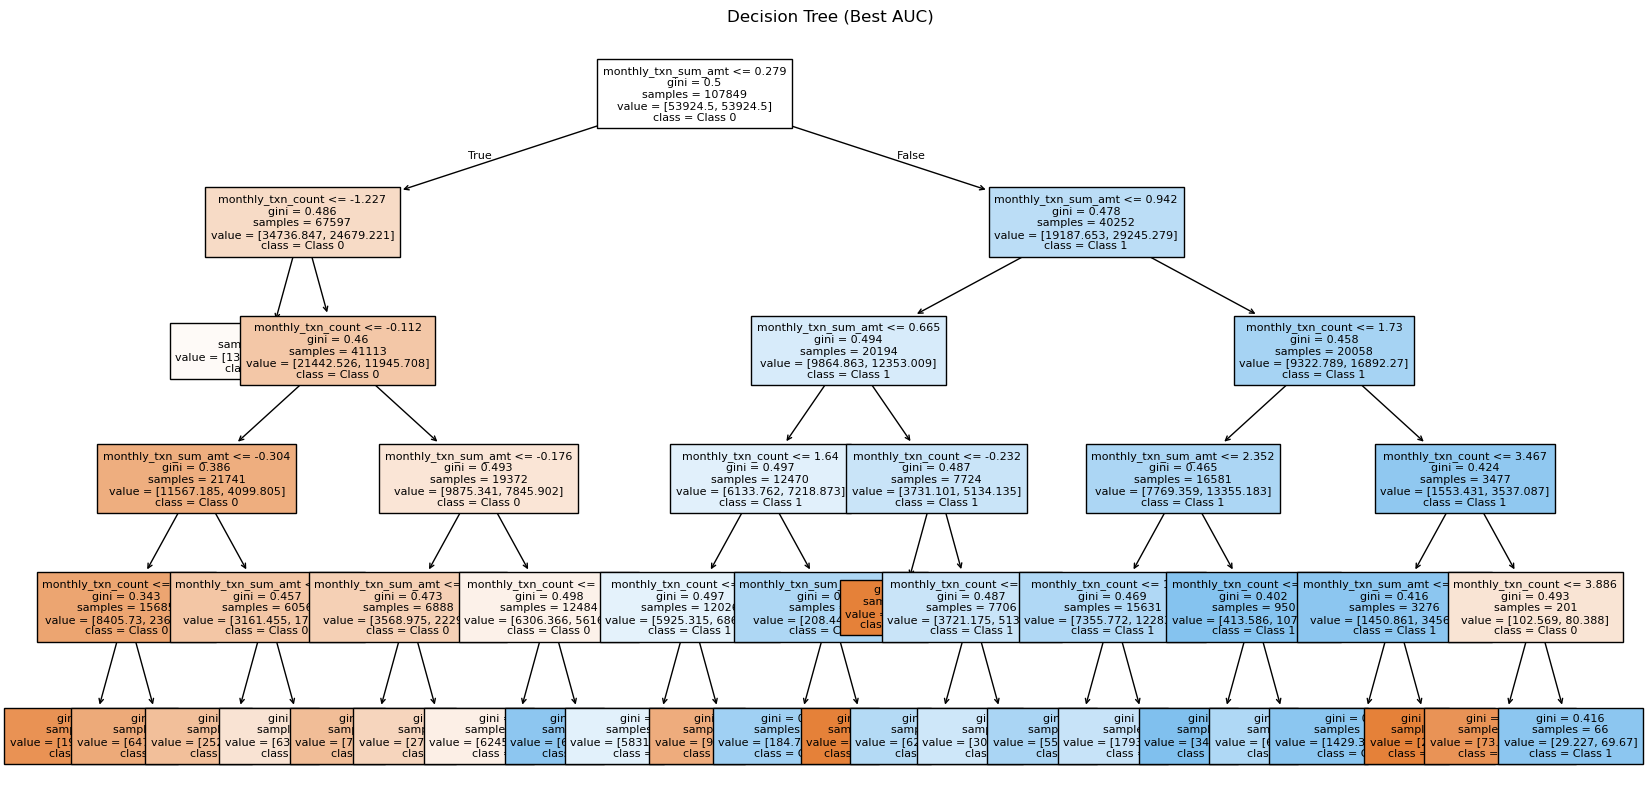

Best Model AUC:
Train AUC: 0.648, Test AUC: 0.637

Confusion Matrix:


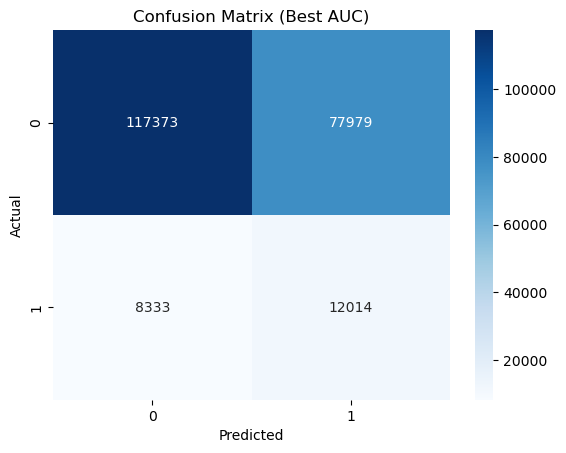


AUC and Hyperparameter Tuning Results:
Max Depth=1: Train AUC=0.593, Test AUC=0.591
Max Depth=2: Train AUC=0.622, Test AUC=0.619
Max Depth=3: Train AUC=0.635, Test AUC=0.631
Max Depth=4: Train AUC=0.641, Test AUC=0.635
Max Depth=5: Train AUC=0.648, Test AUC=0.637


{'best_model': DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=1147),
 'best_train_auc': 0.6479179659296933,
 'best_test_auc': 0.6366371430314455,
 'feature_importance': amt mean 12M           0.696049
 amt max 12M            0.174564
 days since last txn    0.041967
 txn cnt sum 12M        0.022027
 txn cnt mean 12M       0.019433
 txn cnt max 12M        0.012471
 amt max 6M             0.012144
 amt max 3M             0.006660
 amt sum 6M             0.006637
 amt sum 12M            0.004550
 monthly_txn_sum_amt    0.002164
 cnt_Friday             0.001335
 txn cnt sum 6M         0.000000
 cnt_Wednesday          0.000000
 cnt_Tuesday            0.000000
 cnt_Thursday           0.000000
 cnt_Sunday             0.000000
 cnt_Saturday           0.000000
 cnt_Monday             0.000000
 amt mean 6M            0.000000
 amt mean 3M            0.000000
 txn cnt sum 3M         0.000000
 txn cnt mean 3M        0.000000
 txn cnt max 3M         0.000000
 monthly_txn_

In [96]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

def decision_tree_with_tuning(X_train, Y_train, X_test, Y_test, max_depth_values):
    results = []
    best_model = None
    best_auc = 0
    
    # Iterate over provided max_depth values
    for depth in max_depth_values:
        model = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=1147)
        model.fit(X_train, Y_train)
        
        # Predict probabilities
        train_probs = model.predict_proba(X_train)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]
        
        # Calculate AUC
        train_auc = roc_auc_score(Y_train, train_probs)
        test_auc = roc_auc_score(Y_test, test_probs)
        
        # Store results
        results.append({
            'max_depth': depth,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'model': model
        })
        
        # Update the best model
        if test_auc > best_auc:
            best_auc = test_auc
            best_model = model
    
    # Extract the best model details
    best_result = max(results, key=lambda x: x['test_auc'])
    best_model = best_result['model']
    best_train_auc = best_result['train_auc']
    best_test_auc = best_result['test_auc']
    
    # Predictions and probabilities
    Y_pred = best_model.predict(X_test)
    best_probs = best_model.predict_proba(X_test)[:, 1]
    
    # Feature Importance
    feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
    feature_importance.sort_values(ascending=False, inplace=True)
    
    # Feature Importance Plot
    plt.figure(figsize=(8, 6))
    feature_importance.plot(kind='bar', color='skyblue')
    plt.title('Feature Importance (Best AUC)')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.show()
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    
    # ROC Curve for Train and Test
    plt.figure(figsize=(8, 6))
    fpr_train, tpr_train, _ = roc_curve(Y_train, best_model.predict_proba(X_train)[:, 1])
    plt.plot(fpr_train, tpr_train, label=f"Train AUC = {best_train_auc:.3f}", color="green")
    fpr_test, tpr_test, _ = roc_curve(Y_test, best_probs)
    plt.plot(fpr_test, tpr_test, label=f"Test AUC = {best_test_auc:.3f}", color="blue")
    plt.plot([0, 1], [0, 1], 'r--', label="Random Chance")
    plt.title("ROC Curve (Train and Test)")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    # Decision Boundary Plot Based on Probability Distribution
    top_features = feature_importance.index[:2]
    if len(top_features) == 2:  # Ensure only 2 features are selected
        X_train_2d = X_train[top_features]
        X_test_2d = X_test[top_features]
        
        # Retrain the best model with top 2 features
        best_model.fit(X_train_2d, Y_train)

        fig, ax = plt.subplots(figsize=(8, 6))
        DecisionBoundaryDisplay.from_estimator(
            best_model,
            X_test_2d,
            response_method="predict_proba",
            ax=ax,
            cmap="coolwarm",
            alpha=0.8,
        )
        plt.scatter(X_test_2d.iloc[:, 0], X_test_2d.iloc[:, 1], c=Y_test, edgecolor="k", cmap="viridis")
        plt.title("Decision Boundary (Based on Probability Distribution)")
        plt.xlabel(top_features[0])
        plt.ylabel(top_features[1])
        plt.colorbar(label="Probability")
        plt.show()
    
    # Tree Plot
    plt.figure(figsize=(20, 10))
    plot_tree(best_model, feature_names=X_train.columns, class_names=["Class 0", "Class 1"], filled=True, fontsize=8)
    plt.title("Decision Tree (Best AUC)")
    plt.show()
    
    # Display Results
    print("Best Model AUC:")
    print(f"Train AUC: {best_train_auc:.3f}, Test AUC: {best_test_auc:.3f}")
    
    print("\nConfusion Matrix:")
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Best AUC)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("\nAUC and Hyperparameter Tuning Results:")
    for result in results:
        print(f"Max Depth={result['max_depth']}: Train AUC={result['train_auc']:.3f}, Test AUC={result['test_auc']:.3f}")
    
    return {
        'best_model': best_model,
        'best_train_auc': best_train_auc,
        'best_test_auc': best_test_auc,
        'feature_importance': feature_importance,
        'confusion_matrix': conf_matrix
    }

# Example Call
# max_depth_values = [2, 4, 6, 8, 10]
# results = decision_tree_with_tuning(X_train, Y_train, X_test, Y_test, max_depth_values)

max_depth_values = [1,2,3,4,5]
decision_tree_with_tuning(X_train_monthly, Y_train_monthly, X_test_monthly, Y_test_monthly, max_depth_values)


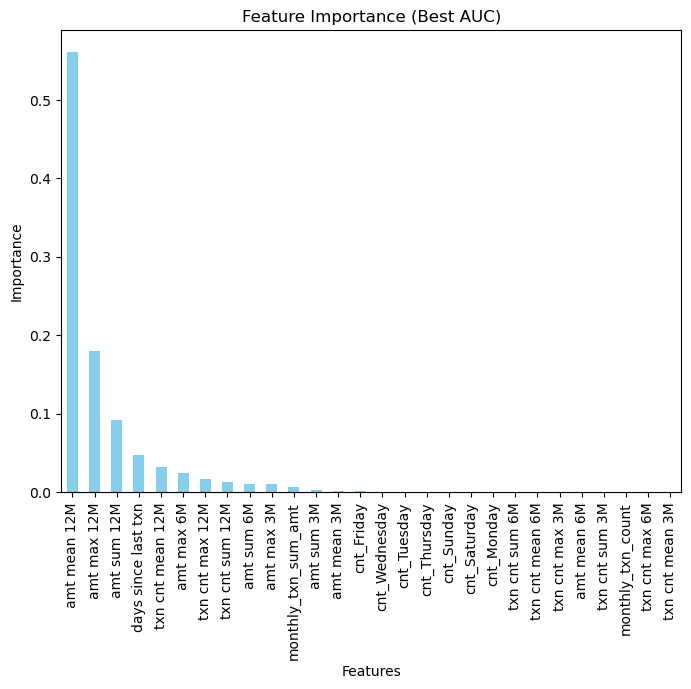

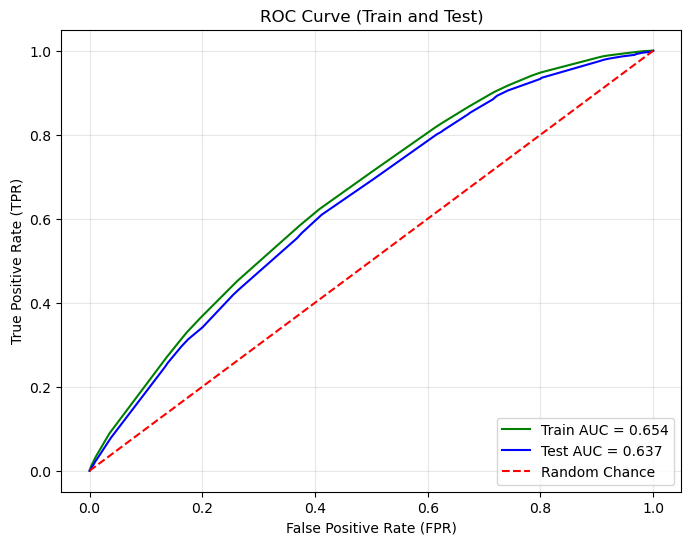

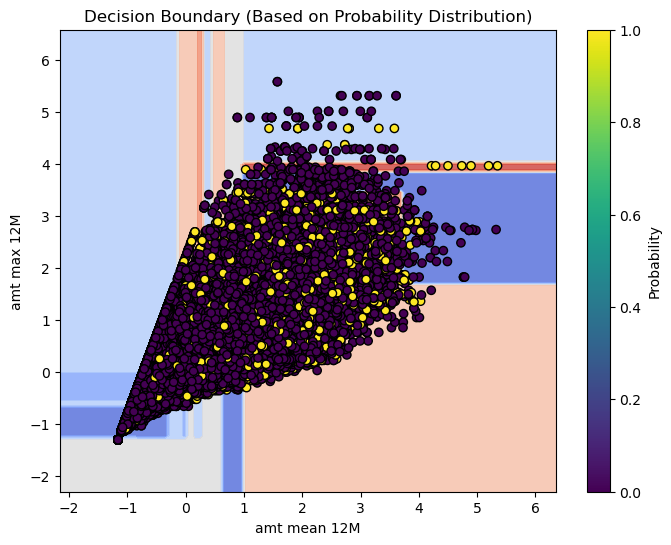

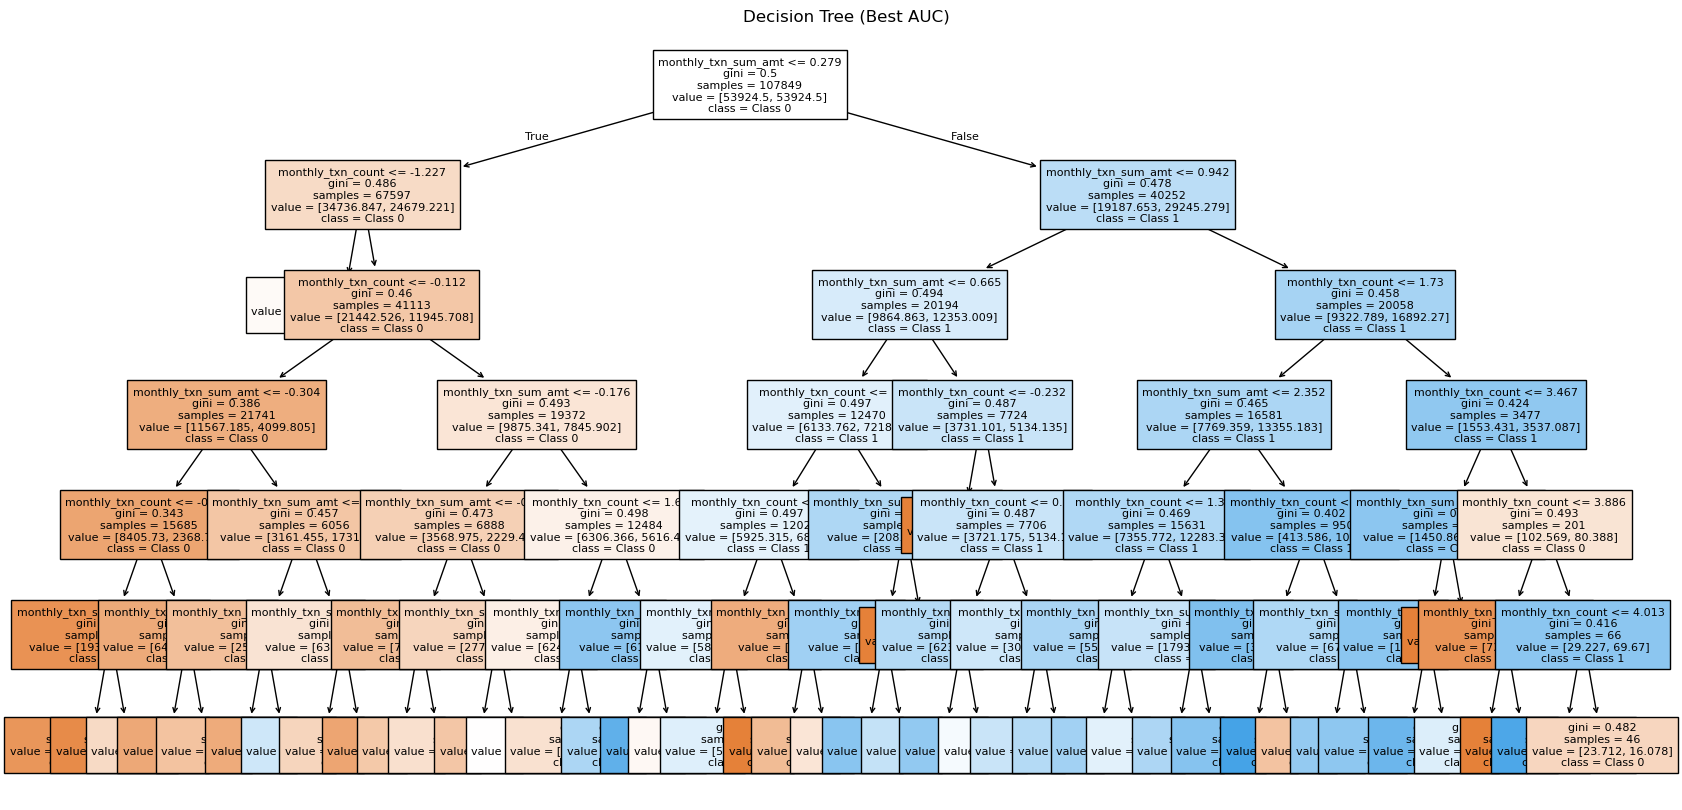

Best Model AUC:
Train AUC: 0.654, Test AUC: 0.637

Confusion Matrix:


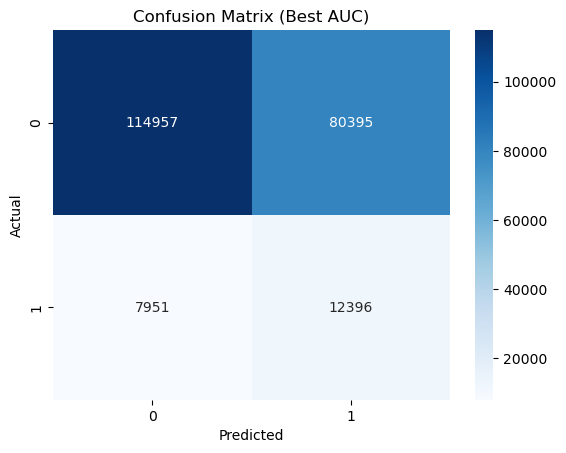


AUC and Hyperparameter Tuning Results:
Max Depth=1: Train AUC=0.593, Test AUC=0.591
Max Depth=2: Train AUC=0.622, Test AUC=0.619
Max Depth=3: Train AUC=0.635, Test AUC=0.631
Max Depth=4: Train AUC=0.641, Test AUC=0.635
Max Depth=5: Train AUC=0.648, Test AUC=0.637
Max Depth=6: Train AUC=0.654, Test AUC=0.637
Max Depth=7: Train AUC=0.663, Test AUC=0.636
Max Depth=8: Train AUC=0.673, Test AUC=0.634
Max Depth=9: Train AUC=0.685, Test AUC=0.630
Max Depth=10: Train AUC=0.699, Test AUC=0.627
Max Depth=15: Train AUC=0.800, Test AUC=0.607


{'best_model': DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=1147),
 'best_train_auc': 0.6541486922937136,
 'best_test_auc': 0.6372595217941884,
 'feature_importance': amt mean 12M           0.560868
 amt max 12M            0.180427
 amt sum 12M            0.091987
 days since last txn    0.046707
 txn cnt mean 12M       0.032544
 amt max 6M             0.023953
 txn cnt max 12M        0.016942
 txn cnt sum 12M        0.013402
 amt sum 6M             0.010762
 amt max 3M             0.010430
 monthly_txn_sum_amt    0.006112
 amt sum 3M             0.002758
 amt mean 3M            0.001890
 cnt_Friday             0.001219
 cnt_Wednesday          0.000000
 cnt_Tuesday            0.000000
 cnt_Thursday           0.000000
 cnt_Sunday             0.000000
 cnt_Saturday           0.000000
 cnt_Monday             0.000000
 txn cnt sum 6M         0.000000
 txn cnt mean 6M        0.000000
 txn cnt max 3M         0.000000
 amt mean 6M            0.000000
 txn cnt sum 

In [97]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

def decision_tree_with_tuning(X_train, Y_train, X_test, Y_test, max_depth_values):
    results = []
    best_model = None
    best_auc = 0
    
    # Iterate over provided max_depth values
    for depth in max_depth_values:
        model = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=1147)
        model.fit(X_train, Y_train)
        
        # Predict probabilities
        train_probs = model.predict_proba(X_train)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]
        
        # Calculate AUC
        train_auc = roc_auc_score(Y_train, train_probs)
        test_auc = roc_auc_score(Y_test, test_probs)
        
        # Store results
        results.append({
            'max_depth': depth,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'model': model
        })
        
        # Update the best model
        if test_auc > best_auc:
            best_auc = test_auc
            best_model = model
    
    # Extract the best model details
    best_result = max(results, key=lambda x: x['test_auc'])
    best_model = best_result['model']
    best_train_auc = best_result['train_auc']
    best_test_auc = best_result['test_auc']
    
    # Predictions and probabilities
    Y_pred = best_model.predict(X_test)
    best_probs = best_model.predict_proba(X_test)[:, 1]
    
    # Feature Importance
    feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
    feature_importance.sort_values(ascending=False, inplace=True)
    
    # Feature Importance Plot
    plt.figure(figsize=(8, 6))
    feature_importance.plot(kind='bar', color='skyblue')
    plt.title('Feature Importance (Best AUC)')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.show()
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    
    # ROC Curve for Train and Test
    plt.figure(figsize=(8, 6))
    fpr_train, tpr_train, _ = roc_curve(Y_train, best_model.predict_proba(X_train)[:, 1])
    plt.plot(fpr_train, tpr_train, label=f"Train AUC = {best_train_auc:.3f}", color="green")
    fpr_test, tpr_test, _ = roc_curve(Y_test, best_probs)
    plt.plot(fpr_test, tpr_test, label=f"Test AUC = {best_test_auc:.3f}", color="blue")
    plt.plot([0, 1], [0, 1], 'r--', label="Random Chance")
    plt.title("ROC Curve (Train and Test)")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    # Decision Boundary Plot Based on Probability Distribution
    top_features = feature_importance.index[:2]
    if len(top_features) == 2:  # Ensure only 2 features are selected
        X_train_2d = X_train[top_features]
        X_test_2d = X_test[top_features]
        
        # Retrain the best model with top 2 features
        best_model.fit(X_train_2d, Y_train)

        fig, ax = plt.subplots(figsize=(8, 6))
        DecisionBoundaryDisplay.from_estimator(
            best_model,
            X_test_2d,
            response_method="predict_proba",
            ax=ax,
            cmap="coolwarm",
            alpha=0.8,
        )
        plt.scatter(X_test_2d.iloc[:, 0], X_test_2d.iloc[:, 1], c=Y_test, edgecolor="k", cmap="viridis")
        plt.title("Decision Boundary (Based on Probability Distribution)")
        plt.xlabel(top_features[0])
        plt.ylabel(top_features[1])
        plt.colorbar(label="Probability")
        plt.show()
    
    # Tree Plot
    plt.figure(figsize=(20, 10))
    plot_tree(best_model, feature_names=X_train.columns, class_names=["Class 0", "Class 1"], filled=True, fontsize=8)
    plt.title("Decision Tree (Best AUC)")
    plt.show()
    
    # Display Results
    print("Best Model AUC:")
    print(f"Train AUC: {best_train_auc:.3f}, Test AUC: {best_test_auc:.3f}")
    
    print("\nConfusion Matrix:")
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Best AUC)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("\nAUC and Hyperparameter Tuning Results:")
    for result in results:
        print(f"Max Depth={result['max_depth']}: Train AUC={result['train_auc']:.3f}, Test AUC={result['test_auc']:.3f}")
    
    return {
        'best_model': best_model,
        'best_train_auc': best_train_auc,
        'best_test_auc': best_test_auc,
        'feature_importance': feature_importance,
        'confusion_matrix': conf_matrix
    }

# Example Call
# max_depth_values = [2, 4, 6, 8, 10]
# results = decision_tree_with_tuning(X_train, Y_train, X_test, Y_test, max_depth_values)

max_depth_values = [1,2,3,4,5,6,7,8,9,10,15]
decision_tree_with_tuning(X_train_monthly, Y_train_monthly, X_test_monthly, Y_test_monthly, max_depth_values)


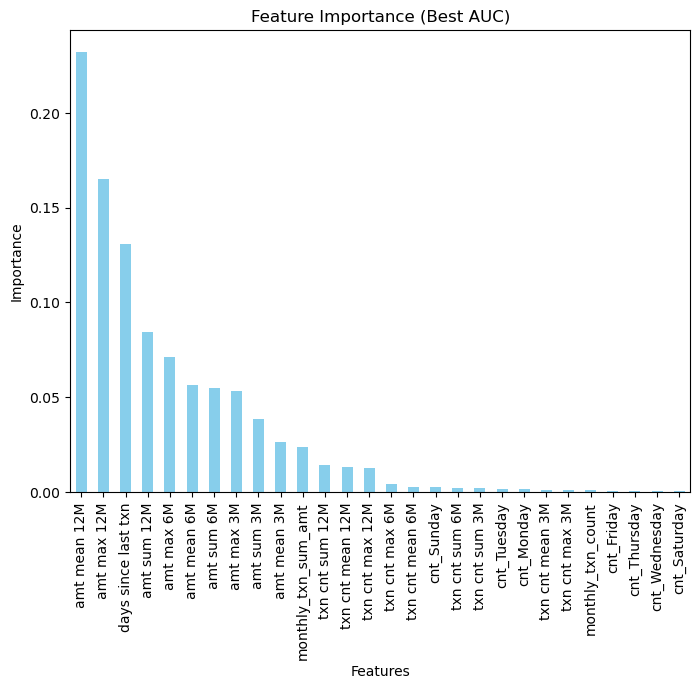

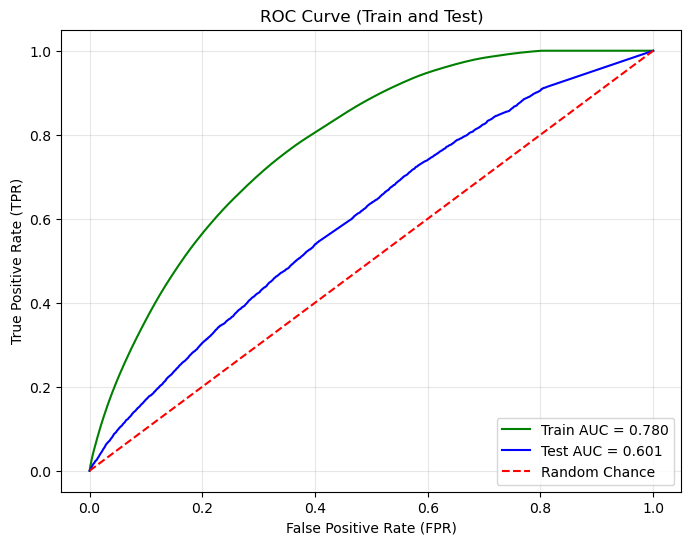

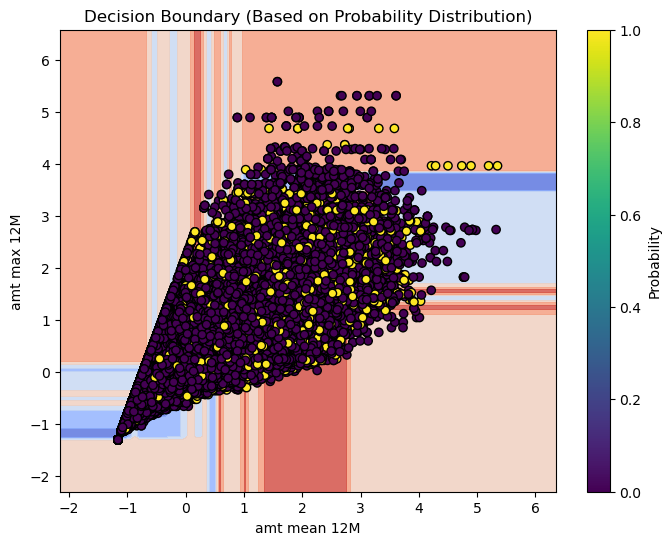

Best Model AUC:
Train AUC: 0.780, Test AUC: 0.601

Confusion Matrix:


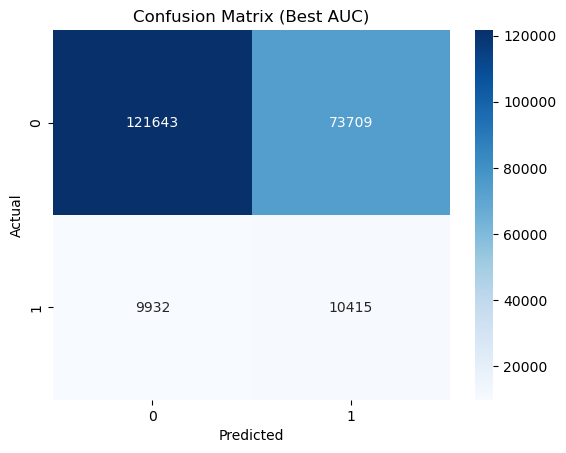


AUC and Hyperparameter Tuning Results:
min_samples_leaf=20: Train AUC=0.858, Test AUC=0.584
min_samples_leaf=30: Train AUC=0.823, Test AUC=0.594
min_samples_leaf=40: Train AUC=0.797, Test AUC=0.599
min_samples_leaf=50: Train AUC=0.780, Test AUC=0.601


{'best_model': DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=50,
                        random_state=1147),
 'best_train_auc': 0.7800716991855848,
 'best_test_auc': 0.6010426154270019,
 'feature_importance': amt mean 12M           0.232052
 amt max 12M            0.165220
 days since last txn    0.130599
 amt sum 12M            0.084663
 amt max 6M             0.071371
 amt mean 6M            0.056711
 amt sum 6M             0.054710
 amt max 3M             0.053179
 amt sum 3M             0.038745
 amt mean 3M            0.026597
 monthly_txn_sum_amt    0.024031
 txn cnt sum 12M        0.014431
 txn cnt mean 12M       0.013132
 txn cnt max 12M        0.012561
 txn cnt max 6M         0.004049
 txn cnt mean 6M        0.002782
 cnt_Sunday             0.002650
 txn cnt sum 6M         0.002291
 txn cnt sum 3M         0.002221
 cnt_Tuesday            0.001571
 cnt_Monday             0.001433
 txn cnt mean 3M        0.001030
 txn cnt max 3M         0.000982
 monthly_txn_c

In [98]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

def decision_tree_with_tuning_min_samples_leaf(X_train, Y_train, X_test, Y_test, min_samples_leaf_values):
    results = []
    best_model = None
    best_auc = 0
    
    # Iterate over provided min_samples_leaf values
    for min_samples_leaf in min_samples_leaf_values:
        model = DecisionTreeClassifier(min_samples_leaf=min_samples_leaf, class_weight="balanced", random_state=1147)
        model.fit(X_train, Y_train)
        
        # Predict probabilities
        train_probs = model.predict_proba(X_train)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]
        
        # Calculate AUC
        train_auc = roc_auc_score(Y_train, train_probs)
        test_auc = roc_auc_score(Y_test, test_probs)
        
        # Store results
        results.append({
            'min_samples_leaf': min_samples_leaf,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'model': model
        })
        
        # Update the best model
        if test_auc > best_auc:
            best_auc = test_auc
            best_model = model
    
    # Extract the best model details
    best_result = max(results, key=lambda x: x['test_auc'])
    best_model = best_result['model']
    best_train_auc = best_result['train_auc']
    best_test_auc = best_result['test_auc']
    
    # Predictions and probabilities
    Y_pred = best_model.predict(X_test)
    best_probs = best_model.predict_proba(X_test)[:, 1]
    
    # Feature Importance
    feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
    feature_importance.sort_values(ascending=False, inplace=True)
    
    # Feature Importance Plot
    plt.figure(figsize=(8, 6))
    feature_importance.plot(kind='bar', color='skyblue')
    plt.title('Feature Importance (Best AUC)')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.show()
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    
    # ROC Curve for Train and Test
    plt.figure(figsize=(8, 6))
    fpr_train, tpr_train, _ = roc_curve(Y_train, best_model.predict_proba(X_train)[:, 1])
    plt.plot(fpr_train, tpr_train, label=f"Train AUC = {best_train_auc:.3f}", color="green")
    fpr_test, tpr_test, _ = roc_curve(Y_test, best_probs)
    plt.plot(fpr_test, tpr_test, label=f"Test AUC = {best_test_auc:.3f}", color="blue")
    plt.plot([0, 1], [0, 1], 'r--', label="Random Chance")
    plt.title("ROC Curve (Train and Test)")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    # Decision Boundary Plot Based on Probability Distribution
    top_features = feature_importance.index[:2]
    if len(top_features) == 2:  # Ensure only 2 features are selected
        X_train_2d = X_train[top_features]
        X_test_2d = X_test[top_features]
        
        # Retrain the best model with top 2 features
        best_model.fit(X_train_2d, Y_train)

        fig, ax = plt.subplots(figsize=(8, 6))
        DecisionBoundaryDisplay.from_estimator(
            best_model,
            X_test_2d,
            response_method="predict_proba",
            ax=ax,
            cmap="coolwarm",
            alpha=0.8,
        )
        plt.scatter(X_test_2d.iloc[:, 0], X_test_2d.iloc[:, 1], c=Y_test, edgecolor="k", cmap="viridis")
        plt.title("Decision Boundary (Based on Probability Distribution)")
        plt.xlabel(top_features[0])
        plt.ylabel(top_features[1])
        plt.colorbar(label="Probability")
        plt.show()
    
    
    
    # Display Results
    print("Best Model AUC:")
    print(f"Train AUC: {best_train_auc:.3f}, Test AUC: {best_test_auc:.3f}")
    
    print("\nConfusion Matrix:")
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Best AUC)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("\nAUC and Hyperparameter Tuning Results:")
    for result in results:
        print(f"min_samples_leaf={result['min_samples_leaf']}: Train AUC={result['train_auc']:.3f}, Test AUC={result['test_auc']:.3f}")
    
    return {
        'best_model': best_model,
        'best_train_auc': best_train_auc,
        'best_test_auc': best_test_auc,
        'feature_importance': feature_importance,
        'confusion_matrix': conf_matrix
    }

# Example Call
# min_samples_leaf_values = [1, 2, 4, 8, 16]
# results = decision_tree_with_tuning_min_samples_leaf(X_train, Y_train, X_test, Y_test, min_samples_leaf_values)

min_samples_leaf_values = [ 20,30,40,50]
decision_tree_with_tuning_min_samples_leaf(X_train_monthly, Y_train_monthly, X_test_monthly, Y_test_monthly, min_samples_leaf_values)


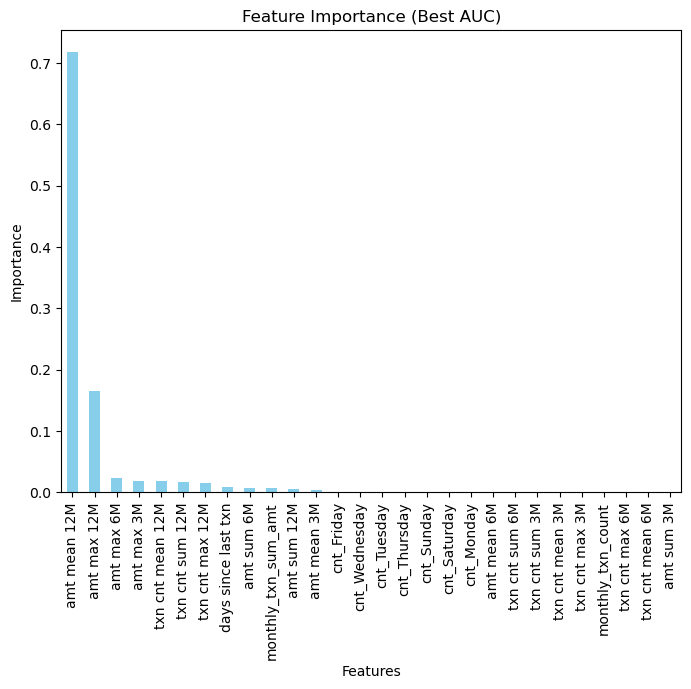

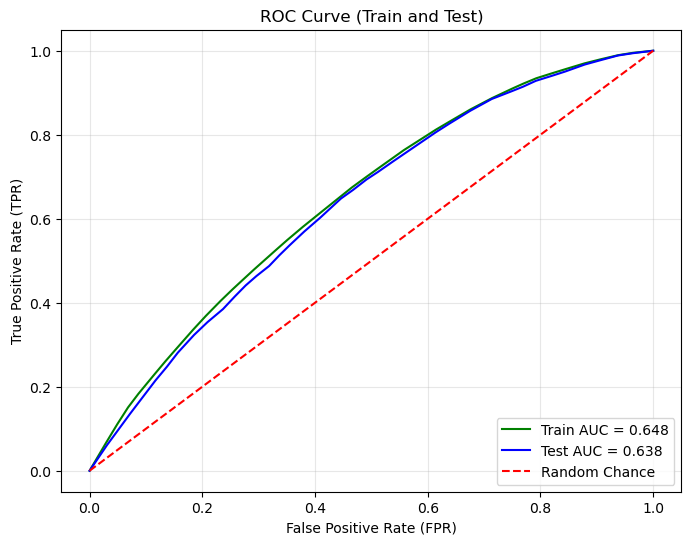

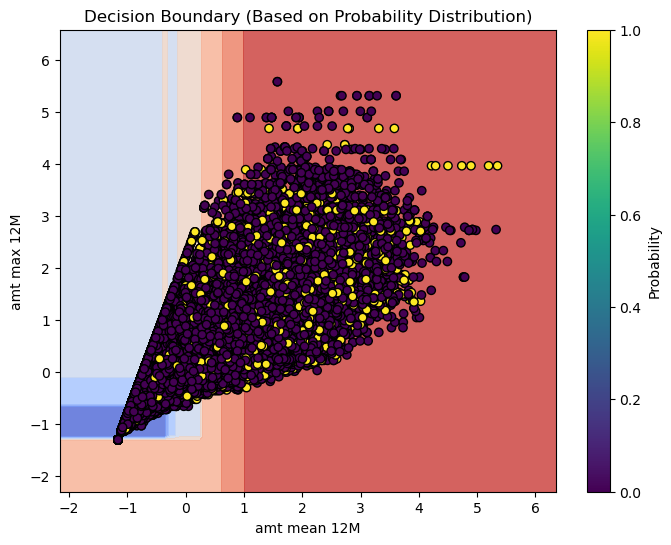

Best Model AUC:
Train AUC: 0.648, Test AUC: 0.638

Confusion Matrix:


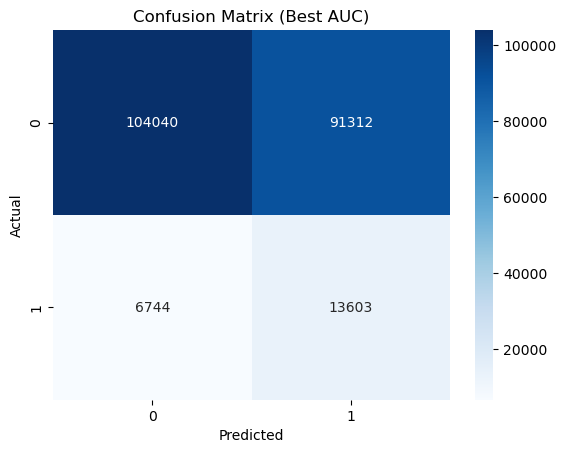


AUC and Hyperparameter Tuning Results:
min_samples_leaf=1: Train AUC=0.998, Test AUC=0.540
min_samples_leaf=5: Train AUC=0.958, Test AUC=0.561
min_samples_leaf=10: Train AUC=0.914, Test AUC=0.571
min_samples_leaf=25: Train AUC=0.838, Test AUC=0.589
min_samples_leaf=50: Train AUC=0.780, Test AUC=0.601
min_samples_leaf=100: Train AUC=0.733, Test AUC=0.612
min_samples_leaf=200: Train AUC=0.697, Test AUC=0.621
min_samples_leaf=250: Train AUC=0.687, Test AUC=0.626
min_samples_leaf=300: Train AUC=0.681, Test AUC=0.627
min_samples_leaf=500: Train AUC=0.669, Test AUC=0.633
min_samples_leaf=1000: Train AUC=0.657, Test AUC=0.636
min_samples_leaf=2000: Train AUC=0.648, Test AUC=0.638
min_samples_leaf=3000: Train AUC=0.644, Test AUC=0.637
min_samples_leaf=4000: Train AUC=0.642, Test AUC=0.636
min_samples_leaf=5000: Train AUC=0.641, Test AUC=0.635
min_samples_leaf=7000: Train AUC=0.638, Test AUC=0.634


{'best_model': DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=2000,
                        random_state=1147),
 'best_train_auc': 0.6477037775203984,
 'best_test_auc': 0.6376513539276565,
 'feature_importance': amt mean 12M           0.717946
 amt max 12M            0.164726
 amt max 6M             0.022466
 amt max 3M             0.018321
 txn cnt mean 12M       0.017829
 txn cnt sum 12M        0.016293
 txn cnt max 12M        0.014047
 days since last txn    0.008204
 amt sum 6M             0.006532
 monthly_txn_sum_amt    0.006210
 amt sum 12M            0.004400
 amt mean 3M            0.003025
 cnt_Friday             0.000000
 cnt_Wednesday          0.000000
 cnt_Tuesday            0.000000
 cnt_Thursday           0.000000
 cnt_Sunday             0.000000
 cnt_Saturday           0.000000
 cnt_Monday             0.000000
 amt mean 6M            0.000000
 txn cnt sum 6M         0.000000
 txn cnt sum 3M         0.000000
 txn cnt mean 3M        0.000000
 txn cnt max

In [99]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

def decision_tree_with_tuning_min_samples_leaf(X_train, Y_train, X_test, Y_test, min_samples_leaf_values):
    results = []
    best_model = None
    best_auc = 0
    
    # Iterate over provided min_samples_leaf values
    for min_samples_leaf in min_samples_leaf_values:
        model = DecisionTreeClassifier(min_samples_leaf=min_samples_leaf, class_weight="balanced", random_state=1147)
        model.fit(X_train, Y_train)
        
        # Predict probabilities
        train_probs = model.predict_proba(X_train)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]
        
        # Calculate AUC
        train_auc = roc_auc_score(Y_train, train_probs)
        test_auc = roc_auc_score(Y_test, test_probs)
        
        # Store results
        results.append({
            'min_samples_leaf': min_samples_leaf,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'model': model
        })
        
        # Update the best model
        if test_auc > best_auc:
            best_auc = test_auc
            best_model = model
    
    # Extract the best model details
    best_result = max(results, key=lambda x: x['test_auc'])
    best_model = best_result['model']
    best_train_auc = best_result['train_auc']
    best_test_auc = best_result['test_auc']
    
    # Predictions and probabilities
    Y_pred = best_model.predict(X_test)
    best_probs = best_model.predict_proba(X_test)[:, 1]
    
    # Feature Importance
    feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
    feature_importance.sort_values(ascending=False, inplace=True)
    
    # Feature Importance Plot
    plt.figure(figsize=(8, 6))
    feature_importance.plot(kind='bar', color='skyblue')
    plt.title('Feature Importance (Best AUC)')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.show()
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    
    # ROC Curve for Train and Test
    plt.figure(figsize=(8, 6))
    fpr_train, tpr_train, _ = roc_curve(Y_train, best_model.predict_proba(X_train)[:, 1])
    plt.plot(fpr_train, tpr_train, label=f"Train AUC = {best_train_auc:.3f}", color="green")
    fpr_test, tpr_test, _ = roc_curve(Y_test, best_probs)
    plt.plot(fpr_test, tpr_test, label=f"Test AUC = {best_test_auc:.3f}", color="blue")
    plt.plot([0, 1], [0, 1], 'r--', label="Random Chance")
    plt.title("ROC Curve (Train and Test)")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    # Decision Boundary Plot Based on Probability Distribution
    top_features = feature_importance.index[:2]
    if len(top_features) == 2:  # Ensure only 2 features are selected
        X_train_2d = X_train[top_features]
        X_test_2d = X_test[top_features]
        
        # Retrain the best model with top 2 features
        best_model.fit(X_train_2d, Y_train)

        fig, ax = plt.subplots(figsize=(8, 6))
        DecisionBoundaryDisplay.from_estimator(
            best_model,
            X_test_2d,
            response_method="predict_proba",
            ax=ax,
            cmap="coolwarm",
            alpha=0.8,
        )
        plt.scatter(X_test_2d.iloc[:, 0], X_test_2d.iloc[:, 1], c=Y_test, edgecolor="k", cmap="viridis")
        plt.title("Decision Boundary (Based on Probability Distribution)")
        plt.xlabel(top_features[0])
        plt.ylabel(top_features[1])
        plt.colorbar(label="Probability")
        plt.show()
    
    
    
    # Display Results
    print("Best Model AUC:")
    print(f"Train AUC: {best_train_auc:.3f}, Test AUC: {best_test_auc:.3f}")
    
    print("\nConfusion Matrix:")
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Best AUC)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("\nAUC and Hyperparameter Tuning Results:")
    for result in results:
        print(f"min_samples_leaf={result['min_samples_leaf']}: Train AUC={result['train_auc']:.3f}, Test AUC={result['test_auc']:.3f}")
    
    return {
        'best_model': best_model,
        'best_train_auc': best_train_auc,
        'best_test_auc': best_test_auc,
        'feature_importance': feature_importance,
        'confusion_matrix': conf_matrix
    }

# Example Call
# min_samples_leaf_values = [1, 2, 4, 8, 16]
# results = decision_tree_with_tuning_min_samples_leaf(X_train, Y_train, X_test, Y_test, min_samples_leaf_values)

min_samples_leaf_values = [1,5,10,25,50,100,200,250,300,500,1000,2000,3000,4000,5000,7000]
decision_tree_with_tuning_min_samples_leaf(X_train_monthly, Y_train_monthly, X_test_monthly, Y_test_monthly, min_samples_leaf_values)


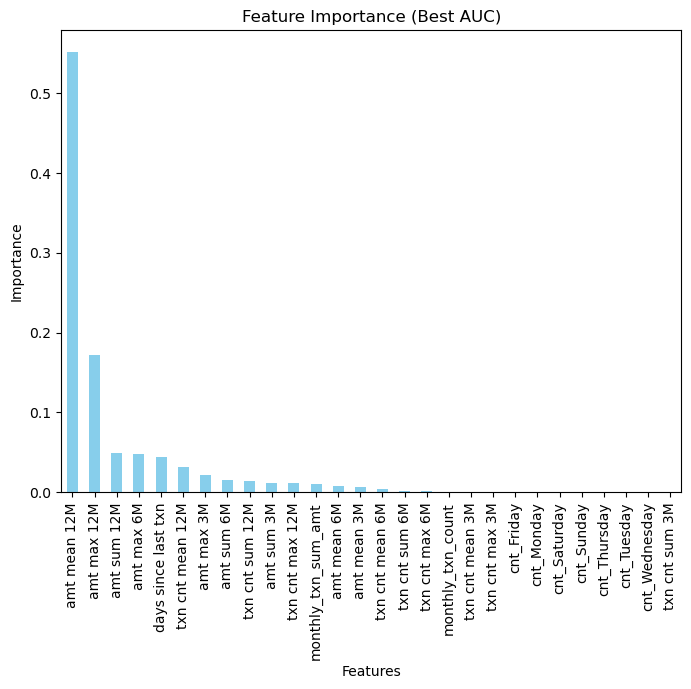

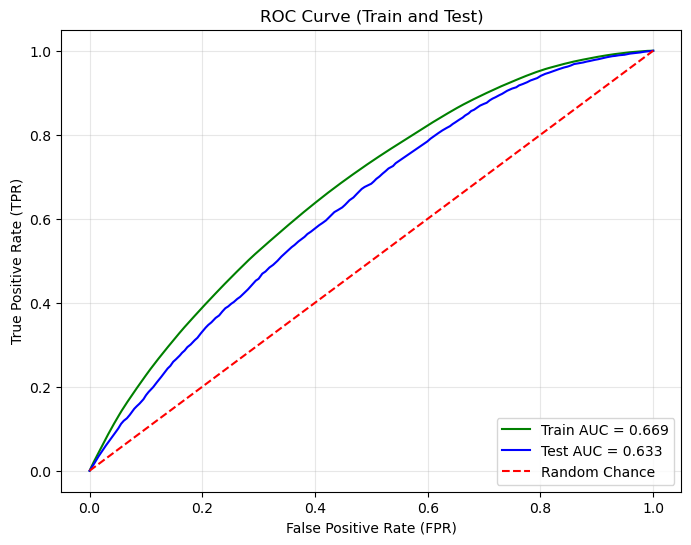

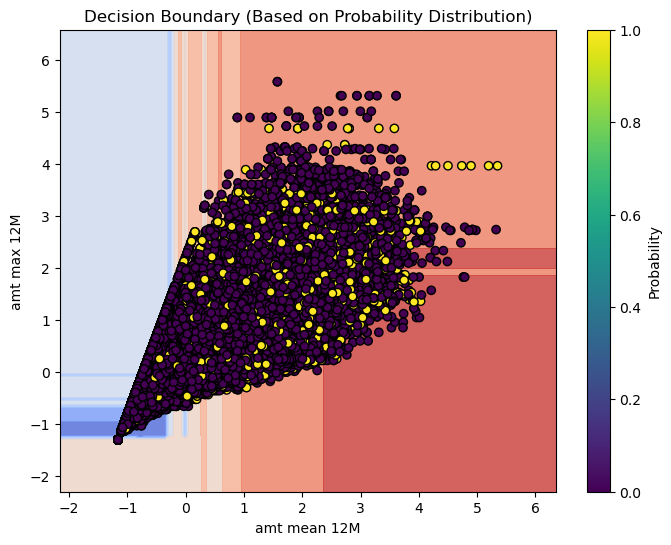

Best Model AUC and Metrics:
Train AUC: 0.669, Test AUC: 0.633
Train Precision: 0.136, Test Precision: 0.127
Train Recall: 0.685, Test Recall: 0.633

Confusion Matrix:


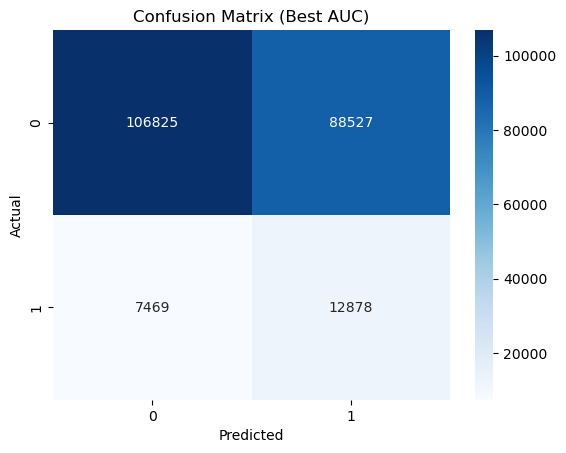


AUC, Precision, and Recall Tuning Results:
min_samples_leaf=1: Train AUC=0.998, Test AUC=0.540, Train Precision=0.921, Test Precision=0.163, Train Recall=0.950, Test Recall=0.169
min_samples_leaf=5: Train AUC=0.958, Test AUC=0.561, Train Precision=0.389, Test Precision=0.135, Train Recall=0.950, Test Recall=0.331
min_samples_leaf=10: Train AUC=0.914, Test AUC=0.571, Train Precision=0.289, Test Precision=0.127, Train Recall=0.898, Test Recall=0.392
min_samples_leaf=25: Train AUC=0.838, Test AUC=0.589, Train Precision=0.218, Test Precision=0.126, Train Recall=0.815, Test Recall=0.467
min_samples_leaf=50: Train AUC=0.780, Test AUC=0.601, Train Precision=0.182, Test Precision=0.124, Train Recall=0.762, Test Recall=0.512
min_samples_leaf=100: Train AUC=0.733, Test AUC=0.612, Train Precision=0.162, Test Precision=0.125, Train Recall=0.716, Test Recall=0.547
min_samples_leaf=200: Train AUC=0.697, Test AUC=0.621, Train Precision=0.148, Test Precision=0.126, Train Recall=0.691, Test Recall=0.5

{'best_model': DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=500,
                        random_state=1147),
 'best_train_auc': 0.6692657445870231,
 'best_test_auc': 0.6329081440176458,
 'best_train_precision': 0.13649781088416507,
 'best_test_precision': 0.1269957102706967,
 'best_train_recall': 0.6847545219638242,
 'best_test_recall': 0.6329188578168772,
 'feature_importance': amt mean 12M           0.551475
 amt max 12M            0.172190
 amt sum 12M            0.048783
 amt max 6M             0.048137
 days since last txn    0.043589
 txn cnt mean 12M       0.031350
 amt max 3M             0.021688
 amt sum 6M             0.014953
 txn cnt sum 12M        0.014126
 amt sum 3M             0.011328
 txn cnt max 12M        0.011236
 monthly_txn_sum_amt    0.010068
 amt mean 6M            0.007120
 amt mean 3M            0.006773
 txn cnt mean 6M        0.004025
 txn cnt sum 6M         0.001836
 txn cnt max 6M         0.001322
 monthly_txn_count      0.000000
 txn 

In [100]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.inspection import DecisionBoundaryDisplay

def decision_tree_with_tuning_min_samples_leaf(X_train, Y_train, X_test, Y_test, min_samples_leaf_values):
    results = []
    best_model = None
    best_auc = 0
    
    # Iterate over provided min_samples_leaf values
    for min_samples_leaf in min_samples_leaf_values:
        model = DecisionTreeClassifier(min_samples_leaf=min_samples_leaf, class_weight="balanced", random_state=1147)
        model.fit(X_train, Y_train)
        
        # Predict probabilities
        train_probs = model.predict_proba(X_train)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]
        
        # Calculate AUC
        train_auc = roc_auc_score(Y_train, train_probs)
        test_auc = roc_auc_score(Y_test, test_probs)
        
        # Calculate Precision and Recall
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        train_precision = precision_score(Y_train, train_pred)
        test_precision = precision_score(Y_test, test_pred)
        
        train_recall = recall_score(Y_train, train_pred)
        test_recall = recall_score(Y_test, test_pred)
        
        # Store results
        results.append({
            'min_samples_leaf': min_samples_leaf,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'train_precision': train_precision,
            'test_precision': test_precision,
            'train_recall': train_recall,
            'test_recall': test_recall,
            'model': model
        })
        
        # Update the best model
        if test_auc > best_auc:
            best_auc = test_auc
            best_model = model
    
    # Extract the best model details
    best_result = max(results, key=lambda x: x['test_auc'])
    best_model = best_result['model']
    best_train_auc = best_result['train_auc']
    best_test_auc = best_result['test_auc']
    best_train_precision = best_result['train_precision']
    best_test_precision = best_result['test_precision']
    best_train_recall = best_result['train_recall']
    best_test_recall = best_result['test_recall']
    
    # Predictions and probabilities
    Y_pred = best_model.predict(X_test)
    best_probs = best_model.predict_proba(X_test)[:, 1]
    
    # Feature Importance
    feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
    feature_importance.sort_values(ascending=False, inplace=True)
    
    # Feature Importance Plot
    plt.figure(figsize=(8, 6))
    feature_importance.plot(kind='bar', color='skyblue')
    plt.title('Feature Importance (Best AUC)')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.show()
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    
    # ROC Curve for Train and Test
    plt.figure(figsize=(8, 6))
    fpr_train, tpr_train, _ = roc_curve(Y_train, best_model.predict_proba(X_train)[:, 1])
    plt.plot(fpr_train, tpr_train, label=f"Train AUC = {best_train_auc:.3f}", color="green")
    fpr_test, tpr_test, _ = roc_curve(Y_test, best_probs)
    plt.plot(fpr_test, tpr_test, label=f"Test AUC = {best_test_auc:.3f}", color="blue")
    plt.plot([0, 1], [0, 1], 'r--', label="Random Chance")
    plt.title("ROC Curve (Train and Test)")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    # Decision Boundary Plot Based on Probability Distribution
    top_features = feature_importance.index[:2]
    if len(top_features) == 2:  # Ensure only 2 features are selected
        X_train_2d = X_train[top_features]
        X_test_2d = X_test[top_features]
        
        # Retrain the best model with top 2 features
        best_model.fit(X_train_2d, Y_train)

        fig, ax = plt.subplots(figsize=(8, 6))
        DecisionBoundaryDisplay.from_estimator(
            best_model,
            X_test_2d,
            response_method="predict_proba",
            ax=ax,
            cmap="coolwarm",
            alpha=0.8,
        )
        plt.scatter(X_test_2d.iloc[:, 0], X_test_2d.iloc[:, 1], c=Y_test, edgecolor="k", cmap="viridis")
        plt.title("Decision Boundary (Based on Probability Distribution)")
        plt.xlabel(top_features[0])
        plt.ylabel(top_features[1])
        plt.colorbar(label="Probability")
        plt.show()
    
    # Display Results
    print("Best Model AUC and Metrics:")
    print(f"Train AUC: {best_train_auc:.3f}, Test AUC: {best_test_auc:.3f}")
    print(f"Train Precision: {best_train_precision:.3f}, Test Precision: {best_test_precision:.3f}")
    print(f"Train Recall: {best_train_recall:.3f}, Test Recall: {best_test_recall:.3f}")
    
    print("\nConfusion Matrix:")
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Best AUC)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("\nAUC, Precision, and Recall Tuning Results:")
    for result in results:
        print(f"min_samples_leaf={result['min_samples_leaf']}: Train AUC={result['train_auc']:.3f}, Test AUC={result['test_auc']:.3f}, "
              f"Train Precision={result['train_precision']:.3f}, Test Precision={result['test_precision']:.3f}, "
              f"Train Recall={result['train_recall']:.3f}, Test Recall={result['test_recall']:.3f}")
    
    return {
        'best_model': best_model,
        'best_train_auc': best_train_auc,
        'best_test_auc': best_test_auc,
        'best_train_precision': best_train_precision,
        'best_test_precision': best_test_precision,
        'best_train_recall': best_train_recall,
        'best_test_recall': best_test_recall,
        'feature_importance': feature_importance,
        'confusion_matrix': conf_matrix
    }

# Example Call
# min_samples_leaf_values = [1, 2, 4, 8, 16]
# results = decision_tree_with_tuning_min_samples_leaf(X_train, Y_train, X_test, Y_test, min_samples_leaf_values)

min_samples_leaf_values = [1, 5, 10, 25, 50, 100, 200, 250, 300, 500]
decision_tree_with_tuning_min_samples_leaf(X_train_monthly, Y_train_monthly, X_test_monthly, Y_test_monthly, min_samples_leaf_values)


## Decision tree annual 

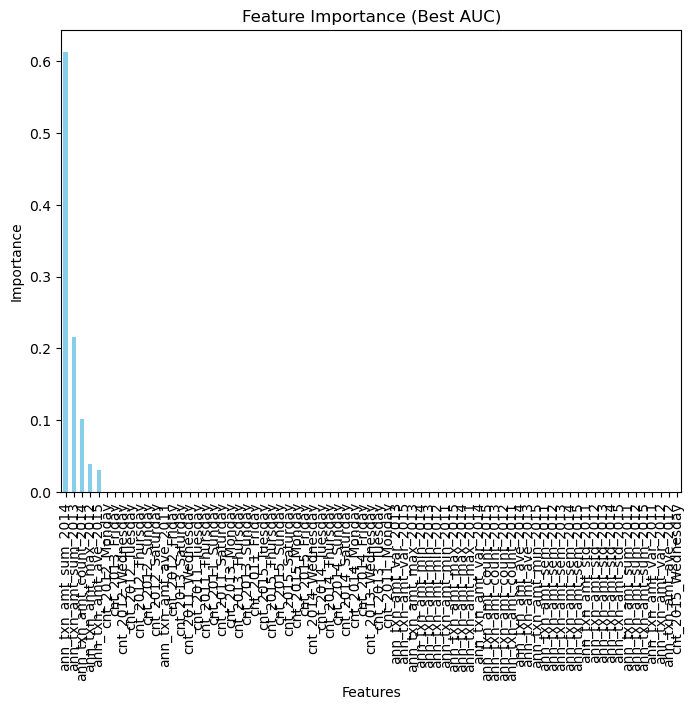

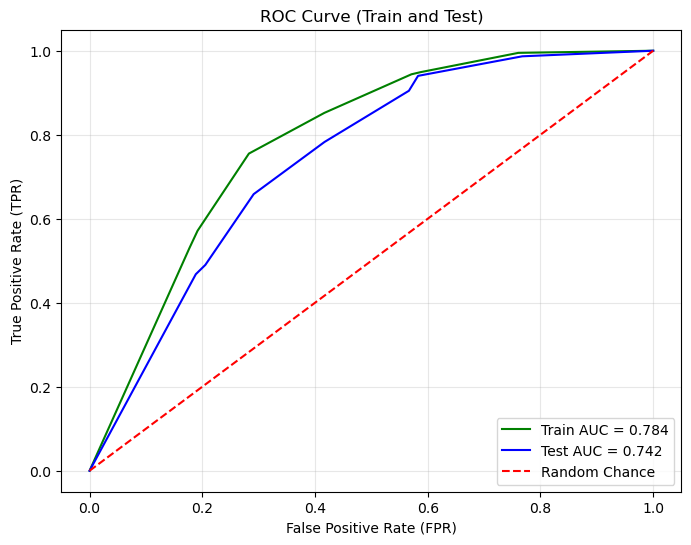

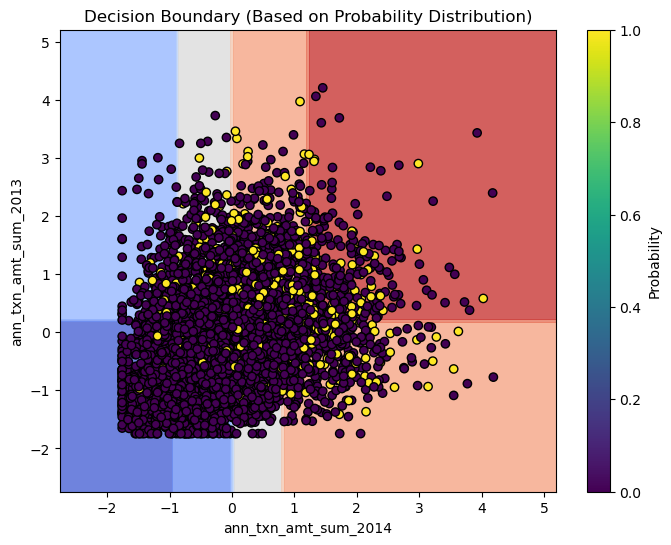

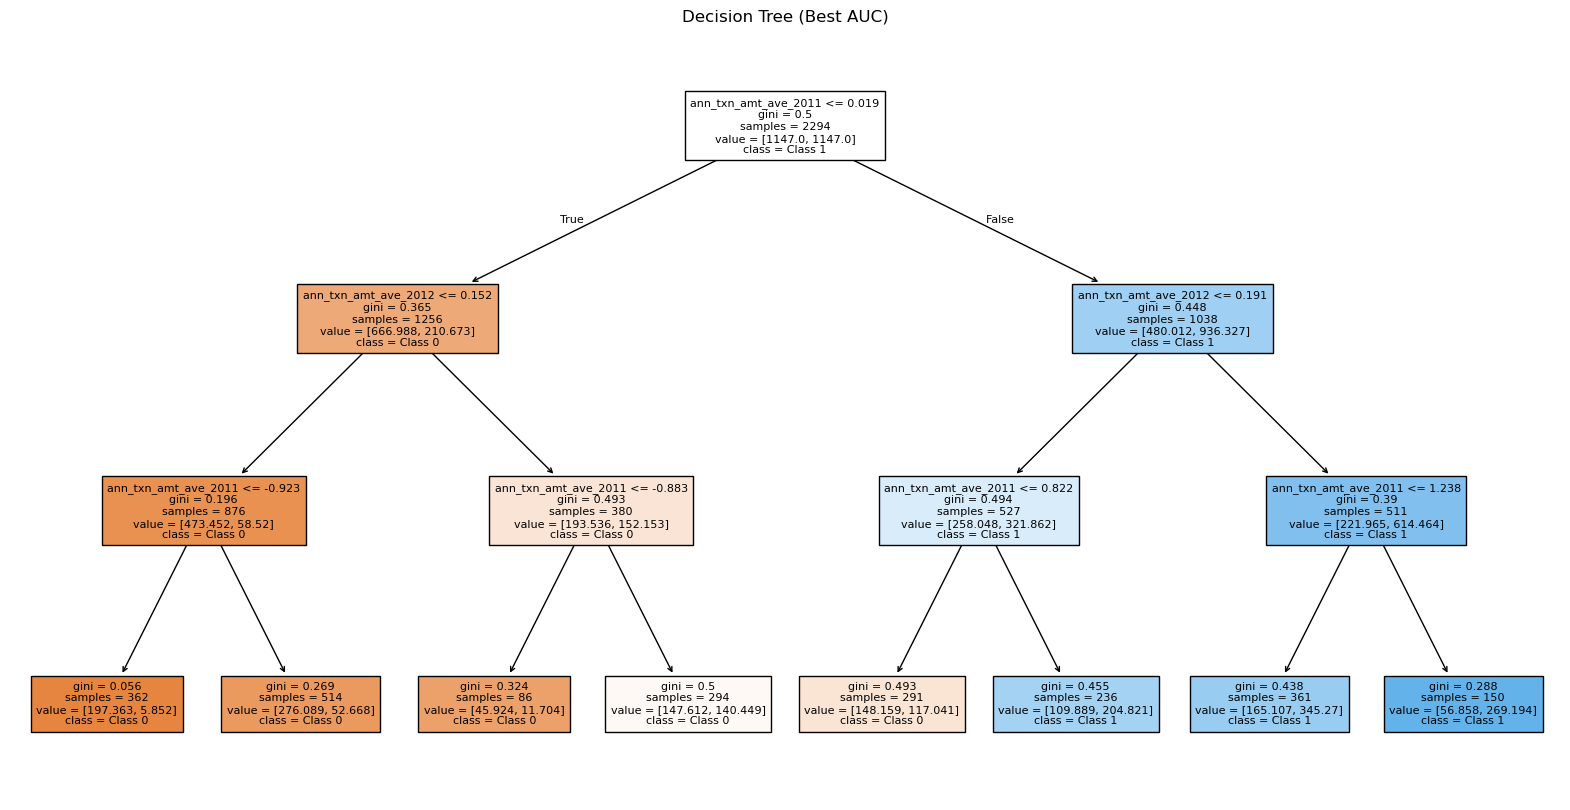

Best Model AUC:
Train AUC: 0.784, Test AUC: 0.742

Confusion Matrix:


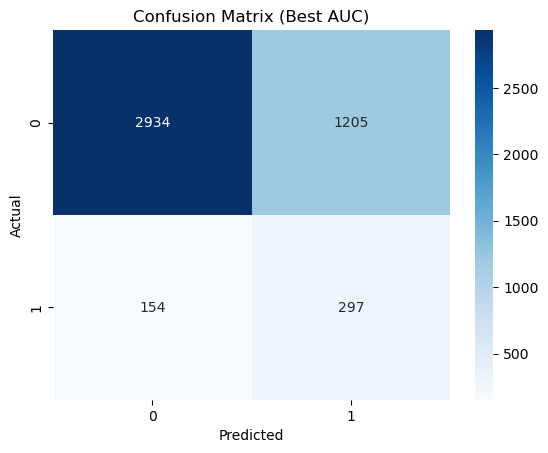


AUC and Hyperparameter Tuning Results:
Max Depth=1: Train AUC=0.699, Test AUC=0.690
Max Depth=2: Train AUC=0.755, Test AUC=0.738
Max Depth=3: Train AUC=0.784, Test AUC=0.742
Max Depth=4: Train AUC=0.818, Test AUC=0.702
Max Depth=5: Train AUC=0.852, Test AUC=0.690
Max Depth=6: Train AUC=0.884, Test AUC=0.670
Max Depth=7: Train AUC=0.917, Test AUC=0.648
Max Depth=8: Train AUC=0.940, Test AUC=0.628
Max Depth=9: Train AUC=0.953, Test AUC=0.632
Max Depth=10: Train AUC=0.961, Test AUC=0.624
Max Depth=15: Train AUC=0.986, Test AUC=0.571


{'best_model': DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=1147),
 'best_train_auc': 0.7842393630474116,
 'best_test_auc': 0.7422262090792843,
 'feature_importance': ann_txn_amt_sum_2014      0.612999
 ann_txn_amt_sum_2013      0.216220
 ann_txn_amt_count_2014    0.101356
 ann_txn_amt_max_2012      0.039392
 ann_txn_amt_ave_2015      0.030034
                             ...   
 ann_txn_amt_sum_2015      0.000000
 ann_txn_amt_var_2011      0.000000
 ann_txn_amt_var_2012      0.000000
 ann_txn_amt_ave_2012      0.000000
 cnt_2015_Wednesday        0.000000
 Length: 75, dtype: float64,
 'confusion_matrix': array([[2934, 1205],
        [ 154,  297]], dtype=int64)}

In [101]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

def decision_tree_with_tuning(X_train, Y_train, X_test, Y_test, max_depth_values):
    results = []
    best_model = None
    best_auc = 0
    
    # Iterate over provided max_depth values
    for depth in max_depth_values:
        model = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=1147)
        model.fit(X_train, Y_train)
        
        # Predict probabilities
        train_probs = model.predict_proba(X_train)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]
        
        # Calculate AUC
        train_auc = roc_auc_score(Y_train, train_probs)
        test_auc = roc_auc_score(Y_test, test_probs)
        
        # Store results
        results.append({
            'max_depth': depth,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'model': model
        })
        
        # Update the best model
        if test_auc > best_auc:
            best_auc = test_auc
            best_model = model
    
    # Extract the best model details
    best_result = max(results, key=lambda x: x['test_auc'])
    best_model = best_result['model']
    best_train_auc = best_result['train_auc']
    best_test_auc = best_result['test_auc']
    
    # Predictions and probabilities
    Y_pred = best_model.predict(X_test)
    best_probs = best_model.predict_proba(X_test)[:, 1]
    
    # Feature Importance
    feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
    feature_importance.sort_values(ascending=False, inplace=True)
    
    # Feature Importance Plot
    plt.figure(figsize=(8, 6))
    feature_importance.plot(kind='bar', color='skyblue')
    plt.title('Feature Importance (Best AUC)')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.show()
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    
    # ROC Curve for Train and Test
    plt.figure(figsize=(8, 6))
    fpr_train, tpr_train, _ = roc_curve(Y_train, best_model.predict_proba(X_train)[:, 1])
    plt.plot(fpr_train, tpr_train, label=f"Train AUC = {best_train_auc:.3f}", color="green")
    fpr_test, tpr_test, _ = roc_curve(Y_test, best_probs)
    plt.plot(fpr_test, tpr_test, label=f"Test AUC = {best_test_auc:.3f}", color="blue")
    plt.plot([0, 1], [0, 1], 'r--', label="Random Chance")
    plt.title("ROC Curve (Train and Test)")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    # Decision Boundary Plot Based on Probability Distribution
    top_features = feature_importance.index[:2]
    if len(top_features) == 2:  # Ensure only 2 features are selected
        X_train_2d = X_train[top_features]
        X_test_2d = X_test[top_features]
        
        # Retrain the best model with top 2 features
        best_model.fit(X_train_2d, Y_train)

        fig, ax = plt.subplots(figsize=(8, 6))
        DecisionBoundaryDisplay.from_estimator(
            best_model,
            X_test_2d,
            response_method="predict_proba",
            ax=ax,
            cmap="coolwarm",
            alpha=0.8,
        )
        plt.scatter(X_test_2d.iloc[:, 0], X_test_2d.iloc[:, 1], c=Y_test, edgecolor="k", cmap="viridis")
        plt.title("Decision Boundary (Based on Probability Distribution)")
        plt.xlabel(top_features[0])
        plt.ylabel(top_features[1])
        plt.colorbar(label="Probability")
        plt.show()
    
    # Tree Plot
    plt.figure(figsize=(20, 10))
    plot_tree(best_model, feature_names=X_train.columns, class_names=["Class 0", "Class 1"], filled=True, fontsize=8)
    plt.title("Decision Tree (Best AUC)")
    plt.show()
    
    # Display Results
    print("Best Model AUC:")
    print(f"Train AUC: {best_train_auc:.3f}, Test AUC: {best_test_auc:.3f}")
    
    print("\nConfusion Matrix:")
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Best AUC)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("\nAUC and Hyperparameter Tuning Results:")
    for result in results:
        print(f"Max Depth={result['max_depth']}: Train AUC={result['train_auc']:.3f}, Test AUC={result['test_auc']:.3f}")
    
    return {
        'best_model': best_model,
        'best_train_auc': best_train_auc,
        'best_test_auc': best_test_auc,
        'feature_importance': feature_importance,
        'confusion_matrix': conf_matrix
    }

# Example Call
# max_depth_values = [2, 4, 6, 8, 10]
# results = decision_tree_with_tuning(X_train, Y_train, X_test, Y_test, max_depth_values)

max_depth_values = [1,2,3,4,5,6,7,8,9,10,15]
decision_tree_with_tuning(X_train_annual, Y_train_annual, X_test_annual, Y_test_annual, max_depth_values)


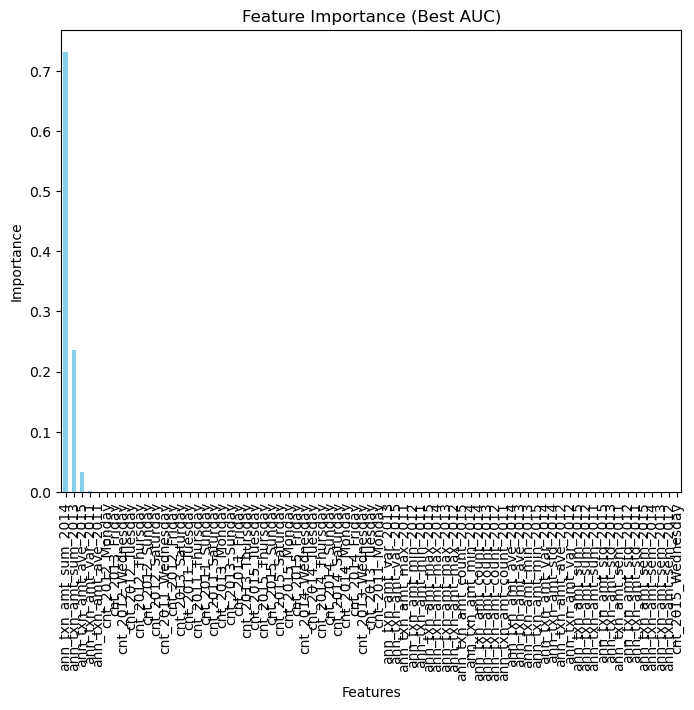

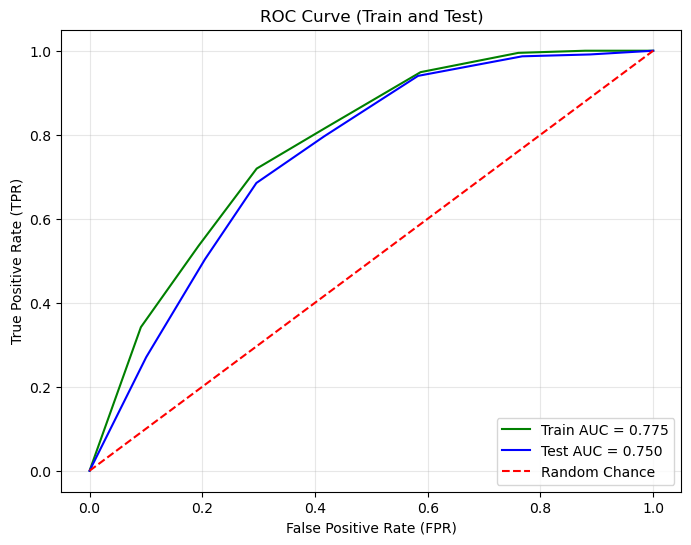

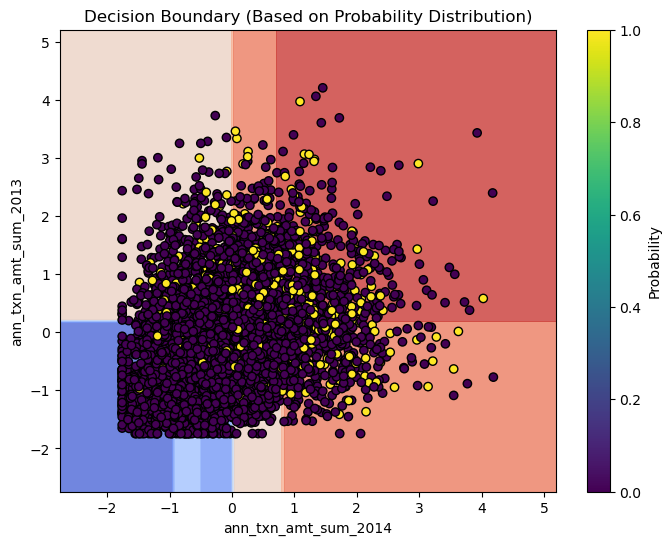

Best Model AUC and Metrics:
Train AUC: 0.775, Test AUC: 0.750
Train Precision: 0.185, Test Precision: 0.201
Train Recall: 0.719, Test Recall: 0.685

Confusion Matrix:


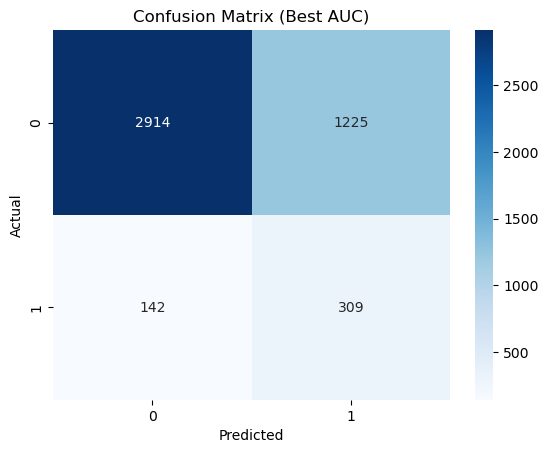


AUC, Precision, and Recall Tuning Results:
min_samples_leaf=1: Train AUC=1.000, Test AUC=0.541, Train Precision=1.000, Test Precision=0.172, Train Recall=1.000, Test Recall=0.171
min_samples_leaf=5: Train AUC=0.988, Test AUC=0.567, Train Precision=0.516, Test Precision=0.167, Train Recall=1.000, Test Recall=0.295
min_samples_leaf=10: Train AUC=0.964, Test AUC=0.607, Train Precision=0.363, Test Precision=0.159, Train Recall=0.969, Test Recall=0.399
min_samples_leaf=25: Train AUC=0.911, Test AUC=0.663, Train Precision=0.299, Test Precision=0.177, Train Recall=0.878, Test Recall=0.470
min_samples_leaf=50: Train AUC=0.857, Test AUC=0.676, Train Precision=0.222, Test Precision=0.156, Train Recall=0.842, Test Recall=0.534
min_samples_leaf=100: Train AUC=0.809, Test AUC=0.732, Train Precision=0.167, Test Precision=0.170, Train Recall=0.852, Test Recall=0.749
min_samples_leaf=200: Train AUC=0.780, Test AUC=0.743, Train Precision=0.191, Test Precision=0.201, Train Recall=0.719, Test Recall=0.6

{'best_model': DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=250,
                        random_state=1147),
 'best_train_auc': 0.7753642925234918,
 'best_test_auc': 0.7504511999588577,
 'best_train_precision': 0.18479685452162517,
 'best_test_precision': 0.2014341590612777,
 'best_train_recall': 0.7193877551020408,
 'best_test_recall': 0.6851441241685144,
 'feature_importance': ann_txn_amt_sum_2014    0.731302
 ann_txn_amt_sum_2013    0.235202
 ann_txn_amt_ave_2015    0.032670
 ann_txn_amt_var_2011    0.000826
 ann_txn_amt_ave_2011    0.000000
                           ...   
 ann_txn_amt_sem_2015    0.000000
 ann_txn_amt_sem_2014    0.000000
 ann_txn_amt_sem_2013    0.000000
 ann_txn_amt_sem_2012    0.000000
 cnt_2015_Wednesday      0.000000
 Length: 75, dtype: float64,
 'confusion_matrix': array([[2914, 1225],
        [ 142,  309]], dtype=int64)}

In [102]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.inspection import DecisionBoundaryDisplay

def decision_tree_with_tuning_min_samples_leaf(X_train, Y_train, X_test, Y_test, min_samples_leaf_values):
    results = []
    best_model = None
    best_auc = 0
    
    # Iterate over provided min_samples_leaf values
    for min_samples_leaf in min_samples_leaf_values:
        model = DecisionTreeClassifier(min_samples_leaf=min_samples_leaf, class_weight="balanced", random_state=1147)
        model.fit(X_train, Y_train)
        
        # Predict probabilities
        train_probs = model.predict_proba(X_train)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]
        
        # Calculate AUC
        train_auc = roc_auc_score(Y_train, train_probs)
        test_auc = roc_auc_score(Y_test, test_probs)
        
        # Calculate Precision and Recall
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        train_precision = precision_score(Y_train, train_pred)
        test_precision = precision_score(Y_test, test_pred)
        
        train_recall = recall_score(Y_train, train_pred)
        test_recall = recall_score(Y_test, test_pred)
        
        # Store results
        results.append({
            'min_samples_leaf': min_samples_leaf,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'train_precision': train_precision,
            'test_precision': test_precision,
            'train_recall': train_recall,
            'test_recall': test_recall,
            'model': model
        })
        
        # Update the best model
        if test_auc > best_auc:
            best_auc = test_auc
            best_model = model
    
    # Extract the best model details
    best_result = max(results, key=lambda x: x['test_auc'])
    best_model = best_result['model']
    best_train_auc = best_result['train_auc']
    best_test_auc = best_result['test_auc']
    best_train_precision = best_result['train_precision']
    best_test_precision = best_result['test_precision']
    best_train_recall = best_result['train_recall']
    best_test_recall = best_result['test_recall']
    
    # Predictions and probabilities
    Y_pred = best_model.predict(X_test)
    best_probs = best_model.predict_proba(X_test)[:, 1]
    
    # Feature Importance
    feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
    feature_importance.sort_values(ascending=False, inplace=True)
    
    # Feature Importance Plot
    plt.figure(figsize=(8, 6))
    feature_importance.plot(kind='bar', color='skyblue')
    plt.title('Feature Importance (Best AUC)')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.show()
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    
    # ROC Curve for Train and Test
    plt.figure(figsize=(8, 6))
    fpr_train, tpr_train, _ = roc_curve(Y_train, best_model.predict_proba(X_train)[:, 1])
    plt.plot(fpr_train, tpr_train, label=f"Train AUC = {best_train_auc:.3f}", color="green")
    fpr_test, tpr_test, _ = roc_curve(Y_test, best_probs)
    plt.plot(fpr_test, tpr_test, label=f"Test AUC = {best_test_auc:.3f}", color="blue")
    plt.plot([0, 1], [0, 1], 'r--', label="Random Chance")
    plt.title("ROC Curve (Train and Test)")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    # Decision Boundary Plot Based on Probability Distribution
    top_features = feature_importance.index[:2]
    if len(top_features) == 2:  # Ensure only 2 features are selected
        X_train_2d = X_train[top_features]
        X_test_2d = X_test[top_features]
        
        # Retrain the best model with top 2 features
        best_model.fit(X_train_2d, Y_train)

        fig, ax = plt.subplots(figsize=(8, 6))
        DecisionBoundaryDisplay.from_estimator(
            best_model,
            X_test_2d,
            response_method="predict_proba",
            ax=ax,
            cmap="coolwarm",
            alpha=0.8,
        )
        plt.scatter(X_test_2d.iloc[:, 0], X_test_2d.iloc[:, 1], c=Y_test, edgecolor="k", cmap="viridis")
        plt.title("Decision Boundary (Based on Probability Distribution)")
        plt.xlabel(top_features[0])
        plt.ylabel(top_features[1])
        plt.colorbar(label="Probability")
        plt.show()
    
    # Display Results
    print("Best Model AUC and Metrics:")
    print(f"Train AUC: {best_train_auc:.3f}, Test AUC: {best_test_auc:.3f}")
    print(f"Train Precision: {best_train_precision:.3f}, Test Precision: {best_test_precision:.3f}")
    print(f"Train Recall: {best_train_recall:.3f}, Test Recall: {best_test_recall:.3f}")
    
    print("\nConfusion Matrix:")
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Best AUC)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("\nAUC, Precision, and Recall Tuning Results:")
    for result in results:
        print(f"min_samples_leaf={result['min_samples_leaf']}: Train AUC={result['train_auc']:.3f}, Test AUC={result['test_auc']:.3f}, "
              f"Train Precision={result['train_precision']:.3f}, Test Precision={result['test_precision']:.3f}, "
              f"Train Recall={result['train_recall']:.3f}, Test Recall={result['test_recall']:.3f}")
    
    return {
        'best_model': best_model,
        'best_train_auc': best_train_auc,
        'best_test_auc': best_test_auc,
        'best_train_precision': best_train_precision,
        'best_test_precision': best_test_precision,
        'best_train_recall': best_train_recall,
        'best_test_recall': best_test_recall,
        'feature_importance': feature_importance,
        'confusion_matrix': conf_matrix
    }

# Example Call
# min_samples_leaf_values = [1, 2, 4, 8, 16]
# results = decision_tree_with_tuning_min_samples_leaf(X_train, Y_train, X_test, Y_test, min_samples_leaf_values)

min_samples_leaf_values = [1, 5, 10, 25, 50, 100, 200, 250, 300, 500]
decision_tree_with_tuning_min_samples_leaf(X_train_annual, Y_train_annual, X_test_annual, Y_test_annual, min_samples_leaf_values)


## Random forest 

### Random forest monthly 

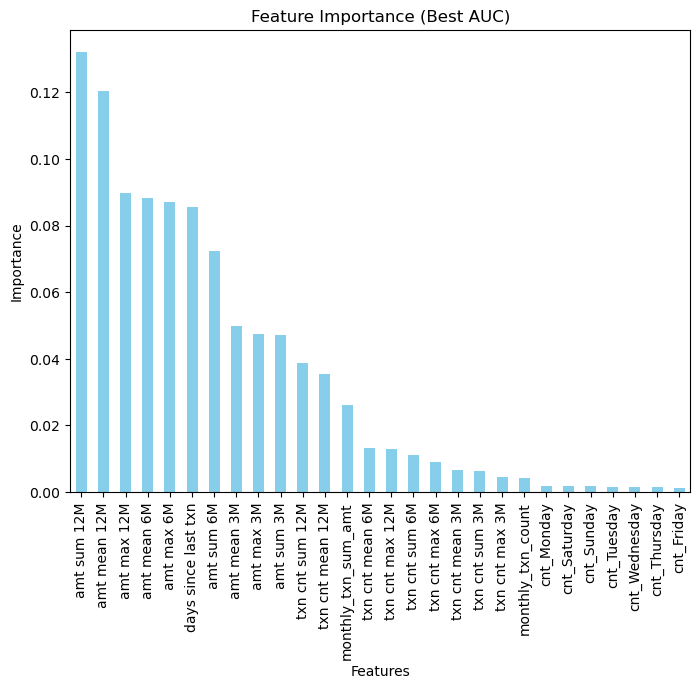

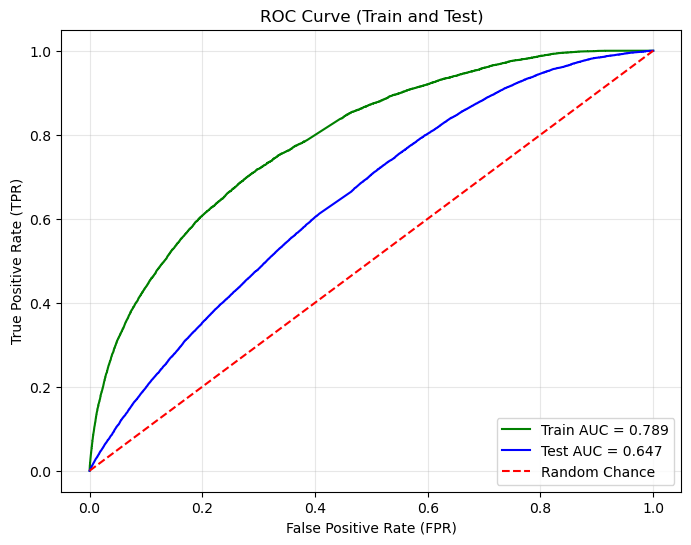

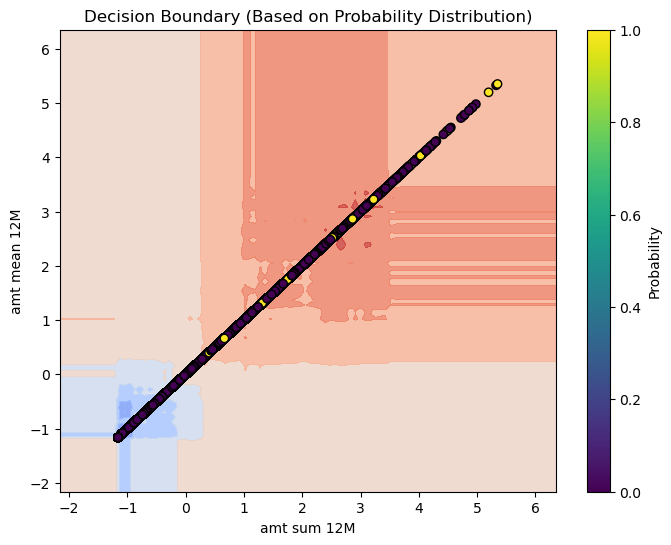

Best Model AUC and Metrics:
Train AUC: 0.789, Test AUC: 0.647
Train Precision: 0.201, Test Precision: 0.142
Train Recall: 0.710, Test Recall: 0.497

Confusion Matrix:


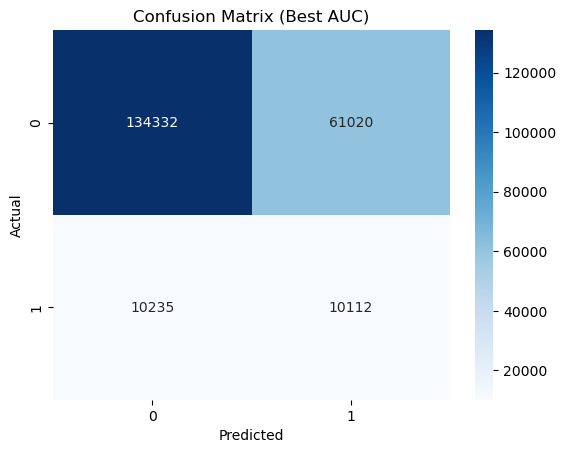


AUC, Precision, and Recall Tuning Results:
min_samples_leaf=1: Train AUC=0.997, Test AUC=0.633, Train Precision=0.949, Test Precision=0.166, Train Recall=0.944, Test Recall=0.019
min_samples_leaf=5: Train AUC=0.989, Test AUC=0.634, Train Precision=0.847, Test Precision=0.193, Train Recall=0.870, Test Recall=0.068
min_samples_leaf=10: Train AUC=0.965, Test AUC=0.639, Train Precision=0.656, Test Precision=0.176, Train Recall=0.813, Test Recall=0.149
min_samples_leaf=25: Train AUC=0.875, Test AUC=0.645, Train Precision=0.310, Test Precision=0.154, Train Recall=0.743, Test Recall=0.357
min_samples_leaf=50: Train AUC=0.789, Test AUC=0.647, Train Precision=0.201, Test Precision=0.142, Train Recall=0.710, Test Recall=0.497
min_samples_leaf=100: Train AUC=0.728, Test AUC=0.647, Train Precision=0.162, Test Precision=0.137, Train Recall=0.694, Test Recall=0.584
min_samples_leaf=200: Train AUC=0.690, Test AUC=0.646, Train Precision=0.144, Test Precision=0.134, Train Recall=0.677, Test Recall=0.6

{'best_model': RandomForestClassifier(class_weight='balanced', min_samples_leaf=50,
                        random_state=1147),
 'best_train_auc': 0.7888849200202591,
 'best_test_auc': 0.6472893448671689,
 'best_train_precision': 0.20113147006670606,
 'best_test_precision': 0.14215824101670135,
 'best_train_recall': 0.7101967799642218,
 'best_test_recall': 0.4969774413918514,
 'feature_importance': amt sum 12M            0.132085
 amt mean 12M           0.120392
 amt max 12M            0.089658
 amt mean 6M            0.088337
 amt max 6M             0.087066
 days since last txn    0.085540
 amt sum 6M             0.072386
 amt mean 3M            0.049859
 amt max 3M             0.047576
 amt sum 3M             0.047117
 txn cnt sum 12M        0.038705
 txn cnt mean 12M       0.035343
 monthly_txn_sum_amt    0.026281
 txn cnt mean 6M        0.013133
 txn cnt max 12M        0.013045
 txn cnt sum 6M         0.011263
 txn cnt max 6M         0.009014
 txn cnt mean 3M        0.006496
 txn 

In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.inspection import DecisionBoundaryDisplay

def random_forest_with_tuning_min_samples_leaf(X_train, Y_train, X_test, Y_test, min_samples_leaf_values):
    results = []
    best_model = None
    best_auc = 0
    
    # Iterate over provided min_samples_leaf values
    for min_samples_leaf in min_samples_leaf_values:
        model = RandomForestClassifier(min_samples_leaf=min_samples_leaf, class_weight="balanced", random_state=1147)
        model.fit(X_train, Y_train)
        
        # Predict probabilities
        train_probs = model.predict_proba(X_train)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]
        
        # Calculate AUC
        train_auc = roc_auc_score(Y_train, train_probs)
        test_auc = roc_auc_score(Y_test, test_probs)
        
        # Calculate Precision and Recall
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        train_precision = precision_score(Y_train, train_pred)
        test_precision = precision_score(Y_test, test_pred)
        
        train_recall = recall_score(Y_train, train_pred)
        test_recall = recall_score(Y_test, test_pred)
        
        # Store results
        results.append({
            'min_samples_leaf': min_samples_leaf,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'train_precision': train_precision,
            'test_precision': test_precision,
            'train_recall': train_recall,
            'test_recall': test_recall,
            'model': model
        })
        
        # Update the best model
        if test_auc > best_auc:
            best_auc = test_auc
            best_model = model
    
    # Extract the best model details
    best_result = max(results, key=lambda x: x['test_auc'])
    best_model = best_result['model']
    best_train_auc = best_result['train_auc']
    best_test_auc = best_result['test_auc']
    best_train_precision = best_result['train_precision']
    best_test_precision = best_result['test_precision']
    best_train_recall = best_result['train_recall']
    best_test_recall = best_result['test_recall']
    
    # Predictions and probabilities
    Y_pred = best_model.predict(X_test)
    best_probs = best_model.predict_proba(X_test)[:, 1]
    
    # Feature Importance
    feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
    feature_importance.sort_values(ascending=False, inplace=True)
    
    # Feature Importance Plot
    plt.figure(figsize=(8, 6))
    feature_importance.plot(kind='bar', color='skyblue')
    plt.title('Feature Importance (Best AUC)')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.show()
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    
    # ROC Curve for Train and Test
    plt.figure(figsize=(8, 6))
    fpr_train, tpr_train, _ = roc_curve(Y_train, best_model.predict_proba(X_train)[:, 1])
    plt.plot(fpr_train, tpr_train, label=f"Train AUC = {best_train_auc:.3f}", color="green")
    fpr_test, tpr_test, _ = roc_curve(Y_test, best_probs)
    plt.plot(fpr_test, tpr_test, label=f"Test AUC = {best_test_auc:.3f}", color="blue")
    plt.plot([0, 1], [0, 1], 'r--', label="Random Chance")
    plt.title("ROC Curve (Train and Test)")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    # Decision Boundary Plot Based on Probability Distribution
    top_features = feature_importance.index[:2]
    if len(top_features) == 2:  # Ensure only 2 features are selected
        X_train_2d = X_train[top_features]
        X_test_2d = X_test[top_features]
        
        # Retrain the best model with top 2 features
        best_model.fit(X_train_2d, Y_train)

        fig, ax = plt.subplots(figsize=(8, 6))
        DecisionBoundaryDisplay.from_estimator(
            best_model,
            X_test_2d,
            response_method="predict_proba",
            ax=ax,
            cmap="coolwarm",
            alpha=0.8,
        )
        plt.scatter(X_test_2d.iloc[:, 0], X_test_2d.iloc[:, 1], c=Y_test, edgecolor="k", cmap="viridis")
        plt.title("Decision Boundary (Based on Probability Distribution)")
        plt.xlabel(top_features[0])
        plt.ylabel(top_features[1])
        plt.colorbar(label="Probability")
        plt.show()
    
    # Display Results
    print("Best Model AUC and Metrics:")
    print(f"Train AUC: {best_train_auc:.3f}, Test AUC: {best_test_auc:.3f}")
    print(f"Train Precision: {best_train_precision:.3f}, Test Precision: {best_test_precision:.3f}")
    print(f"Train Recall: {best_train_recall:.3f}, Test Recall: {best_test_recall:.3f}")
    
    print("\nConfusion Matrix:")
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Best AUC)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("\nAUC, Precision, and Recall Tuning Results:")
    for result in results:
        print(f"min_samples_leaf={result['min_samples_leaf']}: Train AUC={result['train_auc']:.3f}, Test AUC={result['test_auc']:.3f}, "
              f"Train Precision={result['train_precision']:.3f}, Test Precision={result['test_precision']:.3f}, "
              f"Train Recall={result['train_recall']:.3f}, Test Recall={result['test_recall']:.3f}")
    
    return {
        'best_model': best_model,
        'best_train_auc': best_train_auc,
        'best_test_auc': best_test_auc,
        'best_train_precision': best_train_precision,
        'best_test_precision': best_test_precision,
        'best_train_recall': best_train_recall,
        'best_test_recall': best_test_recall,
        'feature_importance': feature_importance,
        'confusion_matrix': conf_matrix
    }

# Example Call
# min_samples_leaf_values = [1, 2, 4, 8, 16]
# results = random_forest_with_tuning_min_samples_leaf(X_train, Y_train, X_test, Y_test, min_samples_leaf_values)

min_samples_leaf_values = [1, 5, 10, 25, 50, 100, 200, 250, 300, 500]
random_forest_with_tuning_min_samples_leaf(X_train_monthly, Y_train_monthly, X_test_monthly, Y_test_monthly, min_samples_leaf_values)


### Random forest annual 

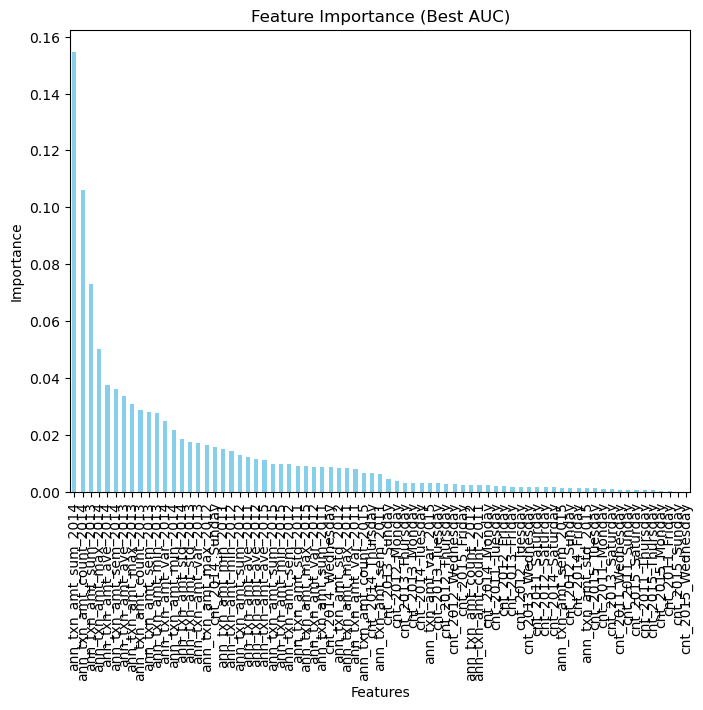

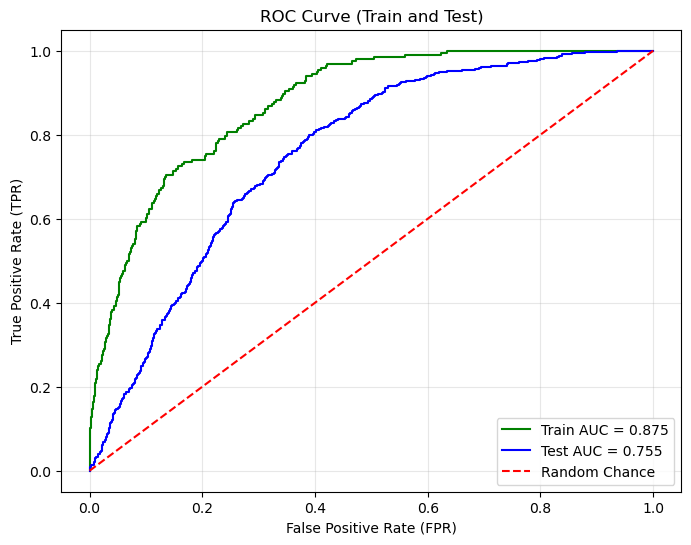

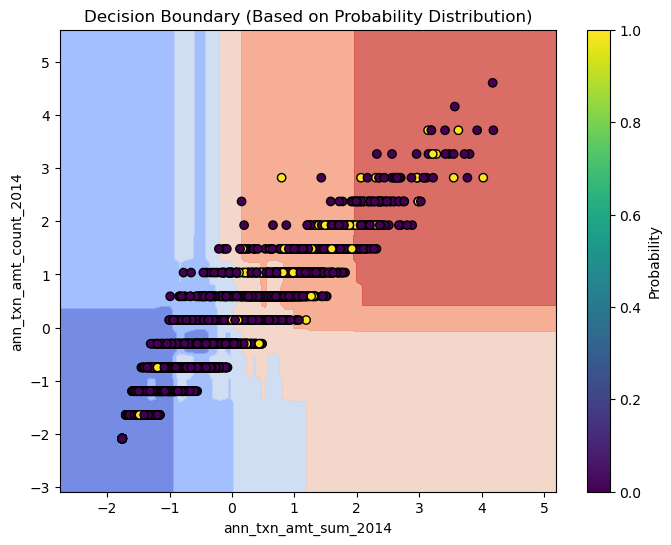

Best Model AUC and Metrics:
Train AUC: 0.875, Test AUC: 0.755
Train Precision: 0.240, Test Precision: 0.209
Train Recall: 0.791, Test Recall: 0.592

Confusion Matrix:


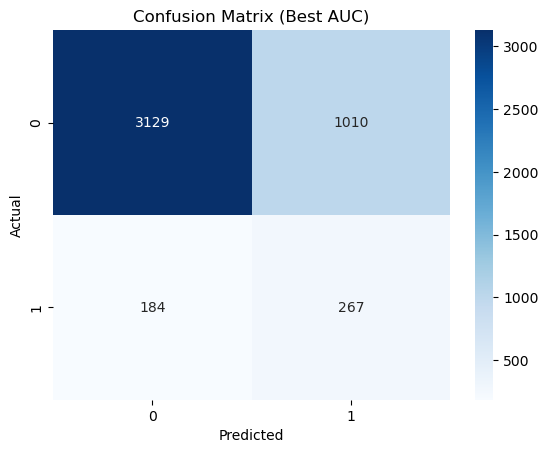


AUC, Precision, and Recall Tuning Results:
min_samples_leaf=1: Train AUC=1.000, Test AUC=0.723, Train Precision=1.000, Test Precision=0.000, Train Recall=1.000, Test Recall=0.000
min_samples_leaf=5: Train AUC=1.000, Test AUC=0.740, Train Precision=0.980, Test Precision=0.226, Train Recall=1.000, Test Recall=0.042
min_samples_leaf=10: Train AUC=0.992, Test AUC=0.751, Train Precision=0.752, Test Precision=0.241, Train Recall=0.913, Test Recall=0.157
min_samples_leaf=25: Train AUC=0.939, Test AUC=0.754, Train Precision=0.371, Test Precision=0.219, Train Recall=0.811, Test Recall=0.424
min_samples_leaf=50: Train AUC=0.875, Test AUC=0.755, Train Precision=0.240, Test Precision=0.209, Train Recall=0.791, Test Recall=0.592
min_samples_leaf=100: Train AUC=0.832, Test AUC=0.755, Train Precision=0.195, Test Precision=0.202, Train Recall=0.776, Test Recall=0.705
min_samples_leaf=200: Train AUC=0.799, Test AUC=0.750, Train Precision=0.178, Test Precision=0.190, Train Recall=0.781, Test Recall=0.7

{'best_model': RandomForestClassifier(class_weight='balanced', min_samples_leaf=50,
                        random_state=1147),
 'best_train_auc': 0.8752699363825607,
 'best_test_auc': 0.7552131072717524,
 'best_train_precision': 0.23956723338485317,
 'best_test_precision': 0.2090837901331245,
 'best_train_recall': 0.7908163265306123,
 'best_test_recall': 0.5920177383592018,
 'feature_importance': ann_txn_amt_sum_2014      0.154680
 ann_txn_amt_count_2014    0.106218
 ann_txn_amt_sum_2013      0.073111
 ann_txn_amt_max_2014      0.050147
 ann_txn_amt_ave_2014      0.037668
                             ...   
 cnt_2015_Thursday         0.000506
 cnt_2015_Monday           0.000296
 cnt_2011_Friday           0.000250
 cnt_2015_Sunday           0.000000
 cnt_2015_Wednesday        0.000000
 Length: 75, dtype: float64,
 'confusion_matrix': array([[3129, 1010],
        [ 184,  267]], dtype=int64)}

In [104]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.inspection import DecisionBoundaryDisplay

def random_forest_with_tuning_min_samples_leaf(X_train, Y_train, X_test, Y_test, min_samples_leaf_values):
    results = []
    best_model = None
    best_auc = 0
    
    # Iterate over provided min_samples_leaf values
    for min_samples_leaf in min_samples_leaf_values:
        model = RandomForestClassifier(min_samples_leaf=min_samples_leaf, class_weight="balanced", random_state=1147)
        model.fit(X_train, Y_train)
        
        # Predict probabilities
        train_probs = model.predict_proba(X_train)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]
        
        # Calculate AUC
        train_auc = roc_auc_score(Y_train, train_probs)
        test_auc = roc_auc_score(Y_test, test_probs)
        
        # Calculate Precision and Recall
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        train_precision = precision_score(Y_train, train_pred)
        test_precision = precision_score(Y_test, test_pred)
        
        train_recall = recall_score(Y_train, train_pred)
        test_recall = recall_score(Y_test, test_pred)
        
        # Store results
        results.append({
            'min_samples_leaf': min_samples_leaf,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'train_precision': train_precision,
            'test_precision': test_precision,
            'train_recall': train_recall,
            'test_recall': test_recall,
            'model': model
        })
        
        # Update the best model
        if test_auc > best_auc:
            best_auc = test_auc
            best_model = model
    
    # Extract the best model details
    best_result = max(results, key=lambda x: x['test_auc'])
    best_model = best_result['model']
    best_train_auc = best_result['train_auc']
    best_test_auc = best_result['test_auc']
    best_train_precision = best_result['train_precision']
    best_test_precision = best_result['test_precision']
    best_train_recall = best_result['train_recall']
    best_test_recall = best_result['test_recall']
    
    # Predictions and probabilities
    Y_pred = best_model.predict(X_test)
    best_probs = best_model.predict_proba(X_test)[:, 1]
    
    # Feature Importance
    feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
    feature_importance.sort_values(ascending=False, inplace=True)
    
    # Feature Importance Plot
    plt.figure(figsize=(8, 6))
    feature_importance.plot(kind='bar', color='skyblue')
    plt.title('Feature Importance (Best AUC)')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.show()
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    
    # ROC Curve for Train and Test
    plt.figure(figsize=(8, 6))
    fpr_train, tpr_train, _ = roc_curve(Y_train, best_model.predict_proba(X_train)[:, 1])
    plt.plot(fpr_train, tpr_train, label=f"Train AUC = {best_train_auc:.3f}", color="green")
    fpr_test, tpr_test, _ = roc_curve(Y_test, best_probs)
    plt.plot(fpr_test, tpr_test, label=f"Test AUC = {best_test_auc:.3f}", color="blue")
    plt.plot([0, 1], [0, 1], 'r--', label="Random Chance")
    plt.title("ROC Curve (Train and Test)")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    # Decision Boundary Plot Based on Probability Distribution
    top_features = feature_importance.index[:2]
    if len(top_features) == 2:  # Ensure only 2 features are selected
        X_train_2d = X_train[top_features]
        X_test_2d = X_test[top_features]
        
        # Retrain the best model with top 2 features
        best_model.fit(X_train_2d, Y_train)

        fig, ax = plt.subplots(figsize=(8, 6))
        DecisionBoundaryDisplay.from_estimator(
            best_model,
            X_test_2d,
            response_method="predict_proba",
            ax=ax,
            cmap="coolwarm",
            alpha=0.8,
        )
        plt.scatter(X_test_2d.iloc[:, 0], X_test_2d.iloc[:, 1], c=Y_test, edgecolor="k", cmap="viridis")
        plt.title("Decision Boundary (Based on Probability Distribution)")
        plt.xlabel(top_features[0])
        plt.ylabel(top_features[1])
        plt.colorbar(label="Probability")
        plt.show()
    
    # Display Results
    print("Best Model AUC and Metrics:")
    print(f"Train AUC: {best_train_auc:.3f}, Test AUC: {best_test_auc:.3f}")
    print(f"Train Precision: {best_train_precision:.3f}, Test Precision: {best_test_precision:.3f}")
    print(f"Train Recall: {best_train_recall:.3f}, Test Recall: {best_test_recall:.3f}")
    
    print("\nConfusion Matrix:")
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Best AUC)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("\nAUC, Precision, and Recall Tuning Results:")
    for result in results:
        print(f"min_samples_leaf={result['min_samples_leaf']}: Train AUC={result['train_auc']:.3f}, Test AUC={result['test_auc']:.3f}, "
              f"Train Precision={result['train_precision']:.3f}, Test Precision={result['test_precision']:.3f}, "
              f"Train Recall={result['train_recall']:.3f}, Test Recall={result['test_recall']:.3f}")
    
    return {
        'best_model': best_model,
        'best_train_auc': best_train_auc,
        'best_test_auc': best_test_auc,
        'best_train_precision': best_train_precision,
        'best_test_precision': best_test_precision,
        'best_train_recall': best_train_recall,
        'best_test_recall': best_test_recall,
        'feature_importance': feature_importance,
        'confusion_matrix': conf_matrix
    }

# Example Call
# min_samples_leaf_values = [1, 2, 4, 8, 16]
# results = random_forest_with_tuning_min_samples_leaf(X_train, Y_train, X_test, Y_test, min_samples_leaf_values)

min_samples_leaf_values = [1, 5, 10, 25, 50, 100, 200, 250, 300, 500]
random_forest_with_tuning_min_samples_leaf(X_train_annual, Y_train_annual, X_test_annual, Y_test_annual, min_samples_leaf_values)


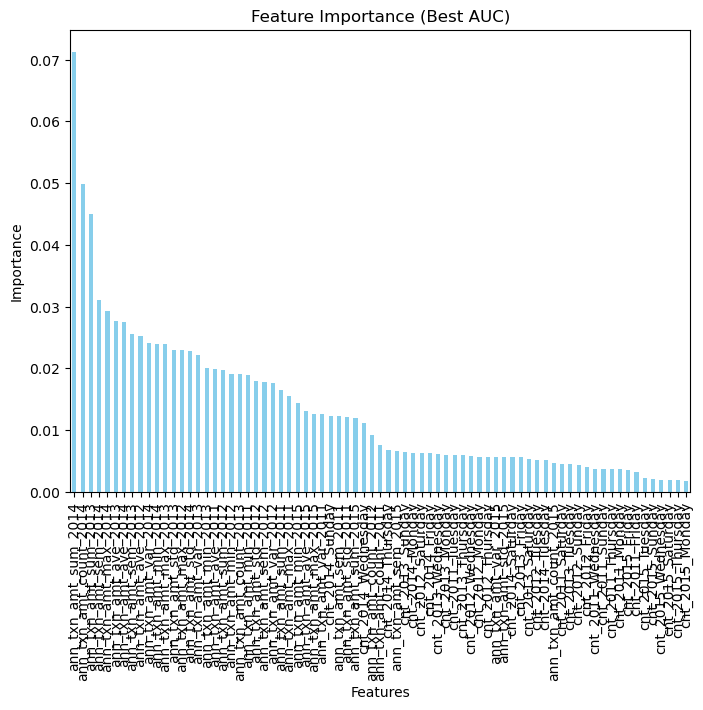

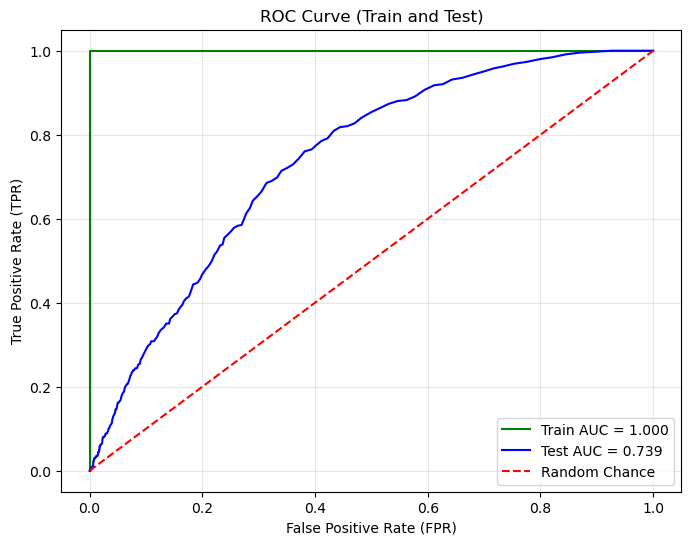

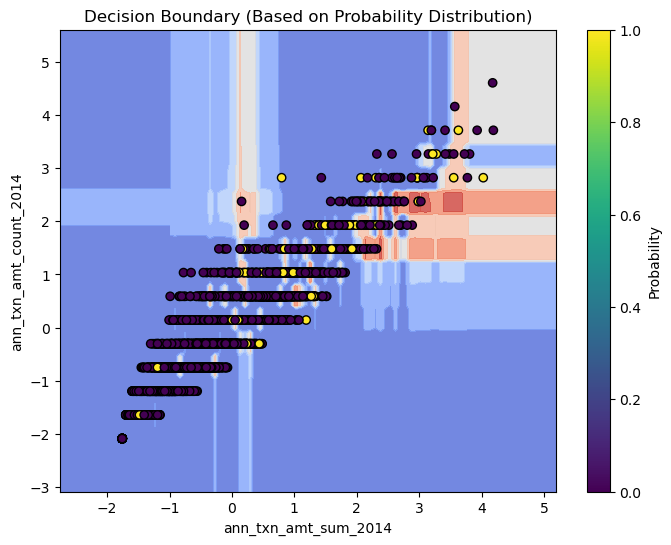

Best Model AUC and Metrics:
Train AUC: 1.000, Test AUC: 0.739
Train Precision: 1.000, Test Precision: 0.000
Train Recall: 1.000, Test Recall: 0.000

Confusion Matrix:


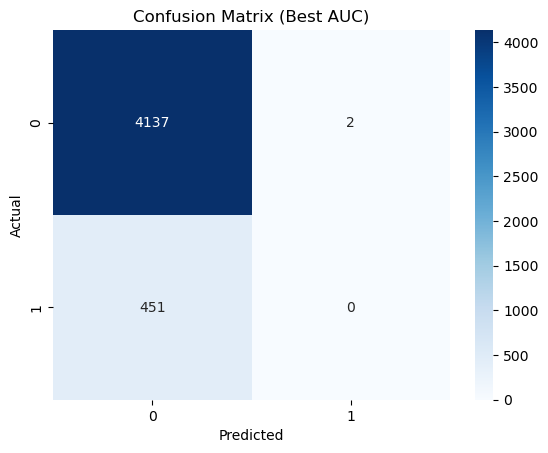


AUC, Precision, and Recall Tuning Results:
n_estimators=5: Train AUC=0.995, Test AUC=0.596, Train Precision=0.981, Test Precision=0.145, Train Recall=0.781, Test Recall=0.022
n_estimators=10: Train AUC=1.000, Test AUC=0.627, Train Precision=1.000, Test Precision=0.077, Train Recall=0.811, Test Recall=0.002
n_estimators=15: Train AUC=1.000, Test AUC=0.657, Train Precision=1.000, Test Precision=0.200, Train Recall=0.923, Test Recall=0.007
n_estimators=20: Train AUC=1.000, Test AUC=0.672, Train Precision=1.000, Test Precision=0.167, Train Recall=0.918, Test Recall=0.002
n_estimators=25: Train AUC=1.000, Test AUC=0.686, Train Precision=1.000, Test Precision=0.000, Train Recall=0.959, Test Recall=0.000
n_estimators=30: Train AUC=1.000, Test AUC=0.695, Train Precision=1.000, Test Precision=0.000, Train Recall=0.949, Test Recall=0.000
n_estimators=35: Train AUC=1.000, Test AUC=0.701, Train Precision=1.000, Test Precision=0.000, Train Recall=0.974, Test Recall=0.000
n_estimators=40: Train AUC

{'best_model': RandomForestClassifier(class_weight='balanced', n_estimators=500,
                        random_state=1147),
 'best_train_auc': 1.0,
 'best_test_auc': 0.7393816002558541,
 'best_train_precision': 1.0,
 'best_test_precision': 0.0,
 'best_train_recall': 1.0,
 'best_test_recall': 0.0,
 'feature_importance': ann_txn_amt_sum_2014      0.071242
 ann_txn_amt_count_2014    0.049779
 ann_txn_amt_sum_2013      0.045031
 ann_txn_amt_sem_2014      0.031028
 ann_txn_amt_max_2014      0.029298
                             ...   
 cnt_2015_Sunday           0.002047
 cnt_2015_Wednesday        0.001915
 cnt_2015_Saturday         0.001889
 cnt_2015_Thursday         0.001874
 cnt_2015_Monday           0.001723
 Length: 75, dtype: float64,
 'confusion_matrix': array([[4137,    2],
        [ 451,    0]], dtype=int64)}

In [105]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.inspection import DecisionBoundaryDisplay

def random_forest_with_tuning_estimators(X_train, Y_train, X_test, Y_test, n_estimators_values):
    results = []
    best_model = None
    best_auc = 0
    
    # Iterate over provided n_estimators values
    for n_estimators in n_estimators_values:
        model = RandomForestClassifier(n_estimators=n_estimators, class_weight="balanced", random_state=1147)
        model.fit(X_train, Y_train)
        
        # Predict probabilities
        train_probs = model.predict_proba(X_train)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]
        
        # Calculate AUC
        train_auc = roc_auc_score(Y_train, train_probs)
        test_auc = roc_auc_score(Y_test, test_probs)
        
        # Calculate Precision and Recall
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        train_precision = precision_score(Y_train, train_pred)
        test_precision = precision_score(Y_test, test_pred)
        
        train_recall = recall_score(Y_train, train_pred)
        test_recall = recall_score(Y_test, test_pred)
        
        # Store results
        results.append({
            'n_estimators': n_estimators,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'train_precision': train_precision,
            'test_precision': test_precision,
            'train_recall': train_recall,
            'test_recall': test_recall,
            'model': model
        })
        
        # Update the best model
        if test_auc > best_auc:
            best_auc = test_auc
            best_model = model
    
    # Extract the best model details
    best_result = max(results, key=lambda x: x['test_auc'])
    best_model = best_result['model']
    best_train_auc = best_result['train_auc']
    best_test_auc = best_result['test_auc']
    best_train_precision = best_result['train_precision']
    best_test_precision = best_result['test_precision']
    best_train_recall = best_result['train_recall']
    best_test_recall = best_result['test_recall']
    
    # Predictions and probabilities
    Y_pred = best_model.predict(X_test)
    best_probs = best_model.predict_proba(X_test)[:, 1]
    
    # Feature Importance
    feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
    feature_importance.sort_values(ascending=False, inplace=True)
    
    # Feature Importance Plot
    plt.figure(figsize=(8, 6))
    feature_importance.plot(kind='bar', color='skyblue')
    plt.title('Feature Importance (Best AUC)')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.show()
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    
    # ROC Curve for Train and Test
    plt.figure(figsize=(8, 6))
    fpr_train, tpr_train, _ = roc_curve(Y_train, best_model.predict_proba(X_train)[:, 1])
    plt.plot(fpr_train, tpr_train, label=f"Train AUC = {best_train_auc:.3f}", color="green")
    fpr_test, tpr_test, _ = roc_curve(Y_test, best_probs)
    plt.plot(fpr_test, tpr_test, label=f"Test AUC = {best_test_auc:.3f}", color="blue")
    plt.plot([0, 1], [0, 1], 'r--', label="Random Chance")
    plt.title("ROC Curve (Train and Test)")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    # Decision Boundary Plot Based on Probability Distribution
    top_features = feature_importance.index[:2]
    if len(top_features) == 2:  # Ensure only 2 features are selected
        X_train_2d = X_train[top_features]
        X_test_2d = X_test[top_features]
        
        # Retrain the best model with top 2 features
        best_model.fit(X_train_2d, Y_train)

        fig, ax = plt.subplots(figsize=(8, 6))
        DecisionBoundaryDisplay.from_estimator(
            best_model,
            X_test_2d,
            response_method="predict_proba",
            ax=ax,
            cmap="coolwarm",
            alpha=0.8,
        )
        plt.scatter(X_test_2d.iloc[:, 0], X_test_2d.iloc[:, 1], c=Y_test, edgecolor="k", cmap="viridis")
        plt.title("Decision Boundary (Based on Probability Distribution)")
        plt.xlabel(top_features[0])
        plt.ylabel(top_features[1])
        plt.colorbar(label="Probability")
        plt.show()
    
    # Display Results
    print("Best Model AUC and Metrics:")
    print(f"Train AUC: {best_train_auc:.3f}, Test AUC: {best_test_auc:.3f}")
    print(f"Train Precision: {best_train_precision:.3f}, Test Precision: {best_test_precision:.3f}")
    print(f"Train Recall: {best_train_recall:.3f}, Test Recall: {best_test_recall:.3f}")
    
    print("\nConfusion Matrix:")
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Best AUC)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("\nAUC, Precision, and Recall Tuning Results:")
    for result in results:
        print(f"n_estimators={result['n_estimators']}: Train AUC={result['train_auc']:.3f}, Test AUC={result['test_auc']:.3f}, "
              f"Train Precision={result['train_precision']:.3f}, Test Precision={result['test_precision']:.3f}, "
              f"Train Recall={result['train_recall']:.3f}, Test Recall={result['test_recall']:.3f}")
    
    return {
        'best_model': best_model,
        'best_train_auc': best_train_auc,
        'best_test_auc': best_test_auc,
        'best_train_precision': best_train_precision,
        'best_test_precision': best_test_precision,
        'best_train_recall': best_train_recall,
        'best_test_recall': best_test_recall,
        'feature_importance': feature_importance,
        'confusion_matrix': conf_matrix
    }

# Example Call
# n_estimators_values = [50, 100, 150, 200, 250]
# results = random_forest_with_tuning_estimators(X_train, Y_train, X_test, Y_test, n_estimators_values)

n_estimators_values = [5,10,15,20,25,30,35,40,45,50,75,100,150,200,250,500]
random_forest_with_tuning_estimators(X_train_annual, Y_train_annual, X_test_annual, Y_test_annual, n_estimators_values)


## extra 

## 1.3 Comparison of methods (10 points)
Compare the two feature engineering (annual and monthly) and the three modeling ap-
proaches (L1 log-reg, tree, forests) in terms of the outcomes of steps 5-8. Which combina-
tion of feature engineering and modeling approach do you select as the best to deploy in a
production environment and why? Tabularize your findings in steps 5-8 to summarize the
results and support your decision (how to organize information with tables in Markdown).
2

## Answer:
The logistic regression model performs better when the data is prepared on an annual basis compared to a monthly basis for classifying customer opinions about "Z." With annual data, the model achieves higher precision (20% vs. 13%) and recall (76% on training, 66% on testing) than with monthly data (54% recall on training, 53% on testing, both with 13% precision). The AUC score, which measures the model's ability to distinguish between classes, is also higher for annual data (0.82 on training, 0.75 on testing) compared to monthly data (0.63 for both training and testing). This indicates that using annual data helps the model perform more reliably and accurately.


The decision tree model shows contrasting performance when trained on monthly versus annual data. For monthly data, the model achieves moderate recall (around 54% for both training and testing) but low precision (around 13%) and a relatively low AUC score (approximately 0.62 for both training and testing). The tree is shallow, with a maximum depth of 3, and is tuned for balanced class weights to handle imbalances.

In contrast, the annual model has a deeper tree (max depth of 20) and achieves better recall for the minority class (32%) but at the cost of very low precision (14%) on the test set. The overall AUC score for testing drops significantly to 0.56, despite the high training AUC of 0.97, indicating potential overfitting. While the annual model performs better in capturing the minority class compared to the monthly model, its generalization ability remains a concern due to the large drop in test performance.


The Random Forest model demonstrates very similar performance when trained on both monthly and annual data. For both approaches, the model achieves a high recall (81%) for the majority class (label 0), but it struggles with the minority class (label 1), with only 33% recall and 16% precision. The overall accuracy is 77%, and the weighted F1-score is 0.80, indicating decent overall performance driven by the dominant class. The AUC scores for training are strong (around 0.91 for both cases), but the test AUC is considerably lower (approximately 0.64), suggesting potential overfitting.

The nearly identical metrics for monthly and annual data imply that the model’s ability to generalize remains consistent regardless of the data preparation frequency. However, the challenges in effectively classifying the minority class persist in both cases.


Recommended Approach for Production
Selected Combination: Annual Data + Logistic Regression

Reason:
This combination provides the best trade-off between recall (0.66), precision (0.20), and AUC (0.75), making it suitable for identifying minority classes more effectively in imbalanced data.
Logistic regression with annual data generalizes better compared to decision trees and random forests, avoiding overfitting while achieving robust test performance.
Simplicity and interpretability of the logistic regression model make it ideal for deployment in a production environment, especially when explaining model decisions is essential.







| Feature Engineering | Model                  | Precision (Test) | Recall (Test) | AUC (Test) | Remarks                                                                 |
|----------------------|-----------------------|------------------|---------------|------------|-------------------------------------------------------------------------|
| **Monthly**          | Logistic Regression   | 0.13             | 0.53          | 0.63       | Poor overall performance with low precision and moderate AUC.          |
|                      | Decision Tree         | 0.14             | 0.54          | 0.62       | Shallow tree shows limited predictive ability and struggles to generalize. |
|                      | Random Forest         | 0.16             | 0.33          | 0.64       | Balanced performance with better recall for the minority class.         |
| **Annual**           | Logistic Regression   | 0.20             | 0.66          | 0.75       | Best recall and AUC among logistic regression models.                   |
|                      | Decision Tree         | 0.14             | 0.32          | 0.56       | Deep tree shows significant overfitting, resulting in poor generalization. |
|                      | Random Forest         | 0.16             | 0.33          | 0.64       | Similar performance to monthly data; consistent generalization issues.  |
